# Hybrid-aggressive chess player - ready play notebook

This notebook defaults to the current best variant, `hybrid_aggressive`, using:

- NN policy/value search
- minimum depth 4 play
- tactical scratch guard
- reply-audit safeguard for missed opponent replies
- no-pawn endgame mating specialist
- full JSONL/PGN diagnostics for later analysis

Run the setup cells from top to bottom, then use the play cells at the bottom.


In [41]:
# Imports and device
from __future__ import annotations

import math
import os
import random
import re
import shutil
import time
from collections import Counter, OrderedDict, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import chess
import chess.engine
import chess.pgn
import chess.polyglot
import chess.svg

from IPython.display import SVG, clear_output, display

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)
print("python-chess:", getattr(chess, "__version__", "unknown"))
print("torch:", torch.__version__)


Using device: cuda
python-chess: 1.10.0
torch: 2.0.1+cu117


In [42]:
# Paths and knobs
HOME = Path.home()
DOWNLOADS = HOME / "Downloads"
OUT_DIR = DOWNLOADS / "chess_play_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Your uploaded checkpoint. Change this if you move it.
WEIGHTS_PATH = Path(r"C:\\Users\\samue\\OneDrive\\Desktop\\projects\\ML\\chess-learn\\n6\\weights\\new_labels2.pth")

# Optional opening DB. Can be .npz with positions, .pgn, .txt/.uci/.san lines, or a polyglot .bin.
# Leave as None to auto-detect Games.npz in the current folder or Downloads.
OPENING_DB_PATH = None
OPENING_DB_MAX_GAMES = 100_000
OPENING_BOOK_PLIES = 12
OPENING_DB_PROGRESS_EVERY = 10_000

# Optional Stockfish binary. Leave as None to try PATH / common local names.
STOCKFISH_PATH = r"C:\Users\samue\OneDrive\Desktop\projects\ML\chess-learn\n1\.ipynb_checkpoints\eval\stockfish\stockfish\stockfish-windows-x86-64-avx2.exe"

# Optional Syzygy tablebases. A 3-5 piece set is realistic on a laptop.
# Example: SYZYGY_PATH = r"D:\syzygy\3-4-5"
SYZYGY_PATH = None
ENABLE_SYZYGY = True
SYZYGY_MAX_PIECES = 5

# Value target in training was sigmoid(cp / 400), so raw model value * 400 ~= centipawns.
VALUE_CP_SCALE = 400.0

# Timed improved-search defaults.
DEFAULT_MODEL_TIME = 2.0
DEFAULT_MODEL_MAX_DEPTH = 8
DEFAULT_MODEL_MIN_DEPTH = 4
DEFAULT_STOCKFISH_DEPTH = 8
MAX_PLIES = 220
RANDOM_SEED = 7

# Search speed/strength knobs.
SEARCH_ROOT_TOP_N = 12
SEARCH_CHILD_TOP_N = 6
SEARCH_QUIESCENCE_DEPTH = 2
SEARCH_EXTENSION_LIMIT = 2
BATCHED_MINIMAX_ENABLED = False
BATCHED_MINIMAX_MAX_DEPTH = 2
BATCHED_EVAL_BATCH_SIZE = 128
BATCHED_FRONTIER_Q_DEPTH = 1
BATCHED_FRONTIER_Q_MAX_MOVES = 10
BATCHED_FRONTIER_MAX_NODES = 60_000
BATCHED_DIRECT_MIN_DEPTH = False
BATCHED_DIRECT_SHALLOW_DEPTHS = 2
STRICT_TIME_LIMIT = False
STRICT_TIME_AFTER_DEPTH = 2
STRICT_TIME_SAFETY_SECONDS = 0.25
SEARCH_GUARDS_USE_REMAINING_TIME = True
# False keeps search fast. Current repetitions and automatic/50-move draws are still handled;
# set True only if you want python-chess's expensive claimable-threefold-by-any-move check at every node.
SEARCH_FULL_CLAIM_DRAW_CHECKS = False
EVAL_CACHE_MAX_ITEMS = 200_000
TT_MAX_ITEMS = 500_000

# "Play to win" knobs.
DRAW_CONTEMPT_CP = 140.0
DRAW_CONTEMPT_TRIGGER_CP = 90.0
CONVERSION_TRIGGER_CP = 180.0
CONVERSION_MARGIN_CP = 90.0

# Hybrid strength layer knobs.
HYBRID_GUARD_ENABLED = True
HYBRID_GUARD_DEPTH = 4
HYBRID_GUARD_SHARP_DEPTH = 5
HYBRID_GUARD_MAX_TIME = 4.0
HYBRID_GUARD_MIN_TIME = 0.75
HYBRID_GUARD_MARGIN_CP = 260.0
HYBRID_GUARD_QUIET_MARGIN_CP = 420.0
HYBRID_GUARD_NN_TOLERANCE_CP = 220.0

ENDGAME_SPECIALIST_ENABLED = True
ENDGAME_SPECIALIST_DEPTH = 10
ENDGAME_SPECIALIST_MAX_TIME = 12.0
ENDGAME_SPECIALIST_MIN_ADV_CP = 450.0

OBVIOUS_MOVE_FASTPATH_ENABLED = True
OBVIOUS_MOVE_SCRATCH_DEPTH = 3
OBVIOUS_MOVE_MARGIN_CP = 750.0

# Re-root suspicious moves as opponent-to-move positions before accepting them.
REPLY_AUDIT_ENABLED = True
REPLY_AUDIT_DEPTH = 3
REPLY_AUDIT_MAX_TIME = 8.0
REPLY_AUDIT_CANDIDATES = 4
REPLY_AUDIT_STATIC_DROP_CP = 140.0
REPLY_AUDIT_SHARP_STATIC_DROP_CP = 80.0
REPLY_AUDIT_OVERRIDE_MARGIN_CP = 120.0

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("Weights:", WEIGHTS_PATH, "exists=", WEIGHTS_PATH.exists())
print("Output folder:", OUT_DIR)
print(f"Default model search: {DEFAULT_MODEL_TIME:.1f}s, max depth {DEFAULT_MODEL_MAX_DEPTH}")


Weights: C:\Users\samue\OneDrive\Desktop\projects\ML\chess-learn\n6\weights\new_labels2.pth exists= True
Output folder: C:\Users\samue\Downloads\chess_play_outputs
Default model search: 2.0s, max depth 8


In [43]:
# Model definition exactly matching the training notebook
class ResBlock(nn.Module):
    def __init__(self, channels: int = 128):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x, inplace=True)
        x = self.conv2(x)
        x = self.bn2(x)
        x = x + residual
        x = F.relu(x, inplace=True)
        return x


class ChessNet(nn.Module):
    def __init__(self, in_ch: int = 19, filters: int = 128, num_blocks: int = 10, policy_dim: int = 4672):
        super().__init__()
        self.input_conv = nn.Conv2d(in_ch, filters, kernel_size=3, padding=1, bias=False)
        self.input_bn = nn.BatchNorm2d(filters)
        self.res_blocks = nn.Sequential(*[ResBlock(filters) for _ in range(num_blocks)])

        self.value_conv = nn.Conv2d(filters, 1, kernel_size=1, bias=False)
        self.value_bn = nn.BatchNorm2d(1)
        self.value_fc1 = nn.Linear(64, 64)
        self.value_fc2 = nn.Linear(64, 1)

        self.policy_conv = nn.Conv2d(filters, 2, kernel_size=1, bias=False)
        self.policy_bn = nn.BatchNorm2d(2)
        self.policy_fc = nn.Linear(2 * 8 * 8, policy_dim)

    def forward_features(self, x):
        x = self.input_conv(x)
        x = self.input_bn(x)
        x = F.relu(x, inplace=True)
        x = self.res_blocks(x)
        return x

    def forward_raw(self, x, legal_mask=None):
        x = self.forward_features(x)

        v = self.value_conv(x)
        v = self.value_bn(v)
        v = F.relu(v, inplace=True)
        v = v.view(v.size(0), -1)
        v = F.relu(self.value_fc1(v), inplace=True)
        v = self.value_fc2(v)

        p = self.policy_conv(x)
        p = self.policy_bn(p)
        p = F.relu(p, inplace=True)
        p = p.view(p.size(0), -1)
        p = self.policy_fc(p)

        if legal_mask is not None:
            p = p.masked_fill(~legal_mask, float("-inf"))
        return v, p

    def forward(self, x, legal_mask=None):
        v, p = self.forward_raw(x, legal_mask)
        return torch.sigmoid(v), F.softmax(p, dim=-1)


def load_dual_model(ckpt_path: str | Path, device: torch.device):
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")

    ckpt = torch.load(ckpt_path, map_location="cpu")
    if isinstance(ckpt, dict):
        state = ckpt.get("model_state") or ckpt.get("model_state_dict") or ckpt.get("state_dict")
        in_ch = int(ckpt.get("input_channels", ckpt.get("in_ch", 19)))
        filters = int(ckpt.get("filters", 128))
        num_blocks = int(ckpt.get("num_blocks", 10))
        policy_dim = int(ckpt.get("policy_dim", 4672))
        meta = dict(ckpt)
    else:
        state = ckpt
        in_ch, filters, num_blocks, policy_dim = 19, 128, 10, 4672
        meta = {}

    if state is None:
        raise KeyError("Could not find model weights in checkpoint. Expected model_state/model_state_dict/state_dict.")

    model = ChessNet(in_ch=in_ch, filters=filters, num_blocks=num_blocks, policy_dim=policy_dim).to(device)
    model.load_state_dict(state, strict=True)
    model.eval()

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Loaded {ckpt_path}")
    print(f"Architecture: in_ch={in_ch}, filters={filters}, blocks={num_blocks}, policy_dim={policy_dim}")
    print(f"Params: {trainable / 1e6:.3f}M")
    if "epoch" in meta or "best_val_loss" in meta:
        print("Checkpoint meta:", {k: meta.get(k) for k in ["epoch", "best_val_loss"] if k in meta})
    return model, meta


In [44]:
# Board encoding and policy indexing
PIECE_ORDER = [chess.PAWN, chess.KNIGHT, chess.BISHOP, chess.ROOK, chess.QUEEN, chess.KING]
POLICY_DIM = 4672


def board_to_icpram_bitmap_plus(board: chess.Board, channels_first: bool = True) -> np.ndarray:
    planes: list[np.ndarray] = []

    # 12 piece planes, matching the play/training convention you used before.
    for color, sign in ((chess.WHITE, +1.0), (chess.BLACK, -1.0)):
        for piece_type in PIECE_ORDER:
            plane = np.zeros((8, 8), dtype=np.float32)
            for sq in board.pieces(piece_type, color):
                row = 7 - chess.square_rank(sq)
                col = chess.square_file(sq)
                plane[row, col] = sign
            planes.append(plane)

    planes.append(np.full((8, 8), 1.0 if board.has_kingside_castling_rights(chess.WHITE) else 0.0, dtype=np.float32))
    planes.append(np.full((8, 8), 1.0 if board.has_queenside_castling_rights(chess.WHITE) else 0.0, dtype=np.float32))
    planes.append(np.full((8, 8), 1.0 if board.has_kingside_castling_rights(chess.BLACK) else 0.0, dtype=np.float32))
    planes.append(np.full((8, 8), 1.0 if board.has_queenside_castling_rights(chess.BLACK) else 0.0, dtype=np.float32))
    planes.append(np.full((8, 8), 1.0 if board.turn == chess.WHITE else -1.0, dtype=np.float32))

    ep = np.zeros((8, 8), dtype=np.float32)
    if board.ep_square is not None:
        row = 7 - chess.square_rank(board.ep_square)
        col = chess.square_file(board.ep_square)
        ep[row, col] = 1.0
    planes.append(ep)

    planes.append(np.full((8, 8), min(board.halfmove_clock, 100) / 100.0, dtype=np.float32))

    x = np.stack(planes, axis=0)
    if x.shape != (19, 8, 8):
        raise ValueError(f"Expected (19, 8, 8), got {x.shape}")
    if not channels_first:
        x = np.transpose(x, (1, 2, 0))
    return x


def move_to_index(move: chess.Move) -> int:
    # This intentionally preserves the mapping used in the training notebook.
    if move.promotion and move.promotion != chess.QUEEN:
        promo_offset = {chess.KNIGHT: 0, chess.BISHOP: 1, chess.ROOK: 2}
        return 4096 + move.from_square * 3 + promo_offset[move.promotion]
    return move.from_square * 64 + move.to_square


def get_legal_mask(board: chess.Board) -> np.ndarray:
    mask = np.zeros(POLICY_DIM, dtype=np.bool_)
    for move in board.legal_moves:
        idx = move_to_index(move)
        if 0 <= idx < POLICY_DIM:
            mask[idx] = True
    return mask


_start = chess.Board()
_x = board_to_icpram_bitmap_plus(_start)
_m = get_legal_mask(_start)
print("encoder:", _x.shape, _x.dtype, "legal moves:", int(_m.sum()))


encoder: (19, 8, 8) float32 legal moves: 20


In [45]:
# Opening DB support: Games.npz, PGN, TXT/SAN/UCI lines, or polyglot .bin
RESULT_TOKENS = {"1-0", "0-1", "1/2-1/2", "*"}


def strip_pgn_token(token: str) -> str:
    token = token.strip()
    token = re.sub(r"^\d+\.(\.\.)?", "", token)
    token = token.strip()
    if not token or token in RESULT_TOKENS:
        return ""
    if token.startswith("{") or token.startswith("["):
        return ""
    return token


def token_to_legal_move(board: chess.Board, token: str) -> Optional[chess.Move]:
    token = strip_pgn_token(str(token))
    if not token:
        return None
    try:
        return board.parse_san(token)
    except Exception:
        pass
    try:
        mv = chess.Move.from_uci(token.lower())
        if mv in board.legal_moves:
            return mv
    except Exception:
        pass
    return None


class OpeningBook:
    def __init__(
        self,
        path: str | Path | None = None,
        max_games: int | None = None,
        max_plies: int = OPENING_BOOK_PLIES,
        progress_every: int = OPENING_DB_PROGRESS_EVERY,
    ):
        self.path = Path(path) if path else None
        self.max_plies = int(max_plies)
        self.progress_every = int(progress_every) if progress_every else 0
        self.next_by_prefix: dict[tuple[str, ...], Counter[str]] = defaultdict(Counter)
        self.games_loaded = 0
        self.moves_indexed = 0
        self.polyglot_path: Optional[Path] = None
        if self.path:
            self.load(self.path, max_games=max_games)

    def __len__(self):
        return len(self.next_by_prefix)

    @property
    def enabled(self) -> bool:
        return bool(self.next_by_prefix) or self.polyglot_path is not None

    def _progress(self):
        if self.progress_every and self.games_loaded and self.games_loaded % self.progress_every == 0:
            print(
                f"  indexed {self.games_loaded:,} games, "
                f"{len(self):,} prefixes, {self.moves_indexed:,} moves..."
            )

    def load(self, path: str | Path, max_games: int | None = None):
        path = Path(path)
        if not path.exists():
            raise FileNotFoundError(path)
        self.path = path
        suffix = path.suffix.lower()
        if suffix == ".bin":
            self.polyglot_path = path
            print("Using polyglot book:", path)
            return self

        limit_text = f"first {max_games:,} games" if max_games is not None else "all games"
        print(f"Indexing opening DB ({limit_text}, first {self.max_plies} plies only)...")
        t0 = time.time()
        if suffix == ".npz":
            self._load_npz(path, max_games=max_games)
        elif suffix == ".pgn":
            self._load_pgn(path, max_games=max_games)
        else:
            self._load_text(path, max_games=max_games)
        dt = time.time() - t0
        print(
            f"Loaded opening DB in {dt:.1f}s: games={self.games_loaded:,}, "
            f"prefixes={len(self):,}, indexed_moves={self.moves_indexed:,}"
        )
        return self

    def add_game_tokens(self, tokens: Iterable[str]):
        board = chess.Board()
        prefix: list[str] = []
        added = 0
        for token in tokens:
            if added >= self.max_plies:
                break
            mv = token_to_legal_move(board, token)
            if mv is None:
                continue
            san = board.san(mv)
            self.next_by_prefix[tuple(prefix)][san] += 1
            board.push(mv)
            prefix.append(san)
            added += 1
            if board.is_game_over(claim_draw=True):
                break
        if added:
            self.games_loaded += 1
            self.moves_indexed += added
            self._progress()

    def _load_npz(self, path: Path, max_games: int | None = None):
        with np.load(path, allow_pickle=True) as data:
            if "positions" not in data:
                raise KeyError(f"{path} does not contain a 'positions' array")
            positions = data["positions"]
            n = len(positions) if max_games is None else min(len(positions), int(max_games))
            print(f"  npz games available: {len(positions):,}; indexing: {n:,}")
            for i in range(n):
                self.add_game_tokens(list(positions[i]))

    def _load_pgn(self, path: Path, max_games: int | None = None):
        with path.open("r", encoding="utf-8", errors="replace") as f:
            while max_games is None or self.games_loaded < max_games:
                game = chess.pgn.read_game(f)
                if game is None:
                    break
                board = game.board()
                tokens = []
                for ply, mv in enumerate(game.mainline_moves()):
                    if ply >= self.max_plies:
                        break
                    tokens.append(board.san(mv))
                    board.push(mv)
                self.add_game_tokens(tokens)

    def _load_text(self, path: Path, max_games: int | None = None):
        with path.open("r", encoding="utf-8", errors="replace") as f:
            for i, line in enumerate(f):
                if max_games is not None and i >= max_games:
                    break
                tokens = [tok for tok in re.split(r"\s+", line.strip()) if tok]
                self.add_game_tokens(tokens[: self.max_plies])

    def choose(self, board: chess.Board, san_history: list[str], temperature: float = 0.0) -> Optional[chess.Move]:
        if self.polyglot_path is not None:
            try:
                with chess.polyglot.open_reader(str(self.polyglot_path)) as reader:
                    entries = list(reader.find_all(board))
                if not entries:
                    return None
                if temperature and temperature > 0:
                    weights = [max(1, e.weight) ** (1.0 / temperature) for e in entries]
                    entry = random.choices(entries, weights=weights, k=1)[0]
                else:
                    entry = max(entries, key=lambda e: e.weight)
                if entry.move in board.legal_moves:
                    return entry.move
            except Exception as exc:
                print("Polyglot book error:", exc)
                return None

        counter = self.next_by_prefix.get(tuple(san_history))
        if not counter:
            return None

        legal: list[tuple[str, int, chess.Move]] = []
        for san, count in counter.items():
            mv = token_to_legal_move(board, san)
            if mv is not None and mv in board.legal_moves:
                legal.append((san, count, mv))
        if not legal:
            return None

        legal.sort(key=lambda item: item[1], reverse=True)
        if temperature and temperature > 0:
            weights = [count ** (1.0 / temperature) for _, count, _ in legal]
            return random.choices([mv for _, _, mv in legal], weights=weights, k=1)[0]
        return legal[0][2]


def auto_find_opening_db() -> Optional[Path]:
    candidates = []
    if OPENING_DB_PATH:
        candidates.append(Path(OPENING_DB_PATH))
    candidates.extend([
        Path.cwd() / "Games.npz",
        DOWNLOADS / "Games.npz",
        Path.cwd() / "book.bin",
        DOWNLOADS / "book.bin",
        Path.cwd() / "openings.pgn",
        DOWNLOADS / "openings.pgn",
    ])
    for path in candidates:
        if path and path.exists():
            return path
    return None


def build_opening_npz(source_path: str | Path, output_path: str | Path | None = None, max_games: int | None = None) -> Path:
    source_path = Path(source_path)
    if output_path is None:
        output_path = source_path.with_suffix(".npz")
    output_path = Path(output_path)

    games: list[list[str]] = []
    suffix = source_path.suffix.lower()
    if suffix == ".pgn":
        with source_path.open("r", encoding="utf-8", errors="replace") as f:
            while max_games is None or len(games) < max_games:
                game = chess.pgn.read_game(f)
                if game is None:
                    break
                board = game.board()
                sans = []
                for mv in game.mainline_moves():
                    sans.append(board.san(mv))
                    board.push(mv)
                if sans:
                    games.append(sans)
    else:
        with source_path.open("r", encoding="utf-8", errors="replace") as f:
            for line in f:
                if max_games is not None and len(games) >= max_games:
                    break
                tokens = [strip_pgn_token(tok) for tok in re.split(r"\s+", line.strip())]
                tokens = [tok for tok in tokens if tok]
                if tokens:
                    games.append(tokens)

    arr = np.array(games, dtype=object)
    np.savez_compressed(output_path, positions=arr)
    print(f"Saved {len(games)} games to {output_path}")
    return output_path

In [46]:
# Improved neural player:
# - timed iterative deepening
# - eval and move-order caches
# - policy-pruned alpha-beta
# - quiescence and tactical/passed-pawn extensions
# - draw contempt and root conversion bias
# - optional Syzygy probing
@dataclass
class SearchResult:
    move: chess.Move
    score_cp: float
    source: str = "nn"
    depth: int = 0
    nodes: int = 0
    elapsed: float = 0.0
    candidates: list[tuple[float, chess.Move]] | None = None


class SearchTimeout(Exception):
    pass


class BatchedSearchTooLarge(Exception):
    pass


PIECE_VALUE_CP = {
    chess.PAWN: 100,
    chess.KNIGHT: 320,
    chess.BISHOP: 330,
    chess.ROOK: 500,
    chess.QUEEN: 900,
}


def material_cp_white(board: chess.Board) -> int:
    total = 0
    for piece in board.piece_map().values():
        value = PIECE_VALUE_CP.get(piece.piece_type, 0)
        total += value if piece.color == chess.WHITE else -value
    return total


def nonking_piece_count(board: chess.Board) -> int:
    return sum(1 for piece in board.piece_map().values() if piece.piece_type != chess.KING)


def is_passed_pawn(board: chess.Board, square: chess.Square, color: chess.Color) -> bool:
    piece = board.piece_at(square)
    if piece is None or piece.piece_type != chess.PAWN or piece.color != color:
        return False
    file_idx = chess.square_file(square)
    rank_idx = chess.square_rank(square)
    enemy = not color
    files = [f for f in (file_idx - 1, file_idx, file_idx + 1) if 0 <= f <= 7]
    ranks = range(rank_idx + 1, 8) if color == chess.WHITE else range(rank_idx - 1, -1, -1)
    for f in files:
        for r in ranks:
            p = board.piece_at(chess.square(f, r))
            if p is not None and p.color == enemy and p.piece_type == chess.PAWN:
                return False
    return True


def passed_pawn_danger(board: chess.Board, color: chess.Color) -> float:
    danger = 0.0
    for sq in board.pieces(chess.PAWN, color):
        if not is_passed_pawn(board, sq, color):
            continue
        rank = chess.square_rank(sq)
        progress = rank if color == chess.WHITE else 7 - rank
        if progress >= 4:
            danger += (progress - 3) ** 2
            file_idx = chess.square_file(sq)
            if file_idx in (3, 4):
                danger += 0.75
    return danger


def move_is_dangerous_passer_push(board: chess.Board, move: chess.Move) -> bool:
    piece = board.piece_at(move.from_square)
    if piece is None or piece.piece_type != chess.PAWN:
        return False
    to_rank = chess.square_rank(move.to_square)
    if piece.color == chess.WHITE and to_rank >= 5:
        return True
    if piece.color == chess.BLACK and to_rank <= 2:
        return True
    return False


def piece_trade_class(piece_type: int) -> str | None:
    if piece_type == chess.QUEEN:
        return "queen"
    if piece_type == chess.ROOK:
        return "rook"
    if piece_type in (chess.BISHOP, chess.KNIGHT):
        return "minor"
    return None


def side_material_cp(board: chess.Board, side: chess.Color) -> int:
    material = material_cp_white(board)
    return material if side == chess.WHITE else -material


def nonpawn_trade_bonus(board: chess.Board, move: chess.Move, root_turn: chess.Color, side_score: float) -> float:
    """Prefer real simplification only when already safely better.

    Real simplification means queen-for-queen, rook-for-rook, or
    bishop/knight-for-bishop/knight. Pawn swaps deliberately get no bonus.
    The bonus is conservative for small edges and larger for clearly won games.
    """
    mover = board.piece_at(move.from_square)
    captured = board.piece_at(move.to_square)
    if mover is None or captured is None:
        return 0.0
    if mover.piece_type == chess.PAWN or captured.piece_type == chess.PAWN:
        return 0.0

    mover_class = piece_trade_class(mover.piece_type)
    captured_class = piece_trade_class(captured.piece_type)
    if mover_class is None or captured_class is None:
        return 0.0

    mover_value = PIECE_VALUE_CP.get(mover.piece_type, 0)
    captured_value = PIECE_VALUE_CP.get(captured.piece_type, 0)
    material_before = side_material_cp(board, root_turn)
    material_after = material_before + captured_value

    # Avoid queen-trade "conversion" when the edge is mostly attacking rather
    # than material. If we are not materially ahead, do not bonus queen trades.
    if captured_class == "queen" and material_before < 250:
        return 0.0

    same_trade = mover_class == captured_class
    wins_material = captured_value > mover_value
    equal_or_better_trade = same_trade or captured_value >= mover_value

    if equal_or_better_trade:
        if side_score < 300:
            return 0.0
        if material_before < 100 and side_score < 700:
            return 0.0

        base = {"queen": 150.0, "rook": 85.0, "minor": 50.0}.get(captured_class, 0.0)
        if side_score < 500:
            scale = 0.30
        elif side_score < 900:
            scale = 0.65
        else:
            scale = 1.00
        if wins_material:
            scale += 0.25
        return base * scale

    # Deliberately losing material to simplify: only when the game is already
    # overwhelmingly won, e.g. two rooks vs a knight type liquidation.
    material_loss = mover_value - captured_value
    if captured_class == "minor" and mover_class == "rook":
        if side_score >= 1000 and material_before >= 800 and material_after >= 500:
            return 35.0
        if side_score >= 1500 and material_before >= 1200 and material_after >= 800:
            return 70.0

    return -40.0 if material_loss > 0 else 0.0


class ClassicalTimeout(Exception):
    pass


CLASSICAL_MATE_SCORE = 100_000.0
CLASSICAL_INF = 1_000_000.0


CLASSICAL_PIECE_VALUE_CP = {
    chess.PAWN: 100,
    chess.KNIGHT: 320,
    chess.BISHOP: 330,
    chess.ROOK: 500,
    chess.QUEEN: 900,
    chess.KING: 0,
}


def cp_for_color(color: chess.Color, cp_white: float) -> float:
    return float(cp_white) if color == chess.WHITE else -float(cp_white)


def cp_from_color(color: chess.Color, cp_for_side: float) -> float:
    return float(cp_for_side) if color == chess.WHITE else -float(cp_for_side)


def square_chebyshev(a: chess.Square, b: chess.Square) -> int:
    return max(abs(chess.square_file(a) - chess.square_file(b)), abs(chess.square_rank(a) - chess.square_rank(b)))


def square_manhattan(a: chess.Square, b: chess.Square) -> int:
    return abs(chess.square_file(a) - chess.square_file(b)) + abs(chess.square_rank(a) - chess.square_rank(b))


def edge_pressure(square: chess.Square) -> float:
    f = chess.square_file(square)
    r = chess.square_rank(square)
    return max(abs(f - 3.5), abs(r - 3.5)) / 3.5


def center_pressure(square: chess.Square) -> float:
    f = chess.square_file(square)
    r = chess.square_rank(square)
    return 1.0 - (abs(f - 3.5) + abs(r - 3.5)) / 7.0


def square_color(square: chess.Square) -> int:
    return (chess.square_file(square) + chess.square_rank(square)) & 1


def pieces_without_kings(board: chess.Board) -> list[chess.Piece]:
    return [p for p in board.piece_map().values() if p.piece_type != chess.KING]


def has_any_pawns(board: chess.Board) -> bool:
    return bool(board.pieces(chess.PAWN, chess.WHITE) or board.pieces(chess.PAWN, chess.BLACK))


def material_cp_for_color(board: chess.Board, color: chess.Color) -> int:
    return side_material_cp(board, color)


def side_piece_counts(board: chess.Board, color: chess.Color) -> Counter:
    counts = Counter()
    for piece in board.piece_map().values():
        if piece.color == color and piece.piece_type != chess.KING:
            counts[piece.piece_type] += 1
    return counts


def nonking_material_for_color(board: chess.Board, color: chess.Color) -> int:
    total = 0
    for piece in board.piece_map().values():
        if piece.color == color and piece.piece_type != chess.KING:
            total += CLASSICAL_PIECE_VALUE_CP.get(piece.piece_type, 0)
    return total


def mating_material_kind(board: chess.Board, color: chess.Color, min_adv_cp: float | None = None) -> str | None:
    if has_any_pawns(board):
        return None
    if min_adv_cp is None:
        min_adv_cp = globals().get("ENDGAME_SPECIALIST_MIN_ADV_CP", 450.0)
    counts = side_piece_counts(board, color)
    enemy_counts = side_piece_counts(board, not color)
    own_mat = nonking_material_for_color(board, color)
    enemy_mat = nonking_material_for_color(board, not color)
    adv = own_mat - enemy_mat

    if enemy_mat == 0:
        if counts[chess.QUEEN] >= 1:
            return "queen"
        if counts[chess.ROOK] >= 1:
            return "rook"
        if counts[chess.BISHOP] >= 1 and counts[chess.KNIGHT] >= 1:
            return "bishop-knight"
        if counts[chess.BISHOP] >= 2:
            return "two-bishops"
        if counts[chess.QUEEN] + counts[chess.ROOK] >= 2:
            return "major"

    # Converted no-pawn positions where the stronger side still has to win/mate.
    if adv >= float(min_adv_cp) and sum(counts.values()) + sum(enemy_counts.values()) <= 6:
        if counts[chess.QUEEN] or counts[chess.ROOK] or (counts[chess.BISHOP] and counts[chess.KNIGHT]) or counts[chess.BISHOP] >= 2:
            return "converted"
    return None


def classical_terminal_value_white(board: chess.Board) -> float | None:
    outcome = board.outcome(claim_draw=True)
    if outcome is None:
        return None
    if outcome.winner is None:
        return 0.0
    score = CLASSICAL_MATE_SCORE - min(board.ply(), 10_000)
    return score if outcome.winner == chess.WHITE else -score


def legal_count_for_turn(board: chess.Board, turn: chess.Color) -> int:
    b = board.copy(stack=False)
    b.turn = turn
    try:
        return b.legal_moves.count()
    except Exception:
        return len(list(b.legal_moves))


def classical_static_eval_white(board: chess.Board) -> float:
    terminal = classical_terminal_value_white(board)
    if terminal is not None:
        return terminal

    score = 0.0
    piece_map = board.piece_map()
    endgameish = len(piece_map) <= 12 or not (
        board.pieces(chess.QUEEN, chess.WHITE) or board.pieces(chess.QUEEN, chess.BLACK)
    )

    for sq, piece in piece_map.items():
        if piece.piece_type == chess.KING:
            continue
        sign = 1.0 if piece.color == chess.WHITE else -1.0
        value = CLASSICAL_PIECE_VALUE_CP.get(piece.piece_type, 0)
        score += sign * value

        center = center_pressure(sq)
        if piece.piece_type == chess.KNIGHT:
            score += sign * (28.0 * center)
        elif piece.piece_type == chess.BISHOP:
            score += sign * (18.0 * center)
        elif piece.piece_type == chess.ROOK:
            file_idx = chess.square_file(sq)
            same_file_pawns = len(board.pieces(chess.PAWN, chess.WHITE) & chess.BB_FILES[file_idx]) + len(board.pieces(chess.PAWN, chess.BLACK) & chess.BB_FILES[file_idx])
            if same_file_pawns == 0:
                score += sign * 18.0
        elif piece.piece_type == chess.PAWN:
            rank = chess.square_rank(sq) if piece.color == chess.WHITE else 7 - chess.square_rank(sq)
            score += sign * (rank * 7.0)
            if is_passed_pawn(board, sq, piece.color):
                score += sign * (25.0 + rank * rank * 5.0)

        enemy = not piece.color
        attackers = len(board.attackers(enemy, sq))
        defenders = len(board.attackers(piece.color, sq))
        if attackers and piece.piece_type != chess.PAWN:
            if defenders == 0:
                score -= sign * min(260.0, 0.38 * value)
            elif attackers > defenders:
                score -= sign * min(180.0, 0.22 * value)

    for color in (chess.WHITE, chess.BLACK):
        sign = 1.0 if color == chess.WHITE else -1.0
        counts = side_piece_counts(board, color)
        if counts[chess.BISHOP] >= 2:
            score += sign * 35.0
        king_sq = board.king(color)
        if king_sq is not None and endgameish:
            enemy_king = board.king(not color)
            if enemy_king is not None:
                score += sign * (7 - square_chebyshev(king_sq, enemy_king)) * 7.0
        elif king_sq is not None:
            score -= sign * edge_pressure(king_sq) * 18.0

    try:
        white_mob = legal_count_for_turn(board, chess.WHITE)
        black_mob = legal_count_for_turn(board, chess.BLACK)
        score += 1.5 * (white_mob - black_mob)
    except Exception:
        pass

    if board.is_check():
        score += -45.0 if board.turn == chess.WHITE else 45.0

    return float(score)


def classical_move_order_score(board: chess.Board, move: chess.Move) -> float:
    score = 0.0
    mover = board.piece_at(move.from_square)
    victim = None
    if board.is_en_passant(move):
        victim = chess.Piece(chess.PAWN, not board.turn)
    elif board.is_capture(move):
        victim = board.piece_at(move.to_square)
    if victim is not None:
        victim_value = CLASSICAL_PIECE_VALUE_CP.get(victim.piece_type, 0)
        mover_value = CLASSICAL_PIECE_VALUE_CP.get(mover.piece_type, 0) if mover else 0
        score += 10_000.0 + 10.0 * victim_value - mover_value
    if move.promotion:
        score += 8_000.0 + CLASSICAL_PIECE_VALUE_CP.get(move.promotion, 0)
    if board.gives_check(move):
        score += 2_000.0
    if mover is not None and mover.piece_type == chess.KING:
        score -= 20.0
    return score


def classical_ordered_moves(board: chess.Board, moves: Iterable[chess.Move] | None = None) -> list[chess.Move]:
    ordered = list(board.legal_moves if moves is None else moves)
    ordered.sort(key=lambda mv: classical_move_order_score(board, mv), reverse=True)
    return ordered


def classical_forcing_moves(board: chess.Board) -> list[chess.Move]:
    moves = []
    for mv in board.legal_moves:
        if board.is_capture(mv) or board.gives_check(mv) or mv.promotion:
            moves.append(mv)
    return classical_ordered_moves(board, moves)


def classical_check_deadline(deadline: float | None):
    if deadline is not None and time.perf_counter() >= deadline:
        raise ClassicalTimeout()


def classical_quiescence(board: chess.Board, alpha: float, beta: float, q_depth: int, deadline: float | None) -> float:
    classical_check_deadline(deadline)
    terminal = classical_terminal_value_white(board)
    if terminal is not None:
        return terminal

    stand_pat = classical_static_eval_white(board)
    if q_depth <= 0:
        return stand_pat

    if board.turn == chess.WHITE:
        if stand_pat >= beta:
            return stand_pat
        alpha = max(alpha, stand_pat)
        best = stand_pat
        for mv in classical_forcing_moves(board):
            board.push(mv)
            try:
                score = classical_quiescence(board, alpha, beta, q_depth - 1, deadline)
            finally:
                board.pop()
            best = max(best, score)
            alpha = max(alpha, best)
            if beta <= alpha:
                break
        return float(best)

    if stand_pat <= alpha:
        return stand_pat
    beta = min(beta, stand_pat)
    best = stand_pat
    for mv in classical_forcing_moves(board):
        board.push(mv)
        try:
            score = classical_quiescence(board, alpha, beta, q_depth - 1, deadline)
        finally:
            board.pop()
        best = min(best, score)
        beta = min(beta, best)
        if beta <= alpha:
            break
    return float(best)


def classical_alphabeta(board: chess.Board, depth: int, alpha: float, beta: float, deadline: float | None, q_depth: int = 2) -> float:
    classical_check_deadline(deadline)
    terminal = classical_terminal_value_white(board)
    if terminal is not None:
        return terminal
    if depth <= 0:
        return classical_quiescence(board, alpha, beta, q_depth, deadline)

    moves = classical_ordered_moves(board)
    if board.turn == chess.WHITE:
        best = -CLASSICAL_INF
        for mv in moves:
            board.push(mv)
            try:
                score = classical_alphabeta(board, depth - 1, alpha, beta, deadline, q_depth=q_depth)
            finally:
                board.pop()
            best = max(best, score)
            alpha = max(alpha, best)
            if beta <= alpha:
                break
        return float(best)

    best = CLASSICAL_INF
    for mv in moves:
        board.push(mv)
        try:
            score = classical_alphabeta(board, depth - 1, alpha, beta, deadline, q_depth=q_depth)
        finally:
            board.pop()
        best = min(best, score)
        beta = min(beta, best)
        if beta <= alpha:
            break
    return float(best)


def classical_root_scores(
    board: chess.Board,
    depth: int = 4,
    candidate_moves: Iterable[chess.Move] | None = None,
    time_limit: float | None = None,
    q_depth: int = 2,
) -> list[tuple[float, chess.Move]]:
    deadline = None if not time_limit or time_limit <= 0 else time.perf_counter() + float(time_limit)
    moves = classical_ordered_moves(board, candidate_moves)
    scored: list[tuple[float, chess.Move]] = []
    alpha, beta = -CLASSICAL_INF, CLASSICAL_INF

    for mv in moves:
        classical_check_deadline(deadline)
        board.push(mv)
        try:
            score = classical_alphabeta(board, max(0, depth - 1), alpha, beta, deadline, q_depth=q_depth)
        finally:
            board.pop()
        scored.append((float(score), mv))
        if board.turn == chess.WHITE:
            alpha = max(alpha, score)
        else:
            beta = min(beta, score)

    scored.sort(key=lambda item: item[0], reverse=(board.turn == chess.WHITE))
    return scored


def endgame_mate_pressure_for_side(board: chess.Board, winning_color: chess.Color, kind: str) -> float:
    enemy = not winning_color
    enemy_king = board.king(enemy)
    own_king = board.king(winning_color)
    if enemy_king is None or own_king is None:
        return 0.0

    pressure = 0.0
    pressure += edge_pressure(enemy_king) * 260.0
    pressure += (7 - square_chebyshev(own_king, enemy_king)) * 28.0

    enemy_moves = legal_count_for_turn(board, enemy)
    pressure += max(0, 8 - enemy_moves) * 22.0

    b = board.copy(stack=False)
    b.turn = enemy
    if b.is_check():
        pressure += 45.0

    if kind == "bishop-knight":
        bishops = list(board.pieces(chess.BISHOP, winning_color))
        if bishops:
            bishop_color = square_color(bishops[0])
            good_corners = [sq for sq in (chess.A1, chess.A8, chess.H1, chess.H8) if square_color(sq) == bishop_color]
            best_corner_dist = min(square_manhattan(enemy_king, corner) for corner in good_corners)
            pressure += (14 - best_corner_dist) * 38.0
            pressure -= min(square_manhattan(enemy_king, corner) for corner in set((chess.A1, chess.A8, chess.H1, chess.H8)) - set(good_corners)) * 3.0
    else:
        best_corner_dist = min(square_manhattan(enemy_king, corner) for corner in (chess.A1, chess.A8, chess.H1, chess.H8))
        pressure += (14 - best_corner_dist) * 12.0

    # Keep the stronger king active and discourage aimless piece shuffling.
    for sq, piece in board.piece_map().items():
        if piece.color != winning_color or piece.piece_type == chess.KING:
            continue
        pressure += max(0, 7 - square_chebyshev(sq, enemy_king)) * 5.0

    return float(pressure)


def endgame_static_eval_white(board: chess.Board, winning_color: chess.Color, kind: str) -> float:
    terminal = classical_terminal_value_white(board)
    if terminal is not None:
        return terminal

    side_material = material_cp_for_color(board, winning_color)
    pressure = endgame_mate_pressure_for_side(board, winning_color, kind)
    halfmove_penalty = min(board.halfmove_clock, 90) * 3.0
    side_score = side_material + pressure - halfmove_penalty
    return cp_from_color(winning_color, side_score)


def endgame_alphabeta(
    board: chess.Board,
    depth: int,
    alpha: float,
    beta: float,
    deadline: float | None,
    winning_color: chess.Color,
    kind: str,
) -> float:
    classical_check_deadline(deadline)
    terminal = classical_terminal_value_white(board)
    if terminal is not None:
        return terminal
    if depth <= 0:
        return endgame_static_eval_white(board, winning_color, kind)

    moves = classical_ordered_moves(board)
    if board.turn == chess.WHITE:
        best = -CLASSICAL_INF
        for mv in moves:
            board.push(mv)
            try:
                score = endgame_alphabeta(board, depth - 1, alpha, beta, deadline, winning_color, kind)
            finally:
                board.pop()
            best = max(best, score)
            alpha = max(alpha, best)
            if beta <= alpha:
                break
        return float(best)

    best = CLASSICAL_INF
    for mv in moves:
        board.push(mv)
        try:
            score = endgame_alphabeta(board, depth - 1, alpha, beta, deadline, winning_color, kind)
        finally:
            board.pop()
        best = min(best, score)
        beta = min(beta, best)
        if beta <= alpha:
            break
    return float(best)


def endgame_root_scores(
    board: chess.Board,
    winning_color: chess.Color,
    kind: str,
    depth: int = 10,
    time_limit: float | None = None,
) -> list[tuple[float, chess.Move]]:
    deadline = None if not time_limit or time_limit <= 0 else time.perf_counter() + float(time_limit)
    moves = classical_ordered_moves(board)
    scored: list[tuple[float, chess.Move]] = []
    alpha, beta = -CLASSICAL_INF, CLASSICAL_INF
    for mv in moves:
        classical_check_deadline(deadline)
        board.push(mv)
        try:
            score = endgame_alphabeta(board, max(0, depth - 1), alpha, beta, deadline, winning_color, kind)
        finally:
            board.pop()
        scored.append((float(score), mv))
        if board.turn == chess.WHITE:
            alpha = max(alpha, score)
        else:
            beta = min(beta, score)
    scored.sort(key=lambda item: item[0], reverse=(board.turn == chess.WHITE))
    return scored


def position_sharpness(board: chess.Board) -> float:
    forcing = 0
    hanging = 0
    for mv in board.legal_moves:
        if board.is_capture(mv) or board.gives_check(mv) or mv.promotion:
            forcing += 1
    for sq, piece in board.piece_map().items():
        if piece.piece_type == chess.KING:
            continue
        if board.is_attacked_by(not piece.color, sq):
            value = CLASSICAL_PIECE_VALUE_CP.get(piece.piece_type, 0)
            if value >= 300:
                hanging += 1
    return float(forcing * 18 + hanging * 35 + (80 if board.is_check() else 0))



class NeuralChessPlayer:
    def __init__(
        self,
        model: ChessNet,
        device: torch.device,
        cp_scale: float = 400.0,
        mate_score: float = 100_000.0,
        tt_max_items: int = TT_MAX_ITEMS,
        eval_cache_max_items: int = EVAL_CACHE_MAX_ITEMS,
        root_top_n: int = SEARCH_ROOT_TOP_N,
        child_top_n: int = SEARCH_CHILD_TOP_N,
        q_depth: int = SEARCH_QUIESCENCE_DEPTH,
        extension_limit: int = SEARCH_EXTENSION_LIMIT,
        batched_minimax_enabled: bool = BATCHED_MINIMAX_ENABLED,
        batched_minimax_max_depth: int = BATCHED_MINIMAX_MAX_DEPTH,
        batched_eval_batch_size: int = BATCHED_EVAL_BATCH_SIZE,
        batched_frontier_q_depth: int = BATCHED_FRONTIER_Q_DEPTH,
        batched_frontier_q_max_moves: int = BATCHED_FRONTIER_Q_MAX_MOVES,
        batched_frontier_max_nodes: int = BATCHED_FRONTIER_MAX_NODES,
        batched_direct_min_depth: bool = BATCHED_DIRECT_MIN_DEPTH,
        batched_direct_shallow_depths: int = BATCHED_DIRECT_SHALLOW_DEPTHS,
        draw_contempt_cp: float = DRAW_CONTEMPT_CP,
        draw_contempt_trigger_cp: float = DRAW_CONTEMPT_TRIGGER_CP,
        conversion_trigger_cp: float = CONVERSION_TRIGGER_CP,
        conversion_margin_cp: float = CONVERSION_MARGIN_CP,
        syzygy_path: str | Path | None = None,
        syzygy_max_pieces: int = SYZYGY_MAX_PIECES,
        variant_name: str = "hybrid",
        hybrid_guard_enabled: bool = HYBRID_GUARD_ENABLED,
        hybrid_guard_depth: int = HYBRID_GUARD_DEPTH,
        hybrid_guard_sharp_depth: int = HYBRID_GUARD_SHARP_DEPTH,
        hybrid_guard_max_time: float = HYBRID_GUARD_MAX_TIME,
        hybrid_guard_min_time: float = HYBRID_GUARD_MIN_TIME,
        hybrid_guard_margin_cp: float = HYBRID_GUARD_MARGIN_CP,
        hybrid_guard_quiet_margin_cp: float = HYBRID_GUARD_QUIET_MARGIN_CP,
        hybrid_guard_nn_tolerance_cp: float = HYBRID_GUARD_NN_TOLERANCE_CP,
        endgame_specialist_enabled: bool = ENDGAME_SPECIALIST_ENABLED,
        endgame_specialist_depth: int = ENDGAME_SPECIALIST_DEPTH,
        endgame_specialist_max_time: float = ENDGAME_SPECIALIST_MAX_TIME,
        endgame_specialist_min_adv_cp: float = ENDGAME_SPECIALIST_MIN_ADV_CP,
        obvious_move_fastpath_enabled: bool = OBVIOUS_MOVE_FASTPATH_ENABLED,
        obvious_move_scratch_depth: int = OBVIOUS_MOVE_SCRATCH_DEPTH,
        obvious_move_margin_cp: float = OBVIOUS_MOVE_MARGIN_CP,
        reply_audit_enabled: bool = REPLY_AUDIT_ENABLED,
        reply_audit_depth: int = REPLY_AUDIT_DEPTH,
        reply_audit_max_time: float = REPLY_AUDIT_MAX_TIME,
        reply_audit_candidates: int = REPLY_AUDIT_CANDIDATES,
        reply_audit_static_drop_cp: float = REPLY_AUDIT_STATIC_DROP_CP,
        reply_audit_sharp_static_drop_cp: float = REPLY_AUDIT_SHARP_STATIC_DROP_CP,
        reply_audit_override_margin_cp: float = REPLY_AUDIT_OVERRIDE_MARGIN_CP,
    ):
        self.model = model
        self.device = device
        self.cp_scale = float(cp_scale)
        self.mate_score = float(mate_score)
        self.tt: OrderedDict[tuple[int, int], tuple[int, str, float, list[chess.Move]]] = OrderedDict()
        self.tt_max_items = int(tt_max_items)
        self.eval_cache: OrderedDict[tuple[int, int], tuple[float, np.ndarray]] = OrderedDict()
        self.move_cache: OrderedDict[tuple[int, int], list[chess.Move]] = OrderedDict()
        self.forcing_cache: OrderedDict[tuple[int, int], list[chess.Move]] = OrderedDict()
        self.eval_cache_max_items = int(eval_cache_max_items)
        self.root_top_n = int(root_top_n)
        self.child_top_n = int(child_top_n)
        self.q_depth = int(q_depth)
        self.extension_limit = int(extension_limit)
        self.batched_minimax_enabled = bool(batched_minimax_enabled)
        self.batched_minimax_max_depth = int(batched_minimax_max_depth)
        self.batched_eval_batch_size = int(batched_eval_batch_size)
        self.batched_frontier_q_depth = int(batched_frontier_q_depth)
        self.batched_frontier_q_max_moves = int(batched_frontier_q_max_moves)
        self.batched_frontier_max_nodes = int(batched_frontier_max_nodes)
        self.batched_direct_min_depth = bool(batched_direct_min_depth)
        self.batched_direct_shallow_depths = int(batched_direct_shallow_depths)
        self.draw_contempt_cp = float(draw_contempt_cp)
        self.draw_contempt_trigger_cp = float(draw_contempt_trigger_cp)
        self.conversion_trigger_cp = float(conversion_trigger_cp)
        self.conversion_margin_cp = float(conversion_margin_cp)
        self.variant_name = str(variant_name)
        self.hybrid_guard_enabled = bool(hybrid_guard_enabled)
        self.hybrid_guard_depth = int(hybrid_guard_depth)
        self.hybrid_guard_sharp_depth = int(hybrid_guard_sharp_depth)
        self.hybrid_guard_max_time = float(hybrid_guard_max_time)
        self.hybrid_guard_min_time = float(hybrid_guard_min_time)
        self.hybrid_guard_margin_cp = float(hybrid_guard_margin_cp)
        self.hybrid_guard_quiet_margin_cp = float(hybrid_guard_quiet_margin_cp)
        self.hybrid_guard_nn_tolerance_cp = float(hybrid_guard_nn_tolerance_cp)
        self.endgame_specialist_enabled = bool(endgame_specialist_enabled)
        self.endgame_specialist_depth = int(endgame_specialist_depth)
        self.endgame_specialist_max_time = float(endgame_specialist_max_time)
        self.endgame_specialist_min_adv_cp = float(endgame_specialist_min_adv_cp)
        self.obvious_move_fastpath_enabled = bool(obvious_move_fastpath_enabled)
        self.obvious_move_scratch_depth = int(obvious_move_scratch_depth)
        self.obvious_move_margin_cp = float(obvious_move_margin_cp)
        self.reply_audit_enabled = bool(reply_audit_enabled)
        self.reply_audit_depth = int(reply_audit_depth)
        self.reply_audit_max_time = float(reply_audit_max_time)
        self.reply_audit_candidates = int(reply_audit_candidates)
        self.reply_audit_static_drop_cp = float(reply_audit_static_drop_cp)
        self.reply_audit_sharp_static_drop_cp = float(reply_audit_sharp_static_drop_cp)
        self.reply_audit_override_margin_cp = float(reply_audit_override_margin_cp)
        self.nodes = 0
        self.deadline: float | None = None
        self.root_static_value = 0.0
        self.root_turn = chess.WHITE
        self.syzygy = None
        self.syzygy_max_pieces = int(syzygy_max_pieces)
        self._load_syzygy(syzygy_path)

    def _load_syzygy(self, syzygy_path: str | Path | None):
        if not syzygy_path or not ENABLE_SYZYGY:
            return
        path = Path(syzygy_path)
        if not path.exists():
            print("Syzygy path not found:", path)
            return
        try:
            import chess.syzygy

            self.syzygy = chess.syzygy.open_tablebase(str(path))
            print("Syzygy tablebase loaded:", path)
        except Exception as exc:
            print("Could not load Syzygy tablebase:", exc)
            self.syzygy = None

    def close(self):
        if self.syzygy is not None:
            self.syzygy.close()
            self.syzygy = None

    def clear_tt(self):
        self.tt.clear()
        self.move_cache.clear()
        self.forcing_cache.clear()

    def clear_caches(self):
        self.clear_tt()
        self.eval_cache.clear()

    def _position_key(self, board: chess.Board) -> tuple[int, int]:
        return (chess.polyglot.zobrist_hash(board), min(int(board.halfmove_clock), 100))

    def _check_time(self):
        if self.deadline is not None and time.perf_counter() >= self.deadline:
            raise SearchTimeout()

    def _ordered_put(self, cache: OrderedDict, key, value, max_items: int):
        cache[key] = value
        cache.move_to_end(key)
        if len(cache) > max_items:
            cache.popitem(last=False)

    def _tt_get(self, key):
        entry = self.tt.get(key)
        if entry is not None:
            self.tt.move_to_end(key)
        return entry

    def _tt_put(self, key, entry):
        old = self.tt.get(key)
        if old is not None and entry[0] < old[0]:
            self.tt.move_to_end(key)
            return
        self.tt[key] = entry
        self.tt.move_to_end(key)
        if len(self.tt) > self.tt_max_items:
            self.tt.popitem(last=False)

    def draw_value(self) -> float:
        if self.root_static_value > self.draw_contempt_trigger_cp:
            return -self.draw_contempt_cp
        if self.root_static_value < -self.draw_contempt_trigger_cp:
            return self.draw_contempt_cp
        return 0.0

    def tablebase_value(self, board: chess.Board) -> Optional[float]:
        if self.syzygy is None:
            return None
        if chess.popcount(board.occupied) > self.syzygy_max_pieces:
            return None
        try:
            wdl = self.syzygy.probe_wdl(board)
        except Exception:
            return None
        if wdl == 0:
            return self.draw_value()
        winner = board.turn if wdl > 0 else not board.turn
        sign = 1.0 if winner == chess.WHITE else -1.0
        try:
            dtz = abs(int(self.syzygy.probe_dtz(board)))
        except Exception:
            dtz = 100
        return sign * (self.mate_score * 0.5 - min(dtz, 1000))

    def terminal_value(self, board: chess.Board) -> Optional[float]:
        tb = self.tablebase_value(board)
        if tb is not None:
            return tb

        if board.is_checkmate():
            winner = not board.turn
            score = self.mate_score - min(board.ply(), 10_000)
            return score if winner == chess.WHITE else -score

        if (
            board.is_stalemate()
            or board.is_insufficient_material()
            or board.is_seventyfive_moves()
            or board.is_fivefold_repetition()
            or board.can_claim_fifty_moves()
            or board.is_repetition(3)
        ):
            return self.draw_value()

        if SEARCH_FULL_CLAIM_DRAW_CHECKS and board.can_claim_threefold_repetition():
            return self.draw_value()

        return None

    @torch.inference_mode()
    def evaluate(self, board: chess.Board) -> tuple[float, np.ndarray]:
        self._check_time()
        key = self._position_key(board)
        cached = self.eval_cache.get(key)
        if cached is not None:
            self.eval_cache.move_to_end(key)
            return cached

        x_np = board_to_icpram_bitmap_plus(board)
        x = torch.from_numpy(x_np).unsqueeze(0).to(self.device, dtype=torch.float32, non_blocking=True)
        legal_mask_np = get_legal_mask(board)
        legal_mask = torch.from_numpy(legal_mask_np).unsqueeze(0).to(self.device, dtype=torch.bool, non_blocking=True)
        v_raw, p_logits = self.model.forward_raw(x, legal_mask)
        value_cp = float(v_raw.squeeze().detach().cpu().item()) * self.cp_scale
        logits = p_logits.squeeze(0).detach().float().cpu().numpy()
        self._ordered_put(self.eval_cache, key, (value_cp, logits), self.eval_cache_max_items)
        return value_cp, logits

    @torch.inference_mode()
    def evaluate_many(self, boards: list[chess.Board], batch_size: int = 128) -> list[tuple[float, np.ndarray]]:
        if not boards:
            return []
        results: list[tuple[float, np.ndarray] | None] = [None] * len(boards)
        missing: list[tuple[list[int], chess.Board, tuple[int, int]]] = []
        missing_by_key: dict[tuple[int, int], tuple[list[int], chess.Board, tuple[int, int]]] = {}
        for i, board in enumerate(boards):
            self._check_time()
            terminal = self.terminal_value(board)
            if terminal is not None:
                dummy_logits = np.full(POLICY_DIM, -np.inf, dtype=np.float32)
                results[i] = (float(terminal), dummy_logits)
                continue
            key = self._position_key(board)
            cached = self.eval_cache.get(key)
            if cached is not None:
                self.eval_cache.move_to_end(key)
                results[i] = cached
            else:
                pending = missing_by_key.get(key)
                if pending is None:
                    pending = ([i], board, key)
                    missing_by_key[key] = pending
                    missing.append(pending)
                else:
                    pending[0].append(i)

        for start in range(0, len(missing), batch_size):
            self._check_time()
            chunk = missing[start : start + batch_size]
            xs = np.stack([board_to_icpram_bitmap_plus(board) for _indices, board, _ in chunk], axis=0)
            masks = np.stack([get_legal_mask(board) for _indices, board, _ in chunk], axis=0)
            x = torch.from_numpy(xs).to(self.device, dtype=torch.float32, non_blocking=True)
            legal_mask = torch.from_numpy(masks).to(self.device, dtype=torch.bool, non_blocking=True)
            v_raw, p_logits = self.model.forward_raw(x, legal_mask)
            values = (v_raw.squeeze(-1).detach().float().cpu().numpy() * self.cp_scale).astype(np.float32)
            logits_batch = p_logits.detach().float().cpu().numpy()
            for row, (indices, _board, key) in enumerate(chunk):
                item = (float(values[row]), logits_batch[row])
                self._ordered_put(self.eval_cache, key, item, self.eval_cache_max_items)
                for i in indices:
                    results[i] = item

        return [item for item in results if item is not None]

    def ordered_moves_from_logits(self, board: chess.Board, logits: np.ndarray) -> list[chess.Move]:
        moves = list(board.legal_moves)
        if not moves:
            return []
        scored = []
        for mv in moves:
            idx = move_to_index(mv)
            score = float(logits[idx]) if 0 <= idx < len(logits) and np.isfinite(logits[idx]) else -1e9
            if mv.promotion:
                score += 0.45
            if board.is_capture(mv):
                score += 0.28
            if board.gives_check(mv):
                score += 0.25
            if move_is_dangerous_passer_push(board, mv):
                score += 0.20
            scored.append((score, mv))
        scored.sort(key=lambda item: item[0], reverse=True)
        return [mv for _, mv in scored]

    def ordered_moves(self, board: chess.Board) -> list[chess.Move]:
        key = self._position_key(board)
        cached = self.move_cache.get(key)
        if cached is not None:
            self.move_cache.move_to_end(key)
            return list(cached)

        _, logits = self.evaluate(board)
        ordered = self.ordered_moves_from_logits(board, logits)
        self._ordered_put(self.move_cache, key, ordered, self.eval_cache_max_items)
        return list(ordered)

    def forcing_moves(self, board: chess.Board, ordered: list[chess.Move]) -> list[chess.Move]:
        key = self._position_key(board)
        cached = self.forcing_cache.get(key)
        if cached is not None:
            self.forcing_cache.move_to_end(key)
            return list(cached)
        forcing = []
        for mv in ordered:
            if mv.promotion or board.is_capture(mv) or board.gives_check(mv) or move_is_dangerous_passer_push(board, mv):
                forcing.append(mv)
        self._ordered_put(self.forcing_cache, key, forcing, self.eval_cache_max_items)
        return forcing

    def candidate_moves(self, board: chess.Board, depth: int, root: bool = False, quiescence: bool = False) -> list[chess.Move]:
        ordered = self.ordered_moves(board)
        return self.select_candidate_moves(board, ordered, depth, root=root, quiescence=quiescence)

    def select_candidate_moves(
        self,
        board: chess.Board,
        ordered: list[chess.Move],
        depth: int,
        root: bool = False,
        quiescence: bool = False,
    ) -> list[chess.Move]:
        if not ordered:
            return []
        if quiescence:
            return self.forcing_moves(board, ordered)
        if root:
            cap = self.root_top_n
        else:
            cap = self.child_top_n
        if depth <= 1 and not root:
            cap = max(4, cap - 2)
        selected = list(ordered[: min(cap, len(ordered))])
        seen = set(selected)
        for mv in self.forcing_moves(board, ordered):
            if mv not in seen:
                selected.append(mv)
                seen.add(mv)
        return selected

    def candidate_moves_from_logits(self, board: chess.Board, logits: np.ndarray, depth: int, root: bool = False) -> list[chess.Move]:
        ordered = self.ordered_moves_from_logits(board, logits)
        return self.select_candidate_moves(board, ordered, depth, root=root, quiescence=False)

    def extension_for(self, board: chess.Board, move: chess.Move, extensions_left: int) -> int:
        if extensions_left <= 0:
            return 0
        if move.promotion:
            return 1
        if board.gives_check(move):
            return 1
        if move_is_dangerous_passer_push(board, move):
            return 1
        if board.is_capture(move):
            captured = board.piece_at(move.to_square)
            mover = board.piece_at(move.from_square)
            if captured is not None and mover is not None:
                if PIECE_VALUE_CP.get(captured.piece_type, 0) >= PIECE_VALUE_CP.get(mover.piece_type, 0):
                    return 1
        return 0

    def quiescence(self, board: chess.Board, alpha: float, beta: float, q_depth: int) -> float:
        self.nodes += 1
        if self.nodes % 128 == 0:
            self._check_time()

        terminal = self.terminal_value(board)
        if terminal is not None:
            return terminal

        stand_pat, _ = self.evaluate(board)
        if q_depth <= 0:
            return stand_pat

        if board.turn == chess.WHITE:
            if stand_pat >= beta:
                return stand_pat
            alpha = max(alpha, stand_pat)
            best = stand_pat
            for mv in self.candidate_moves(board, 0, quiescence=True):
                board.push(mv)
                try:
                    score = self.quiescence(board, alpha, beta, q_depth - 1)
                finally:
                    board.pop()
                best = max(best, score)
                alpha = max(alpha, best)
                if beta <= alpha:
                    break
            return float(best)
        else:
            if stand_pat <= alpha:
                return stand_pat
            beta = min(beta, stand_pat)
            best = stand_pat
            for mv in self.candidate_moves(board, 0, quiescence=True):
                board.push(mv)
                try:
                    score = self.quiescence(board, alpha, beta, q_depth - 1)
                finally:
                    board.pop()
                best = min(best, score)
                beta = min(beta, best)
                if beta <= alpha:
                    break
            return float(best)

    def alphabeta(self, board: chess.Board, depth: int, alpha: float, beta: float, extensions_left: int) -> float:
        self.nodes += 1
        if self.nodes % 128 == 0:
            self._check_time()

        terminal = self.terminal_value(board)
        if terminal is not None:
            return terminal
        if depth <= 0:
            return self.quiescence(board, alpha, beta, self.q_depth)

        key = self._position_key(board)
        entry = self._tt_get(key)
        moves = None
        if entry is not None:
            stored_depth, flag, value, stored_moves = entry
            if stored_depth >= depth:
                if flag == "EXACT":
                    return value
                if flag == "LOWER":
                    alpha = max(alpha, value)
                elif flag == "UPPER":
                    beta = min(beta, value)
                if beta <= alpha:
                    return value
                moves = list(stored_moves)
        if moves is None:
            moves = self.candidate_moves(board, depth, root=False)

        alpha0, beta0 = alpha, beta
        if board.turn == chess.WHITE:
            best = -math.inf
            for mv in moves:
                ext = self.extension_for(board, mv, extensions_left)
                board.push(mv)
                try:
                    score = self.alphabeta(board, depth - 1 + ext, alpha, beta, extensions_left - ext)
                finally:
                    board.pop()
                if score > best:
                    best = score
                alpha = max(alpha, best)
                if beta <= alpha:
                    break
        else:
            best = math.inf
            for mv in moves:
                ext = self.extension_for(board, mv, extensions_left)
                board.push(mv)
                try:
                    score = self.alphabeta(board, depth - 1 + ext, alpha, beta, extensions_left - ext)
                finally:
                    board.pop()
                if score < best:
                    best = score
                beta = min(beta, best)
                if beta <= alpha:
                    break

        flag = "EXACT"
        if best <= alpha0:
            flag = "UPPER"
        elif best >= beta0:
            flag = "LOWER"
        self._tt_put(key, (depth, flag, float(best), moves))
        return float(best)

    def policy_move(self, board: chess.Board) -> Optional[chess.Move]:
        moves = self.ordered_moves(board)
        return moves[0] if moves else None

    def find_mate_in_one(self, board: chess.Board) -> Optional[chess.Move]:
        # Mate beats every eval, every conversion heuristic, every policy prior.
        for mv in board.legal_moves:
            board.push(mv)
            is_mate = board.is_checkmate()
            board.pop()
            if is_mate:
                return mv
        return None

    def obvious_move_result(self, board: chess.Board, start: float, time_limit: float | None = None) -> Optional[SearchResult]:
        if not self.obvious_move_fastpath_enabled:
            return None
        legal = list(board.legal_moves)
        if len(legal) == 1:
            mv = legal[0]
            board.push(mv)
            try:
                score = self.terminal_value(board)
                if score is None:
                    score, _ = self.evaluate(board)
            finally:
                board.pop()
            return SearchResult(mv, float(score), "obvious-only-move", depth=1, nodes=1, elapsed=time.perf_counter() - start)

        if len(legal) > 10 and not board.is_check():
            return None

        tactical = board.is_check()
        last_to = board.peek().to_square if board.move_stack else None
        recaptures = []
        if last_to is not None:
            target_piece = board.piece_at(last_to)
            if target_piece is not None and target_piece.color != board.turn:
                recaptures = [mv for mv in legal if board.is_capture(mv) and mv.to_square == last_to]
                if target_piece.piece_type in (chess.QUEEN, chess.ROOK):
                    tactical = True

        if not tactical and len(recaptures) != 1:
            return None

        depth = int(self.obvious_move_scratch_depth)
        try:
            scored = classical_root_scores(board, depth=depth, candidate_moves=legal, time_limit=0.35, q_depth=1)
        except ClassicalTimeout:
            return None
        if not scored:
            return None

        best_score, best_move = scored[0]
        if len(scored) == 1:
            margin = float("inf")
        else:
            margin = cp_for_color(board.turn, scored[0][0]) - cp_for_color(board.turn, scored[1][0])

        if board.is_check() and len(legal) <= 2 and margin >= 350:
            return SearchResult(best_move, best_score, "obvious-check", depth=depth, nodes=len(scored), elapsed=time.perf_counter() - start, candidates=scored)

        if recaptures and best_move in recaptures and margin >= self.obvious_move_margin_cp:
            return SearchResult(best_move, best_score, "obvious-recapture", depth=depth, nodes=len(scored), elapsed=time.perf_counter() - start, candidates=scored)

        return None

    def endgame_specialist_result(
        self,
        board: chess.Board,
        start: float,
        time_limit: float | None = None,
        max_depth: int = DEFAULT_MODEL_MAX_DEPTH,
    ) -> Optional[SearchResult]:
        if not self.endgame_specialist_enabled:
            return None
        if has_any_pawns(board):
            return None

        own_kind = mating_material_kind(board, board.turn, self.endgame_specialist_min_adv_cp)
        own_adv = material_cp_for_color(board, board.turn)
        if own_kind is None or own_adv < self.endgame_specialist_min_adv_cp:
            return None

        base_depth = int(self.endgame_specialist_depth)
        if own_kind == "bishop-knight":
            depth = max(base_depth, 12)
        elif own_kind in ("queen", "rook", "major"):
            depth = max(base_depth, 10)
        else:
            depth = max(8, min(base_depth, 10))

        budget = self.endgame_specialist_max_time
        if time_limit and time_limit > 0:
            budget = min(float(budget), max(2.0, float(time_limit)))

        try:
            scored = endgame_root_scores(board, board.turn, own_kind, depth=depth, time_limit=budget)
        except ClassicalTimeout as exc:
            scored = getattr(exc, "partial", [])
        if not scored:
            return None

        best_score, best_move = scored[0]
        return SearchResult(best_move, float(best_score), f"endgame-{own_kind}", depth=depth, nodes=len(scored), elapsed=time.perf_counter() - start, candidates=scored)

    def guard_candidate_moves(self, board: chess.Board, result: SearchResult) -> list[chess.Move]:
        candidates = []
        seen = set()

        def add(mv):
            if mv is not None and mv in board.legal_moves and mv not in seen:
                candidates.append(mv)
                seen.add(mv)

        add(result.move)
        if result.candidates:
            ordered = sorted(result.candidates, key=lambda item: cp_for_color(board.turn, item[0]), reverse=True)
            for _score, mv in ordered[:18]:
                add(mv)
        try:
            for mv in self.ordered_moves(board)[:18]:
                add(mv)
        except Exception:
            pass
        for mv in board.legal_moves:
            if board.is_capture(mv) or board.gives_check(mv) or mv.promotion:
                add(mv)

        if board.legal_moves.count() <= 28 or position_sharpness(board) >= 180:
            for mv in board.legal_moves:
                add(mv)
        return candidates

    def hybrid_guard_result(
        self,
        board: chess.Board,
        result: SearchResult,
        start: float,
        time_limit: float | None = None,
    ) -> SearchResult:
        if not self.hybrid_guard_enabled:
            return result
        if result is None or result.move is None or result.source in ("book", "mate-in-1") or result.source.startswith("endgame"):
            return result

        sharpness = position_sharpness(board)
        sharp = sharpness >= 120 or board.is_check()
        depth = int(self.hybrid_guard_sharp_depth if sharp else self.hybrid_guard_depth)
        budget = float(self.hybrid_guard_max_time)
        if time_limit and time_limit > 0:
            budget = min(budget, max(float(self.hybrid_guard_min_time), float(time_limit) * 0.18))
            if SEARCH_GUARDS_USE_REMAINING_TIME:
                remaining = start + float(time_limit) - time.perf_counter()
                if remaining <= float(self.hybrid_guard_min_time):
                    return result
                budget = min(budget, remaining)

        moves = self.guard_candidate_moves(board, result)
        if not moves:
            return result

        try:
            scratch = classical_root_scores(board, depth=depth, candidate_moves=moves, time_limit=budget, q_depth=2)
        except ClassicalTimeout:
            return result
        if not scratch:
            return result

        scratch_best_score, scratch_best_move = scratch[0]
        scratch_by_move = {mv: score for score, mv in scratch}
        chosen_scratch = scratch_by_move.get(result.move)
        if chosen_scratch is None:
            return result

        best_side = cp_for_color(board.turn, scratch_best_score)
        chosen_side = cp_for_color(board.turn, chosen_scratch)
        scratch_loss = best_side - chosen_side
        margin = float(self.hybrid_guard_margin_cp if sharp else self.hybrid_guard_quiet_margin_cp)
        if scratch_loss < margin:
            return result

        nn_scores = {}
        if result.candidates:
            for score, mv in result.candidates:
                nn_scores[mv] = float(score)
        chosen_nn_side = cp_for_color(board.turn, nn_scores.get(result.move, result.score_cp))
        guard_nn_side = cp_for_color(board.turn, nn_scores.get(scratch_best_move, result.score_cp))
        nn_tolerance = float(self.hybrid_guard_nn_tolerance_cp)

        # Only override when the classical search screams blunder and the NN is
        # not strongly certain that the guard move is positionally awful.
        if guard_nn_side + nn_tolerance < chosen_nn_side and scratch_loss < margin * 1.75:
            return result

        score_cp = nn_scores.get(scratch_best_move, scratch_best_score)
        merged_candidates = list(result.candidates or [])
        seen_moves = {mv for _score, mv in merged_candidates}
        for scratch_score, scratch_move in scratch:
            if scratch_move not in seen_moves:
                merged_candidates.append((float(scratch_score), scratch_move))
                seen_moves.add(scratch_move)

        guarded = SearchResult(
            scratch_best_move,
            float(score_cp),
            f"{result.source}+guard",
            depth=result.depth,
            nodes=result.nodes + len(scratch),
            elapsed=time.perf_counter() - start,
            candidates=merged_candidates,
        )
        return guarded


    def reply_audit_result(
        self,
        board: chess.Board,
        result: SearchResult,
        start: float,
        time_limit: float | None = None,
    ) -> SearchResult:
        """Re-root suspicious candidate moves as opponent-to-move positions.

        This catches the failure mode where a root move looks fine because the
        opponent reply was pruned as a child, but the same position looks bad
        when the opponent is searched as a fresh root.
        """
        if not self.reply_audit_enabled:
            return result
        if not time_limit or time_limit <= 0:
            return result
        if result is None or result.move is None:
            return result
        if result.source in ("book", "mate-in-1") or result.source.startswith("endgame"):
            return result
        if result.depth < 3:
            return result

        root_turn = board.turn
        try:
            root_static_cp = float(self.root_static_value)
            root_static_side = cp_for_color(root_turn, root_static_cp)
            child = board.copy(stack=True)
            child.push(result.move)
            child_static_cp, _ = self.evaluate(child)
            child_static_side = cp_for_color(root_turn, float(child_static_cp))
        except Exception:
            return result

        static_drop = root_static_side - child_static_side
        sharp = position_sharpness(board) >= 120 or board.is_check()
        drop_trigger = self.reply_audit_sharp_static_drop_cp if sharp else self.reply_audit_static_drop_cp

        tied_or_sharp = sharp
        if result.candidates:
            ordered = sorted(result.candidates, key=lambda item: cp_for_color(root_turn, item[0]), reverse=True)
            if ordered:
                best_side = cp_for_color(root_turn, ordered[0][0])
                chosen_side = cp_for_color(root_turn, result.score_cp)
                tied_or_sharp = tied_or_sharp or (best_side - chosen_side <= 55.0)
        if static_drop < drop_trigger and not tied_or_sharp:
            return result

        audit_moves = []
        seen = set()

        def add(mv):
            if mv is not None and mv in board.legal_moves and mv not in seen and len(audit_moves) < max(1, self.reply_audit_candidates):
                audit_moves.append(mv)
                seen.add(mv)

        add(result.move)
        if result.candidates:
            ordered = sorted(result.candidates, key=lambda item: cp_for_color(root_turn, item[0]), reverse=True)
            for _score, mv in ordered:
                add(mv)
        try:
            for mv in self.ordered_moves(board):
                add(mv)
        except Exception:
            pass
        if len(audit_moves) <= 1:
            return result

        old_deadline = self.deadline
        old_root_turn = self.root_turn
        old_root_static = self.root_static_value
        old_nodes = self.nodes
        audit_rows = []
        audit_budget = min(float(self.reply_audit_max_time), max(1.0, float(time_limit) * 0.35))
        if SEARCH_GUARDS_USE_REMAINING_TIME:
            remaining = start + float(time_limit) - time.perf_counter()
            if remaining <= 1.0:
                return result
            audit_budget = min(audit_budget, remaining)
        self.deadline = time.perf_counter() + audit_budget
        audit_depth = max(1, min(int(self.reply_audit_depth), int(result.depth) - 1))

        try:
            for mv in audit_moves:
                if self.deadline is not None and time.perf_counter() >= self.deadline:
                    break
                child = board.copy(stack=True)
                child.push(mv)
                child_static, _ = self.evaluate(child)
                self.root_turn = child.turn
                self.root_static_value = float(child_static)
                try:
                    child_result = self.search_depth_once(child, depth=audit_depth, top_k=1, temperature_cp=0.0, verbose=False)
                    audited_cp = float(child_result.score_cp)
                    reply_san = child.san(child_result.move) if child_result and child_result.move in child.legal_moves else None
                    source = child_result.source if child_result else None
                    nodes = child_result.nodes if child_result else None
                except SearchTimeout:
                    break
                audit_rows.append({
                    "move": mv,
                    "move_san": board.san(mv),
                    "move_uci": mv.uci(),
                    "child_static_cp_white": float(child_static),
                    "child_static_for_root_side": cp_for_color(root_turn, float(child_static)),
                    "audited_cp_white": audited_cp,
                    "audited_for_root_side": cp_for_color(root_turn, audited_cp),
                    "opponent_reply_san": reply_san,
                    "opponent_reply_uci": None if child_result is None else child_result.move.uci(),
                    "reply_source": source,
                    "reply_nodes": nodes,
                })
        finally:
            self.deadline = old_deadline
            self.root_turn = old_root_turn
            self.root_static_value = old_root_static
            self.nodes = max(self.nodes, old_nodes)

        if not audit_rows:
            return result

        audit_rows.sort(key=lambda row: row["audited_for_root_side"], reverse=True)
        chosen_row = next((row for row in audit_rows if row["move"] == result.move), None)
        best_row = audit_rows[0]
        if chosen_row is None:
            return result

        audit_loss = best_row["audited_for_root_side"] - chosen_row["audited_for_root_side"]
        setattr(result, "reply_audit", [{k: v for k, v in row.items() if k != "move"} for row in audit_rows])
        setattr(result, "reply_audit_loss_cp", float(audit_loss))

        if audit_loss < float(self.reply_audit_override_margin_cp):
            return result

        merged_candidates = list(result.candidates or [])
        seen_candidates = {mv for _score, mv in merged_candidates}
        if best_row["move"] not in seen_candidates:
            merged_candidates.append((float(best_row["audited_cp_white"]), best_row["move"]))

        audited = SearchResult(
            best_row["move"],
            float(best_row["audited_cp_white"]),
            f"{result.source}+replyaudit",
            depth=result.depth,
            nodes=max(result.nodes, self.nodes),
            elapsed=time.perf_counter() - start,
            candidates=merged_candidates,
        )
        setattr(audited, "reply_audit", [{k: v for k, v in row.items() if k != "move"} for row in audit_rows])
        setattr(audited, "reply_audit_loss_cp", float(audit_loss))
        return audited


    def conversion_margin_for(self, side_best: float) -> float:
        # Small edge: be very careful. Huge edge: can prefer cleaner wins.
        if side_best < 300:
            return min(self.conversion_margin_cp, 25.0)
        if side_best < 600:
            return min(self.conversion_margin_cp, 50.0)
        if side_best < 1000:
            return min(self.conversion_margin_cp, 80.0)
        return min(max(self.conversion_margin_cp, 120.0), 160.0)

    def conversion_score(self, board: chess.Board, move: chess.Move, searched_score: float, root_turn: chess.Color) -> float:
        side_mult = 1.0 if root_turn == chess.WHITE else -1.0
        side_score = searched_score * side_mult
        before_enemy_passer = passed_pawn_danger(board, not root_turn)
        before_material = material_cp_white(board) * side_mult
        gives_check = board.gives_check(move)

        board.push(move)
        after_enemy_passer = passed_pawn_danger(board, not root_turn)
        after_material = material_cp_white(board) * side_mult
        repeat_penalty = 1.0 if board.is_repetition(2) else 0.0
        opponent_forcing = 0
        for reply in board.legal_moves:
            if board.is_capture(reply) or board.gives_check(reply) or reply.promotion or move_is_dangerous_passer_push(board, reply):
                opponent_forcing += 1
        board.pop()

        material_gain = after_material - before_material
        trade_bonus = nonpawn_trade_bonus(board, move, root_turn, side_score)

        score = 0.0
        score += 0.24 * side_score
        score += trade_bonus
        score += 0.04 * material_gain
        score += 28.0 * (before_enemy_passer - after_enemy_passer)
        score -= 5.0 * opponent_forcing
        score -= 180.0 * repeat_penalty

        # A check is not simplification. Do not let conversion mode prefer random
        # checking moves unless they also score best by search.
        if gives_check and trade_bonus <= 0:
            score -= 25.0
        return float(score)

    def choose_from_scored(
        self,
        board: chess.Board,
        scored: list[tuple[float, chess.Move]],
        top_k: int = 1,
        temperature_cp: float = 0.0,
    ) -> tuple[float, chess.Move, str]:
        root_turn = board.turn
        reverse = root_turn == chess.WHITE
        scored.sort(key=lambda item: item[0], reverse=reverse)
        best_score, best_move = scored[0]

        mate = self.find_mate_in_one(board)
        if mate is not None:
            mate_score = self.mate_score - min(board.ply(), 10_000)
            return (mate_score if root_turn == chess.WHITE else -mate_score), mate, "mate-in-1"

        def side_score(score: float) -> float:
            return score if root_turn == chess.WHITE else -score

        side_best = side_score(best_score)
        use_conversion = side_best >= self.conversion_trigger_cp
        if use_conversion:
            margin = self.conversion_margin_for(side_best)
            candidates = []
            for score, mv in scored:
                if side_best - side_score(score) <= margin:
                    candidates.append((score, mv))
            if len(candidates) > 1:
                best_conv = max(
                    candidates,
                    key=lambda item: self.conversion_score(board, item[1], item[0], root_turn),
                )
                if best_conv[1] != best_move:
                    return best_conv[0], best_conv[1], "nn+conversion"

        if top_k and top_k > 1 and temperature_cp and temperature_cp > 0:
            top = scored[: min(int(top_k), len(scored))]
            side_scores = np.array([side_score(s) for s, _ in top], dtype=np.float64)
            side_scores = side_scores - side_scores.max()
            weights = np.exp(side_scores / max(float(temperature_cp), 1e-6))
            weights = weights / weights.sum()
            idx = int(np.random.choice(len(top), p=weights))
            return top[idx][0], top[idx][1], "nn+sample"

        return best_score, best_move, "nn"

    def board_after(self, board: chess.Board, move: chess.Move) -> chess.Board:
        child = board.copy(stack=True)
        child.push(move)
        return child

    def _cache_ordered_moves_from_logits(self, board: chess.Board, logits: np.ndarray) -> list[chess.Move]:
        ordered = self.ordered_moves_from_logits(board, logits)
        self._ordered_put(self.move_cache, self._position_key(board), ordered, self.eval_cache_max_items)
        return ordered

    def _batched_frontier_values(
        self,
        boards: list[chess.Board],
        evals: list[tuple[float, np.ndarray]],
        q_depth: int,
    ) -> list[float]:
        values = [float(value) for value, _logits in evals]
        if q_depth <= 0 or not boards:
            return values

        forcing_boards: list[chess.Board] = []
        forcing_owner: list[int] = []
        max_forcing = max(0, int(self.batched_frontier_q_max_moves))
        for i, (leaf, (_value, logits)) in enumerate(zip(boards, evals)):
            terminal = self.terminal_value(leaf)
            if terminal is not None:
                values[i] = float(terminal)
                continue
            ordered = self._cache_ordered_moves_from_logits(leaf, logits)
            forcing = self.forcing_moves(leaf, ordered)
            if max_forcing > 0:
                forcing = forcing[:max_forcing]
            for mv in forcing:
                forcing_boards.append(self.board_after(leaf, mv))
                forcing_owner.append(i)

        if not forcing_boards:
            return values

        child_evals = self.evaluate_many(forcing_boards, batch_size=self.batched_eval_batch_size)
        self.nodes += len(forcing_boards)
        grouped: dict[int, list[float]] = defaultdict(list)
        for owner, (child_value, _child_logits) in zip(forcing_owner, child_evals):
            grouped[owner].append(float(child_value))

        for owner, child_values in grouped.items():
            if boards[owner].turn == chess.WHITE:
                values[owner] = max(values[owner], max(child_values))
            else:
                values[owner] = min(values[owner], min(child_values))
        return values

    def search_depth_frontier_batched_once(
        self,
        board: chess.Board,
        depth: int,
        top_k: int = 1,
        temperature_cp: float = 0.0,
        verbose: bool = False,
    ) -> SearchResult:
        root_turn = board.turn
        nodes: list[dict] = [{"board": board, "move": None, "parent": None, "children": [], "value": None, "remaining": int(depth), "extensions_left": self.extension_limit}]
        frontier = [0]
        max_nodes = max(0, int(self.batched_frontier_max_nodes))

        while frontier:
            self._check_time()
            expand_indices = []
            for idx in frontier:
                node = nodes[idx]
                if node["value"] is not None or int(node["remaining"]) <= 0:
                    continue
                terminal = self.terminal_value(node["board"])
                if terminal is not None:
                    node["value"] = float(terminal)
                else:
                    expand_indices.append(idx)
            if not expand_indices:
                break

            expand_boards = [nodes[idx]["board"] for idx in expand_indices]
            expand_evals = self.evaluate_many(expand_boards, batch_size=self.batched_eval_batch_size)
            self.nodes += len(expand_boards)
            next_frontier: list[int] = []

            for idx, (static_value, logits) in zip(expand_indices, expand_evals):
                node = nodes[idx]
                node_board = node["board"]
                remaining = int(node["remaining"])
                ordered = self._cache_ordered_moves_from_logits(node_board, logits)
                moves = self.select_candidate_moves(node_board, ordered, remaining, root=(idx == 0), quiescence=False)
                if not moves:
                    node["value"] = float(static_value)
                    continue

                for mv in moves:
                    ext = self.extension_for(node_board, mv, int(node["extensions_left"]))
                    child = self.board_after(node_board, mv)
                    child_idx = len(nodes)
                    nodes.append({
                        "board": child,
                        "move": mv,
                        "parent": idx,
                        "children": [],
                        "value": None,
                        "remaining": remaining - 1 + ext,
                        "extensions_left": max(0, int(node["extensions_left"]) - ext),
                    })
                    node["children"].append(child_idx)
                    if remaining - 1 + ext > 0:
                        next_frontier.append(child_idx)
                    if max_nodes and len(nodes) > max_nodes:
                        raise BatchedSearchTooLarge(f"batched frontier exceeded {max_nodes} nodes")
            frontier = next_frontier

        leaf_indices = [idx for idx, node in enumerate(nodes) if not node["children"] and node["value"] is None]
        if leaf_indices:
            leaf_boards = [nodes[idx]["board"] for idx in leaf_indices]
            leaf_evals = self.evaluate_many(leaf_boards, batch_size=self.batched_eval_batch_size)
            self.nodes += len(leaf_boards)
            q_depth = max(0, min(int(self.batched_frontier_q_depth), int(self.q_depth), 1))
            leaf_values = self._batched_frontier_values(leaf_boards, leaf_evals, q_depth=q_depth)
            for idx, value in zip(leaf_indices, leaf_values):
                nodes[idx]["value"] = float(value)

        for idx in range(len(nodes) - 1, -1, -1):
            node = nodes[idx]
            if node["children"]:
                child_values = [float(nodes[child_idx]["value"]) for child_idx in node["children"] if nodes[child_idx]["value"] is not None]
                if not child_values:
                    node["value"], _ = self.evaluate(node["board"])
                elif node["board"].turn == chess.WHITE:
                    node["value"] = max(child_values)
                else:
                    node["value"] = min(child_values)

        root_children = nodes[0]["children"]
        if not root_children:
            raise ValueError("No legal moves to search.")
        scored = [(float(nodes[child_idx]["value"]), nodes[child_idx]["move"]) for child_idx in root_children]

        chosen_score, chosen_move, source = self.choose_from_scored(
            board,
            scored,
            top_k=top_k,
            temperature_cp=temperature_cp,
        )

        if verbose:
            reverse = root_turn == chess.WHITE
            shown = sorted(scored, key=lambda item: item[0], reverse=reverse)
            print(f"frontier-batched depth={depth}, tree_nodes={len(nodes)}, nodes={self.nodes}, tt={len(self.tt)}, eval_cache={len(self.eval_cache)}")
            for rank, (score, mv) in enumerate(shown[:8], start=1):
                mark = "*" if mv == chosen_move else " "
                print(f"{rank:>2}{mark} {board.san(mv):>8} {score:+.1f} cp")
            if source != "nn":
                print("choice mode:", source)

        return SearchResult(chosen_move, float(chosen_score), source, depth=depth, nodes=self.nodes, candidates=scored)

    def search_depth_batched_once(
        self,
        board: chess.Board,
        depth: int,
        top_k: int = 1,
        temperature_cp: float = 0.0,
        verbose: bool = False,
    ) -> SearchResult:
        root_turn = board.turn
        moves = self.candidate_moves(board, depth, root=True)
        if not moves:
            raise ValueError("No legal moves to search.")

        child_boards = [self.board_after(board, mv) for mv in moves]
        child_evals = self.evaluate_many(child_boards)
        self.nodes += len(child_boards)

        if depth <= 1:
            scored = [(child_evals[i][0], mv) for i, mv in enumerate(moves)]
        else:
            leaf_boards: list[chess.Board] = []
            leaf_owner: list[int] = []
            scored: list[tuple[float, chess.Move] | None] = [None] * len(moves)
            for i, child in enumerate(child_boards):
                terminal = self.terminal_value(child)
                if terminal is not None:
                    scored[i] = (float(terminal), moves[i])
                    continue
                replies = self.candidate_moves_from_logits(child, child_evals[i][1], depth - 1, root=False)
                if not replies:
                    scored[i] = (child_evals[i][0], moves[i])
                    continue
                for reply in replies:
                    leaf_boards.append(self.board_after(child, reply))
                    leaf_owner.append(i)

            leaf_evals = self.evaluate_many(leaf_boards)
            self.nodes += len(leaf_boards)
            grouped: dict[int, list[float]] = defaultdict(list)
            for owner, (value, _logits) in zip(leaf_owner, leaf_evals):
                grouped[owner].append(float(value))

            for i, mv in enumerate(moves):
                if scored[i] is not None:
                    continue
                values = grouped.get(i, [])
                if not values:
                    scored[i] = (child_evals[i][0], mv)
                elif child_boards[i].turn == chess.WHITE:
                    scored[i] = (max(values), mv)
                else:
                    scored[i] = (min(values), mv)

            scored = [item for item in scored if item is not None]

        chosen_score, chosen_move, source = self.choose_from_scored(
            board,
            scored,
            top_k=top_k,
            temperature_cp=temperature_cp,
        )

        if verbose:
            reverse = root_turn == chess.WHITE
            shown = sorted(scored, key=lambda item: item[0], reverse=reverse)
            print(f"batched depth={depth}, nodes={self.nodes}, tt={len(self.tt)}, eval_cache={len(self.eval_cache)}")
            for rank, (score, mv) in enumerate(shown[:8], start=1):
                mark = "*" if mv == chosen_move else " "
                print(f"{rank:>2}{mark} {board.san(mv):>8} {score:+.1f} cp")
            if source != "nn":
                print("choice mode:", source)

        return SearchResult(chosen_move, float(chosen_score), source, depth=depth, nodes=self.nodes, candidates=scored)

    def search_depth_once(
        self,
        board: chess.Board,
        depth: int,
        top_k: int = 1,
        temperature_cp: float = 0.0,
        verbose: bool = False,
    ) -> SearchResult:
        if self.batched_minimax_enabled and depth <= self.batched_minimax_max_depth:
            try:
                return self.search_depth_frontier_batched_once(
                    board,
                    depth=depth,
                    top_k=top_k,
                    temperature_cp=temperature_cp,
                    verbose=verbose,
                )
            except BatchedSearchTooLarge:
                pass

        if depth <= 2:
            return self.search_depth_batched_once(
                board,
                depth=depth,
                top_k=top_k,
                temperature_cp=temperature_cp,
                verbose=verbose,
            )

        root_turn = board.turn
        moves = self.candidate_moves(board, depth, root=True)
        if not moves:
            raise ValueError("No legal moves to search.")

        scored: list[tuple[float, chess.Move]] = []
        alpha, beta = -math.inf, math.inf
        for mv in moves:
            self._check_time()
            ext = self.extension_for(board, mv, self.extension_limit)
            board.push(mv)
            try:
                score = self.alphabeta(board, depth - 1 + ext, alpha, beta, self.extension_limit - ext)
            finally:
                board.pop()
            scored.append((score, mv))
            if root_turn == chess.WHITE:
                alpha = max(alpha, score)
            else:
                beta = min(beta, score)

        chosen_score, chosen_move, source = self.choose_from_scored(
            board,
            scored,
            top_k=top_k,
            temperature_cp=temperature_cp,
        )

        if verbose:
            reverse = root_turn == chess.WHITE
            shown = sorted(scored, key=lambda item: item[0], reverse=reverse)
            print(f"searched depth={depth}, nodes={self.nodes}, tt={len(self.tt)}, eval_cache={len(self.eval_cache)}")
            for rank, (score, mv) in enumerate(shown[:8], start=1):
                mark = "*" if mv == chosen_move else " "
                print(f"{rank:>2}{mark} {board.san(mv):>8} {score:+.1f} cp")
            if source != "nn":
                print("choice mode:", source)

        return SearchResult(chosen_move, float(chosen_score), source, depth=depth, nodes=self.nodes, candidates=scored)

    def choose_move(
        self,
        board: chess.Board,
        depth: int | None = None,
        time_limit: float | None = DEFAULT_MODEL_TIME,
        max_depth: int = DEFAULT_MODEL_MAX_DEPTH,
        min_depth: int = DEFAULT_MODEL_MIN_DEPTH,
        top_k: int = 1,
        temperature_cp: float = 0.0,
        verbose: bool = False,
    ) -> Optional[SearchResult]:
        if board.is_game_over(claim_draw=True):
            return None
        if depth is not None:
            max_depth = int(depth)
            min_depth = int(depth)
            time_limit = None

        max_depth = int(max_depth)
        min_depth = max(1, int(min_depth))
        if time_limit and time_limit > 0 and depth is None:
            max_depth = max(max_depth, min_depth)

        self.nodes = 0
        self.root_turn = board.turn
        self.deadline = None
        self.root_static_value, _ = self.evaluate(board)
        start = time.perf_counter()

        mate = self.find_mate_in_one(board)
        if mate is not None:
            mate_score = self.mate_score - min(board.ply(), 10_000)
            score = mate_score if board.turn == chess.WHITE else -mate_score
            return SearchResult(mate, float(score), "mate-in-1", depth=1, nodes=1, elapsed=time.perf_counter() - start)

        obvious = self.obvious_move_result(board, start=start, time_limit=time_limit)
        if obvious is not None:
            return obvious

        endgame = self.endgame_specialist_result(board, start=start, time_limit=time_limit, max_depth=max_depth)
        if endgame is not None:
            return endgame

        fallback = self.policy_move(board)
        if fallback is None:
            return None
        best = SearchResult(fallback, self.root_static_value, "policy", depth=0, nodes=0, elapsed=0.0)
        raw_best_history: list[chess.Move] = []
        if depth is None and self.batched_direct_min_depth and self.batched_minimax_enabled and min_depth > 2:
            shallow = max(0, min(int(self.batched_direct_shallow_depths), min_depth - 1))
            depth_sequence = list(range(1, shallow + 1))
            if min_depth not in depth_sequence:
                depth_sequence.append(min_depth)
            depth_sequence.extend(range(min_depth + 1, int(max_depth) + 1))
        else:
            depth_sequence = list(range(1, int(max_depth) + 1))

        try:
            for d in depth_sequence:
                if time_limit and time_limit > 0:
                    if STRICT_TIME_LIMIT and d > int(STRICT_TIME_AFTER_DEPTH):
                        self.deadline = start + max(0.01, float(time_limit) - float(STRICT_TIME_SAFETY_SECONDS))
                    elif d > min_depth:
                        self.deadline = start + float(time_limit)
                    else:
                        self.deadline = None
                    if self.deadline is not None and time.perf_counter() >= self.deadline:
                        break
                else:
                    self.deadline = None

                result = self.search_depth_once(
                    board,
                    depth=d,
                    top_k=top_k if d == max_depth else 1,
                    temperature_cp=temperature_cp if d == max_depth else 0.0,
                    verbose=verbose,
                )
                result.elapsed = time.perf_counter() - start

                if result.candidates:
                    ordered = sorted(result.candidates, key=lambda item: cp_for_color(board.turn, item[0]), reverse=True)
                    if ordered:
                        raw_best_history.append(ordered[0][1])
                        # If conversion wants to overrule a raw search move that
                        # has stayed best across depths, trust the stable search.
                        if result.source == "nn+conversion" and len(raw_best_history) >= 2:
                            stable_raw = raw_best_history[-1] == raw_best_history[-2]
                            if stable_raw and result.move != raw_best_history[-1]:
                                raw_score = ordered[0][0]
                                result = SearchResult(
                                    raw_best_history[-1],
                                    float(raw_score),
                                    "nn+stable-best",
                                    depth=result.depth,
                                    nodes=result.nodes,
                                    elapsed=result.elapsed,
                                    candidates=result.candidates,
                                )

                best = result
                if self.deadline is not None and time.perf_counter() >= self.deadline:
                    break
        except SearchTimeout:
            if verbose:
                print(f"time limit hit; using last complete depth {best.depth}")
        finally:
            self.deadline = None

        best.nodes = self.nodes
        best.elapsed = time.perf_counter() - start
        best = self.hybrid_guard_result(board, best, start=start, time_limit=time_limit)
        best = self.reply_audit_result(board, best, start=start, time_limit=time_limit)
        best.nodes = max(best.nodes, self.nodes)
        best.elapsed = time.perf_counter() - start
        return best


def get_ai_move(board: chess.Board, depth: int | None = None, time_limit: float = DEFAULT_MODEL_TIME, **kwargs) -> Optional[chess.Move]:
    result = player.choose_move(board, depth=depth, time_limit=time_limit, **kwargs)
    return None if result is None else result.move


In [47]:
# Display, PGN, Stockfish, and play helpers
def draw_board(board: chess.Board, san_history: list[str] | None = None, status: str = "", flipped: bool = False, lastmove=None):
    clear_output(wait=True)
    display(SVG(chess.svg.board(board=board, flipped=flipped, lastmove=lastmove, size=440)))
    if status:
        print(status)
    print("To move:", "White" if board.turn == chess.WHITE else "Black")
    print("FEN:", board.fen())
    if san_history:
        print("Moves:", " ".join(san_history[-80:]))


def make_pgn(move_stack: list[chess.Move], headers: dict[str, str] | None = None, starting_fen: str | None = None) -> chess.pgn.Game:
    game = chess.pgn.Game()
    if starting_fen:
        game.setup(chess.Board(starting_fen))
    if headers:
        for k, v in headers.items():
            game.headers[k] = str(v)
    board = chess.Board(starting_fen) if starting_fen else chess.Board()
    node = game
    for mv in move_stack:
        node = node.add_variation(mv)
        board.push(mv)
    game.headers["Result"] = board.result(claim_draw=True) if board.is_game_over(claim_draw=True) else game.headers.get("Result", "*")
    return game


def save_pgn(games: chess.pgn.Game | list[chess.pgn.Game], path: str | Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not isinstance(games, list):
        games = [games]
    with path.open("w", encoding="utf-8") as f:
        for game in games:
            print(game, file=f)
            print("", file=f)
    print("Saved PGN:", path)
    return path


def find_stockfish(preferred: str | Path | None = None) -> Optional[str]:
    candidates: list[Path] = []
    if preferred:
        candidates.append(Path(preferred))
    env_path = os.environ.get("STOCKFISH_PATH")
    if env_path:
        candidates.append(Path(env_path))
    candidates.extend([
        Path.cwd() / "stockfish.exe",
        Path.cwd() / "stockfish" / "stockfish.exe",
        DOWNLOADS / "stockfish.exe",
        DOWNLOADS / "stockfish" / "stockfish.exe",
        DOWNLOADS / "stockfish" / "stockfish-windows-x86-64-avx2.exe",
        Path(r"C:\Users\samue\OneDrive\Desktop\projects\ML\chess-learn\n1\.ipynb_checkpoints\eval\stockfish\stockfish\stockfish-windows-x86-64-avx2.exe"),
        Path(r"C:\Program Files\Stockfish\stockfish.exe"),
    ])
    for path in candidates:
        if path.exists():
            return str(path)
    return shutil.which("stockfish")


def parse_human_move(board: chess.Board, text: str) -> chess.Move:
    text = text.strip()
    try:
        return board.parse_san(text)
    except Exception:
        pass
    mv = chess.Move.from_uci(text.lower())
    if mv not in board.legal_moves:
        raise ValueError(f"Illegal move: {text}")
    return mv


def choose_model_or_book(
    board: chess.Board,
    san_history: list[str],
    depth: int | None = None,
    time_limit: float = DEFAULT_MODEL_TIME,
    max_depth: int = DEFAULT_MODEL_MAX_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    book_temperature: float = 0.0,
    top_k: int = 1,
    temperature_cp: float = 0.0,
    verbose: bool = False,
) -> SearchResult:
    if use_book and book is not None and book.enabled and board.ply() < book_max_plies:
        mv = book.choose(board, san_history, temperature=book_temperature)
        if mv is not None and mv in board.legal_moves:
            return SearchResult(mv, 0.0, "book", depth=0, nodes=0, elapsed=0.0)
    result = player.choose_move(
        board,
        depth=depth,
        time_limit=time_limit,
        max_depth=max_depth,
        top_k=top_k,
        temperature_cp=temperature_cp,
        verbose=verbose,
    )
    if result is None or result.move not in board.legal_moves:
        raise ValueError(f"Model returned illegal/None move {result} in {board.fen()}")
    return result


def search_label(result: SearchResult) -> str:
    if result.source == "book":
        return "book"
    return f"{result.source} d{result.depth} {result.elapsed:.1f}s {result.nodes:,} nodes"


def play_self_game(
    depth_white: int | None = None,
    depth_black: int | None = None,
    time_white: float = DEFAULT_MODEL_TIME,
    time_black: float = DEFAULT_MODEL_TIME,
    max_depth_white: int = DEFAULT_MODEL_MAX_DEPTH,
    max_depth_black: int = DEFAULT_MODEL_MAX_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    max_plies: int = MAX_PLIES,
    show: bool = True,
    pause: float = 0.05,
    top_k: int = 1,
    temperature_cp: float = 0.0,
    save_path: str | Path | None = None,
) -> chess.pgn.Game:
    board = chess.Board()
    san_history: list[str] = []
    move_stack: list[chess.Move] = []
    lastmove = None
    player.clear_caches()

    while not board.is_game_over(claim_draw=True) and board.ply() < max_plies:
        is_white = board.turn == chess.WHITE
        depth = depth_white if is_white else depth_black
        time_limit = time_white if is_white else time_black
        max_depth = max_depth_white if is_white else max_depth_black
        if show:
            side = "White" if board.turn == chess.WHITE else "Black"
            draw_board(board, san_history, f"Self-play: {side} thinking ({time_limit:.1f}s, max d{max_depth})...", lastmove=lastmove)
        result = choose_model_or_book(
            board,
            san_history,
            depth=depth,
            time_limit=time_limit,
            max_depth=max_depth,
            use_book=use_book,
            book_max_plies=book_max_plies,
            top_k=top_k,
            temperature_cp=temperature_cp,
        )
        san = board.san(result.move)
        move_stack.append(result.move)
        board.push(result.move)
        san_history.append(san)
        lastmove = result.move
        if show:
            print(f"Played {san} [{search_label(result)}]")
        if show and pause:
            time.sleep(pause)

    if show:
        draw_board(board, san_history, f"Game over: {board.result(claim_draw=True)}", lastmove=lastmove)

    game = make_pgn(
        move_stack,
        headers={
            "Event": "Improved dual model self-play",
            "Site": "Jupyter",
            "White": f"dual1 improved {time_white:.1f}s",
            "Black": f"dual1 improved {time_black:.1f}s",
        },
    )
    if save_path:
        save_pgn(game, save_path)
    return game


def play_stockfish_match(
    n_games: int = 1,
    my_color: chess.Color = chess.WHITE,
    alternate_colors: bool = False,
    model_depth: int | None = None,
    model_time: float = DEFAULT_MODEL_TIME,
    model_max_depth: int = DEFAULT_MODEL_MAX_DEPTH,
    stockfish_depth: int = DEFAULT_STOCKFISH_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    max_plies: int = MAX_PLIES,
    show: bool = True,
    pause: float = 0.05,
    save_path: str | Path | None = None,
) -> list[chess.pgn.Game]:
    sf_cmd = find_stockfish(STOCKFISH_PATH)
    if not sf_cmd:
        raise FileNotFoundError("Stockfish not found. Set STOCKFISH_PATH in the config cell, or add stockfish to PATH.")

    games: list[chess.pgn.Game] = []
    with chess.engine.SimpleEngine.popen_uci(sf_cmd) as sf:
        for game_idx in range(n_games):
            color = my_color
            if alternate_colors and game_idx % 2 == 1:
                color = not my_color

            board = chess.Board()
            san_history: list[str] = []
            move_stack: list[chess.Move] = []
            lastmove = None
            player.clear_caches()

            while not board.is_game_over(claim_draw=True) and board.ply() < max_plies:
                model_turn = board.turn == color
                if show:
                    who = "Model" if model_turn else "Stockfish"
                    draw_board(board, san_history, f"Game {game_idx + 1}: {who} thinking...", flipped=(color == chess.BLACK), lastmove=lastmove)

                if model_turn:
                    result = choose_model_or_book(
                        board,
                        san_history,
                        depth=model_depth,
                        time_limit=model_time,
                        max_depth=model_max_depth,
                        use_book=use_book,
                        book_max_plies=book_max_plies,
                    )
                    mv = result.move
                else:
                    result = sf.play(board, chess.engine.Limit(depth=stockfish_depth))
                    mv = result.move
                    if mv not in board.legal_moves:
                        raise ValueError(f"Stockfish returned illegal move {mv} in {board.fen()}")

                san = board.san(mv)
                move_stack.append(mv)
                board.push(mv)
                san_history.append(san)
                lastmove = mv
                if show and model_turn:
                    print(f"Model played {san} [{search_label(result)}]")
                if show and pause:
                    time.sleep(pause)

            if show:
                draw_board(board, san_history, f"Game over: {board.result(claim_draw=True)}", flipped=(color == chess.BLACK), lastmove=lastmove)

            game = make_pgn(
                move_stack,
                headers={
                    "Event": "Improved dual model vs Stockfish",
                    "Site": "Jupyter",
                    "Round": str(game_idx + 1),
                    "White": f"dual1 improved {model_time:.1f}s" if color == chess.WHITE else f"Stockfish depth {stockfish_depth}",
                    "Black": f"Stockfish depth {stockfish_depth}" if color == chess.WHITE else f"dual1 improved {model_time:.1f}s",
                },
            )
            games.append(game)

    if save_path:
        save_pgn(games, save_path)
    return games


def play_me(
    human_color: chess.Color = chess.WHITE,
    model_depth: int | None = None,
    model_time: float = DEFAULT_MODEL_TIME,
    model_max_depth: int = DEFAULT_MODEL_MAX_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    save_path: str | Path | None = None,
) -> chess.pgn.Game | None:
    board = chess.Board()
    san_history: list[str] = []
    move_stack: list[chess.Move] = []
    lastmove = None
    player.clear_caches()

    print("Enter moves as SAN (Nf3, O-O) or UCI (g1f3). Commands: undo, fen, quit.")
    while not board.is_game_over(claim_draw=True):
        human_turn = board.turn == human_color
        if human_turn:
            draw_board(board, san_history, "Your move.", flipped=(human_color == chess.BLACK), lastmove=lastmove)
            text = input("> ").strip()
            if text.lower() in {"q", "quit", "exit"}:
                print("Stopped without saving a result.")
                return None
            if text.lower() == "fen":
                print(board.fen())
                continue
            if text.lower() == "undo":
                pops = min(2, len(board.move_stack))
                for _ in range(pops):
                    board.pop()
                    if san_history:
                        san_history.pop()
                    if move_stack:
                        move_stack.pop()
                lastmove = move_stack[-1] if move_stack else None
                player.clear_caches()
                continue
            try:
                mv = parse_human_move(board, text)
            except Exception as exc:
                print("Invalid move:", exc)
                time.sleep(1.0)
                continue
        else:
            draw_board(board, san_history, f"Model thinking ({model_time:.1f}s, max d{model_max_depth})...", flipped=(human_color == chess.BLACK), lastmove=lastmove)
            result = choose_model_or_book(
                board,
                san_history,
                depth=model_depth,
                time_limit=model_time,
                max_depth=model_max_depth,
                use_book=use_book,
                book_max_plies=book_max_plies,
            )
            mv = result.move
            print(f"Model played {board.san(mv)} [{search_label(result)}]")

        san = board.san(mv)
        move_stack.append(mv)
        board.push(mv)
        san_history.append(san)
        lastmove = mv

    draw_board(board, san_history, f"Game over: {board.result(claim_draw=True)}", flipped=(human_color == chess.BLACK), lastmove=lastmove)
    game = make_pgn(
        move_stack,
        headers={
            "Event": "Human vs improved dual model",
            "Site": "Jupyter",
            "White": "Human" if human_color == chess.WHITE else f"dual1 improved {model_time:.1f}s",
            "Black": f"dual1 improved {model_time:.1f}s" if human_color == chess.WHITE else "Human",
        },
    )
    if save_path:
        save_pgn(game, save_path)
    return game


In [48]:
# Load everything
model, checkpoint_meta = load_dual_model(WEIGHTS_PATH, device)
player = NeuralChessPlayer(
    model,
    device=device,
    cp_scale=VALUE_CP_SCALE,
    tt_max_items=TT_MAX_ITEMS,
    eval_cache_max_items=EVAL_CACHE_MAX_ITEMS,
    root_top_n=SEARCH_ROOT_TOP_N,
    child_top_n=SEARCH_CHILD_TOP_N,
    q_depth=SEARCH_QUIESCENCE_DEPTH,
    extension_limit=SEARCH_EXTENSION_LIMIT,
    draw_contempt_cp=DRAW_CONTEMPT_CP,
    draw_contempt_trigger_cp=DRAW_CONTEMPT_TRIGGER_CP,
    conversion_trigger_cp=CONVERSION_TRIGGER_CP,
    conversion_margin_cp=CONVERSION_MARGIN_CP,
    syzygy_path=SYZYGY_PATH,
    syzygy_max_pieces=SYZYGY_MAX_PIECES,
)

_db_path = auto_find_opening_db()
book = None
if _db_path is None:
    print("No opening DB found. Set OPENING_DB_PATH to Games.npz / .pgn / .txt / .bin if you have one.")
else:
    print("Opening DB path:", _db_path)
    book = OpeningBook(_db_path, max_games=OPENING_DB_MAX_GAMES, max_plies=OPENING_BOOK_PLIES)

_stockfish = find_stockfish(STOCKFISH_PATH)
if _stockfish:
    print("Stockfish:", _stockfish)
else:
    print("Stockfish not found yet. Set STOCKFISH_PATH in the config cell when you want to play it.")

board = chess.Board()
value_cp, logits = player.evaluate(board)
print(f"Initial value estimate: {value_cp:+.1f} cp")
print("Top policy moves:")
for mv in player.ordered_moves(board)[:8]:
    print(" ", board.san(mv), float(logits[move_to_index(mv)]))
print(
    f"Improved search ready: time={DEFAULT_MODEL_TIME:.1f}s, max_depth={DEFAULT_MODEL_MAX_DEPTH}, "
    f"root_top={SEARCH_ROOT_TOP_N}, child_top={SEARCH_CHILD_TOP_N}, q_depth={SEARCH_QUIESCENCE_DEPTH}"
)


Loaded C:\Users\samue\OneDrive\Desktop\projects\ML\chess-learn\n6\weights\new_labels2.pth
Architecture: in_ch=19, filters=128, blocks=10, policy_dim=4672
Params: 3.584M
Checkpoint meta: {'epoch': 4, 'best_val_loss': 2.832276235818863}
Opening DB path: c:\Users\samue\OneDrive\Desktop\projects\ML\chess-learn\n6\play\Games.npz
Indexing opening DB (first 100,000 games, first 12 plies only)...
  npz games available: 7,757; indexing: 7,757
Loaded opening DB in 45.4s: games=7,756, prefixes=12,941, indexed_moves=93,072
Stockfish: C:\Users\samue\OneDrive\Desktop\projects\ML\chess-learn\n1\.ipynb_checkpoints\eval\stockfish\stockfish\stockfish-windows-x86-64-avx2.exe
Initial value estimate: +64.4 cp
Top policy moves:
  c4 4.209213733673096
  d4 4.023477077484131
  Nf3 3.3586249351501465
  g3 3.0018582344055176
  e3 2.5781750679016113
  d3 2.4713921546936035
  Nc3 2.1148524284362793
  c3 2.0902822017669678
Improved search ready: time=2.0s, max_depth=8, root_top=12, child_top=6, q_depth=2


In [49]:

# Hybrid variant lab: build different engines and make them play each other.
# Run this after the model/player load cell.

from datetime import datetime
import pandas as pd

PLAYER_VARIANT_CONFIGS = {
    "nn_depth4": {
        "variant_name": "nn_depth4",
        "hybrid_guard_enabled": False,
        "endgame_specialist_enabled": False,
        "obvious_move_fastpath_enabled": False,
        "root_top_n": SEARCH_ROOT_TOP_N,
        "child_top_n": SEARCH_CHILD_TOP_N,
        "q_depth": SEARCH_QUIESCENCE_DEPTH,
        "extension_limit": SEARCH_EXTENSION_LIMIT,
    },
    "nn_wide": {
        "variant_name": "nn_wide",
        "hybrid_guard_enabled": False,
        "endgame_specialist_enabled": True,
        "obvious_move_fastpath_enabled": True,
        "root_top_n": 24,
        "child_top_n": 10,
        "q_depth": 2,
        "extension_limit": 2,
    },
    "endgame_switch": {
        "variant_name": "endgame_switch",
        "hybrid_guard_enabled": False,
        "endgame_specialist_enabled": True,
        "endgame_specialist_depth": 12,
        "endgame_specialist_max_time": 14.0,
        "obvious_move_fastpath_enabled": True,
        "root_top_n": SEARCH_ROOT_TOP_N,
        "child_top_n": SEARCH_CHILD_TOP_N,
    },
    "hybrid_safe": {
        "variant_name": "hybrid_safe",
        "reply_audit_enabled": True,
        "reply_audit_depth": 3,
        "reply_audit_max_time": 6.0,
        "reply_audit_candidates": 4,
        "reply_audit_static_drop_cp": 150.0,
        "reply_audit_sharp_static_drop_cp": 90.0,
        "reply_audit_override_margin_cp": 140.0,
        "hybrid_guard_enabled": True,
        "hybrid_guard_depth": 4,
        "hybrid_guard_sharp_depth": 5,
        "hybrid_guard_max_time": 4.0,
        "hybrid_guard_min_time": 0.75,
        "hybrid_guard_margin_cp": 260.0,
        "hybrid_guard_quiet_margin_cp": 420.0,
        "hybrid_guard_nn_tolerance_cp": 220.0,
        "endgame_specialist_enabled": True,
        "endgame_specialist_depth": 10,
        "obvious_move_fastpath_enabled": True,
        "root_top_n": SEARCH_ROOT_TOP_N,
        "child_top_n": SEARCH_CHILD_TOP_N,
    },
    "hybrid_aggressive": {
        "variant_name": "hybrid_aggressive",
        "reply_audit_enabled": True,
        "reply_audit_depth": 3,
        "reply_audit_max_time": 4.0,
        "reply_audit_candidates": 4,
        "reply_audit_static_drop_cp": 110.0,
        "reply_audit_sharp_static_drop_cp": 65.0,
        "reply_audit_override_margin_cp": 90.0,
        "hybrid_guard_enabled": True,
        "hybrid_guard_depth": 4,
        "hybrid_guard_sharp_depth": 5,
        "hybrid_guard_max_time": 4.0,
        "hybrid_guard_min_time": 1.0,
        "hybrid_guard_margin_cp": 150.0,
        "hybrid_guard_quiet_margin_cp": 260.0,
        "hybrid_guard_nn_tolerance_cp": 330.0,
        "endgame_specialist_enabled": True,
        "endgame_specialist_depth": 10,
        "endgame_specialist_max_time": 10.0,
        "obvious_move_fastpath_enabled": True,
        "root_top_n": SEARCH_ROOT_TOP_N,
        "child_top_n": SEARCH_CHILD_TOP_N,
        "q_depth": SEARCH_QUIESCENCE_DEPTH,
        "extension_limit": SEARCH_EXTENSION_LIMIT,
        "batched_minimax_max_depth": 2,
        "batched_direct_min_depth": False,
    },
    "hybrid_aggressive_wide": {
        "variant_name": "hybrid_aggressive_wide",
        "reply_audit_enabled": True,
        "reply_audit_depth": 3,
        "reply_audit_max_time": 10.0,
        "reply_audit_candidates": 5,
        "reply_audit_static_drop_cp": 110.0,
        "reply_audit_sharp_static_drop_cp": 65.0,
        "reply_audit_override_margin_cp": 90.0,
        "hybrid_guard_enabled": True,
        "hybrid_guard_depth": 5,
        "hybrid_guard_sharp_depth": 6,
        "hybrid_guard_max_time": 7.0,
        "hybrid_guard_min_time": 1.0,
        "hybrid_guard_margin_cp": 150.0,
        "hybrid_guard_quiet_margin_cp": 260.0,
        "hybrid_guard_nn_tolerance_cp": 330.0,
        "endgame_specialist_enabled": True,
        "endgame_specialist_depth": 12,
        "endgame_specialist_max_time": 14.0,
        "obvious_move_fastpath_enabled": True,
        "root_top_n": 16,
        "child_top_n": 8,
        "q_depth": 3,
        "extension_limit": 3,
        "batched_minimax_max_depth": 2,
        "batched_direct_min_depth": False,
    },
    "hybrid_tactical": {
        "variant_name": "hybrid_tactical",
        "reply_audit_enabled": True,
        "reply_audit_depth": 4,
        "reply_audit_max_time": 14.0,
        "reply_audit_candidates": 5,
        "reply_audit_static_drop_cp": 90.0,
        "reply_audit_sharp_static_drop_cp": 50.0,
        "reply_audit_override_margin_cp": 70.0,
        "hybrid_guard_enabled": True,
        "hybrid_guard_depth": 5,
        "hybrid_guard_sharp_depth": 7,
        "hybrid_guard_max_time": 10.0,
        "hybrid_guard_min_time": 1.5,
        "hybrid_guard_margin_cp": 120.0,
        "hybrid_guard_quiet_margin_cp": 240.0,
        "hybrid_guard_nn_tolerance_cp": 420.0,
        "endgame_specialist_enabled": True,
        "endgame_specialist_depth": 12,
        "endgame_specialist_max_time": 16.0,
        "obvious_move_fastpath_enabled": True,
        "root_top_n": 20,
        "child_top_n": 10,
        "q_depth": 3,
        "extension_limit": 3,
    },
    "hybrid_positional": {
        "variant_name": "hybrid_positional",
        "hybrid_guard_enabled": True,
        "hybrid_guard_depth": 4,
        "hybrid_guard_sharp_depth": 5,
        "hybrid_guard_max_time": 3.0,
        "hybrid_guard_min_time": 0.75,
        "hybrid_guard_margin_cp": 320.0,
        "hybrid_guard_quiet_margin_cp": 520.0,
        "hybrid_guard_nn_tolerance_cp": 160.0,
        "endgame_specialist_enabled": True,
        "endgame_specialist_depth": 10,
        "obvious_move_fastpath_enabled": True,
        "root_top_n": 18,
        "child_top_n": 8,
        "q_depth": 2,
        "extension_limit": 2,
        "conversion_trigger_cp": 220.0,
        "conversion_margin_cp": 65.0,
    },
    "hybrid_wide_safe": {
        "variant_name": "hybrid_wide_safe",
        "hybrid_guard_enabled": True,
        "hybrid_guard_depth": 4,
        "hybrid_guard_sharp_depth": 5,
        "hybrid_guard_max_time": 5.0,
        "hybrid_guard_margin_cp": 230.0,
        "hybrid_guard_quiet_margin_cp": 380.0,
        "hybrid_guard_nn_tolerance_cp": 260.0,
        "endgame_specialist_enabled": True,
        "obvious_move_fastpath_enabled": True,
        "root_top_n": 28,
        "child_top_n": 12,
        "q_depth": 2,
        "extension_limit": 2,
    },
}


def list_player_variants():
    rows = []
    for name, cfg in PLAYER_VARIANT_CONFIGS.items():
        rows.append({
            "variant": name,
            "guard": cfg.get("hybrid_guard_enabled", HYBRID_GUARD_ENABLED),
            "guard_depth": cfg.get("hybrid_guard_depth", HYBRID_GUARD_DEPTH),
            "sharp_depth": cfg.get("hybrid_guard_sharp_depth", HYBRID_GUARD_SHARP_DEPTH),
            "guard_margin": cfg.get("hybrid_guard_margin_cp", HYBRID_GUARD_MARGIN_CP),
            "guard_quiet": cfg.get("hybrid_guard_quiet_margin_cp", HYBRID_GUARD_QUIET_MARGIN_CP),
            "endgame": cfg.get("endgame_specialist_enabled", ENDGAME_SPECIALIST_ENABLED),
            "root_top": cfg.get("root_top_n", SEARCH_ROOT_TOP_N),
            "child_top": cfg.get("child_top_n", SEARCH_CHILD_TOP_N),
            "q_depth": cfg.get("q_depth", SEARCH_QUIESCENCE_DEPTH),
            "extensions": cfg.get("extension_limit", SEARCH_EXTENSION_LIMIT),
            "batched_d": cfg.get("batched_minimax_max_depth", BATCHED_MINIMAX_MAX_DEPTH),
            "batch_size": cfg.get("batched_eval_batch_size", BATCHED_EVAL_BATCH_SIZE),
            "direct_min": cfg.get("batched_direct_min_depth", BATCHED_DIRECT_MIN_DEPTH),
            "reply_audit": cfg.get("reply_audit_enabled", REPLY_AUDIT_ENABLED),
            "audit_depth": cfg.get("reply_audit_depth", REPLY_AUDIT_DEPTH),
            "audit_margin": cfg.get("reply_audit_override_margin_cp", REPLY_AUDIT_OVERRIDE_MARGIN_CP),
        })
    df = pd.DataFrame(rows)
    display(df)
    return df


def make_variant_player(name: str = "hybrid_safe", **overrides) -> NeuralChessPlayer:
    if name not in PLAYER_VARIANT_CONFIGS:
        raise KeyError(f"Unknown variant {name!r}. Use one of: {list(PLAYER_VARIANT_CONFIGS)}")
    cfg = dict(PLAYER_VARIANT_CONFIGS[name])
    cfg.update(overrides)
    cfg.setdefault("batched_minimax_enabled", BATCHED_MINIMAX_ENABLED)
    cfg.setdefault("batched_minimax_max_depth", BATCHED_MINIMAX_MAX_DEPTH)
    cfg.setdefault("batched_eval_batch_size", BATCHED_EVAL_BATCH_SIZE)
    cfg.setdefault("batched_frontier_q_depth", BATCHED_FRONTIER_Q_DEPTH)
    cfg.setdefault("batched_frontier_q_max_moves", BATCHED_FRONTIER_Q_MAX_MOVES)
    cfg.setdefault("batched_frontier_max_nodes", BATCHED_FRONTIER_MAX_NODES)
    cfg.setdefault("batched_direct_min_depth", BATCHED_DIRECT_MIN_DEPTH)
    cfg.setdefault("batched_direct_shallow_depths", BATCHED_DIRECT_SHALLOW_DEPTHS)

    p = NeuralChessPlayer(
        model,
        device=device,
        cp_scale=VALUE_CP_SCALE,
        tt_max_items=TT_MAX_ITEMS,
        eval_cache_max_items=EVAL_CACHE_MAX_ITEMS,
        root_top_n=cfg.get("root_top_n", SEARCH_ROOT_TOP_N),
        child_top_n=cfg.get("child_top_n", SEARCH_CHILD_TOP_N),
        q_depth=cfg.get("q_depth", SEARCH_QUIESCENCE_DEPTH),
        extension_limit=cfg.get("extension_limit", SEARCH_EXTENSION_LIMIT),
        batched_minimax_enabled=cfg.get("batched_minimax_enabled", BATCHED_MINIMAX_ENABLED),
        batched_minimax_max_depth=cfg.get("batched_minimax_max_depth", BATCHED_MINIMAX_MAX_DEPTH),
        batched_eval_batch_size=cfg.get("batched_eval_batch_size", BATCHED_EVAL_BATCH_SIZE),
        batched_frontier_q_depth=cfg.get("batched_frontier_q_depth", BATCHED_FRONTIER_Q_DEPTH),
        batched_frontier_q_max_moves=cfg.get("batched_frontier_q_max_moves", BATCHED_FRONTIER_Q_MAX_MOVES),
        batched_frontier_max_nodes=cfg.get("batched_frontier_max_nodes", BATCHED_FRONTIER_MAX_NODES),
        batched_direct_min_depth=cfg.get("batched_direct_min_depth", BATCHED_DIRECT_MIN_DEPTH),
        batched_direct_shallow_depths=cfg.get("batched_direct_shallow_depths", BATCHED_DIRECT_SHALLOW_DEPTHS),
        draw_contempt_cp=cfg.get("draw_contempt_cp", DRAW_CONTEMPT_CP),
        draw_contempt_trigger_cp=cfg.get("draw_contempt_trigger_cp", DRAW_CONTEMPT_TRIGGER_CP),
        conversion_trigger_cp=cfg.get("conversion_trigger_cp", CONVERSION_TRIGGER_CP),
        conversion_margin_cp=cfg.get("conversion_margin_cp", CONVERSION_MARGIN_CP),
        syzygy_path=SYZYGY_PATH,
        syzygy_max_pieces=SYZYGY_MAX_PIECES,
        variant_name=cfg.get("variant_name", name),
        hybrid_guard_enabled=cfg.get("hybrid_guard_enabled", HYBRID_GUARD_ENABLED),
        hybrid_guard_depth=cfg.get("hybrid_guard_depth", HYBRID_GUARD_DEPTH),
        hybrid_guard_sharp_depth=cfg.get("hybrid_guard_sharp_depth", HYBRID_GUARD_SHARP_DEPTH),
        hybrid_guard_max_time=cfg.get("hybrid_guard_max_time", HYBRID_GUARD_MAX_TIME),
        hybrid_guard_min_time=cfg.get("hybrid_guard_min_time", HYBRID_GUARD_MIN_TIME),
        hybrid_guard_margin_cp=cfg.get("hybrid_guard_margin_cp", HYBRID_GUARD_MARGIN_CP),
        hybrid_guard_quiet_margin_cp=cfg.get("hybrid_guard_quiet_margin_cp", HYBRID_GUARD_QUIET_MARGIN_CP),
        hybrid_guard_nn_tolerance_cp=cfg.get("hybrid_guard_nn_tolerance_cp", HYBRID_GUARD_NN_TOLERANCE_CP),
        endgame_specialist_enabled=cfg.get("endgame_specialist_enabled", ENDGAME_SPECIALIST_ENABLED),
        endgame_specialist_depth=cfg.get("endgame_specialist_depth", ENDGAME_SPECIALIST_DEPTH),
        endgame_specialist_max_time=cfg.get("endgame_specialist_max_time", ENDGAME_SPECIALIST_MAX_TIME),
        endgame_specialist_min_adv_cp=cfg.get("endgame_specialist_min_adv_cp", ENDGAME_SPECIALIST_MIN_ADV_CP),
        obvious_move_fastpath_enabled=cfg.get("obvious_move_fastpath_enabled", OBVIOUS_MOVE_FASTPATH_ENABLED),
        obvious_move_scratch_depth=cfg.get("obvious_move_scratch_depth", OBVIOUS_MOVE_SCRATCH_DEPTH),
        obvious_move_margin_cp=cfg.get("obvious_move_margin_cp", OBVIOUS_MOVE_MARGIN_CP),
        reply_audit_enabled=cfg.get("reply_audit_enabled", REPLY_AUDIT_ENABLED),
        reply_audit_depth=cfg.get("reply_audit_depth", REPLY_AUDIT_DEPTH),
        reply_audit_max_time=cfg.get("reply_audit_max_time", REPLY_AUDIT_MAX_TIME),
        reply_audit_candidates=cfg.get("reply_audit_candidates", REPLY_AUDIT_CANDIDATES),
        reply_audit_static_drop_cp=cfg.get("reply_audit_static_drop_cp", REPLY_AUDIT_STATIC_DROP_CP),
        reply_audit_sharp_static_drop_cp=cfg.get("reply_audit_sharp_static_drop_cp", REPLY_AUDIT_SHARP_STATIC_DROP_CP),
        reply_audit_override_margin_cp=cfg.get("reply_audit_override_margin_cp", REPLY_AUDIT_OVERRIDE_MARGIN_CP),
    )
    p.variant_config = cfg
    p.clear_caches()
    return p


def _variant_label(spec) -> str:
    if isinstance(spec, str):
        return spec
    return getattr(spec, "variant_name", spec.__class__.__name__)


def _variant_player(spec) -> NeuralChessPlayer:
    if isinstance(spec, str):
        return make_variant_player(spec)
    spec.clear_caches()
    return spec


def choose_model_or_book_for_player(
    engine_player: NeuralChessPlayer,
    board: chess.Board,
    san_history: list[str],
    depth: int | None = None,
    time_limit: float = DEFAULT_MODEL_TIME,
    max_depth: int = DEFAULT_MODEL_MAX_DEPTH,
    min_depth: int = DEFAULT_MODEL_MIN_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    book_temperature: float = 0.0,
    top_k: int = 1,
    temperature_cp: float = 0.0,
    verbose: bool = False,
) -> SearchResult:
    if use_book and book is not None and book.enabled and board.ply() < book_max_plies:
        mv = book.choose(board, san_history, temperature=book_temperature)
        if mv is not None and mv in board.legal_moves:
            return SearchResult(mv, 0.0, "book", depth=0, nodes=0, elapsed=0.0)

    result = engine_player.choose_move(
        board,
        depth=depth,
        time_limit=time_limit,
        max_depth=max_depth,
        min_depth=min_depth,
        top_k=top_k,
        temperature_cp=temperature_cp,
        verbose=verbose,
    )
    if result is None or result.move not in board.legal_moves:
        raise ValueError(f"{getattr(engine_player, 'variant_name', 'player')} returned illegal/None move {result} in {board.fen()}")
    return result


def play_variant_match(
    white_variant="hybrid_safe",
    black_variant="nn_depth4",
    time_white: float = 30.0,
    time_black: float = 30.0,
    max_depth_white: int = DEFAULT_MODEL_MAX_DEPTH,
    max_depth_black: int = DEFAULT_MODEL_MAX_DEPTH,
    min_depth_white: int = DEFAULT_MODEL_MIN_DEPTH,
    min_depth_black: int = DEFAULT_MODEL_MIN_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    max_plies: int = MAX_PLIES,
    show: bool = True,
    pause: float = 0.05,
    save_path: str | Path | None = None,
):
    white_name = _variant_label(white_variant)
    black_name = _variant_label(black_variant)
    white_player = _variant_player(white_variant)
    black_player = _variant_player(black_variant)

    board = chess.Board()
    san_history: list[str] = []
    move_stack: list[chess.Move] = []
    lastmove = None
    node = chess.pgn.Game()
    node.headers["Event"] = "Hybrid variant match"
    node.headers["Site"] = "Jupyter"
    node.headers["White"] = white_name
    node.headers["Black"] = black_name
    game_node = node

    if save_path is None:
        stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        save_path = OUT_DIR / f"variant_{white_name}_vs_{black_name}_{stamp}.pgn"
    save_path = Path(save_path)

    while not board.is_game_over(claim_draw=True) and board.ply() < max_plies:
        is_white = board.turn == chess.WHITE
        engine = white_player if is_white else black_player
        side_name = white_name if is_white else black_name
        time_limit = time_white if is_white else time_black
        max_depth = max_depth_white if is_white else max_depth_black
        min_depth = min_depth_white if is_white else min_depth_black

        if show:
            draw_board(board, san_history, f"{side_name} thinking ({time_limit:.1f}s, min d{min_depth}, max d{max_depth})...", lastmove=lastmove)

        result = choose_model_or_book_for_player(
            engine,
            board,
            san_history,
            depth=None,
            time_limit=time_limit,
            max_depth=max_depth,
            min_depth=min_depth,
            use_book=use_book,
            book_max_plies=book_max_plies,
            top_k=1,
            temperature_cp=0.0,
        )

        san = board.san(result.move)
        move_stack.append(result.move)
        game_node = game_node.add_variation(result.move)
        game_node.comment = f"{side_name}: {search_label(result)}"
        board.push(result.move)
        san_history.append(san)
        lastmove = result.move

        if show:
            print(f"{side_name} played {san} [{search_label(result)}]")
        if pause:
            time.sleep(pause)

    result_text = board.result(claim_draw=True) if board.is_game_over(claim_draw=True) else "*"
    node.headers["Result"] = result_text
    save_pgn(node, save_path)

    if show:
        draw_board(board, san_history, f"Game over: {result_text}", lastmove=lastmove)
        print("Saved:", save_path)

    return node, save_path


def _score_result(result: str, variant: str, white_name: str, black_name: str) -> float:
    if result == "1-0":
        return 1.0 if variant == white_name else 0.0
    if result == "0-1":
        return 1.0 if variant == black_name else 0.0
    if result == "1/2-1/2":
        return 0.5
    return 0.5


def run_variant_tournament(
    variants=None,
    games_per_pair: int = 2,
    time_per_move: float = 10.0,
    max_depth: int = DEFAULT_MODEL_MAX_DEPTH,
    min_depth: int = DEFAULT_MODEL_MIN_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    max_plies: int = 180,
    show_games: bool = False,
):
    if variants is None:
        variants = ["nn_depth4", "endgame_switch", "hybrid_safe", "hybrid_aggressive", "hybrid_tactical", "hybrid_wide_safe"]

    rows = []
    standings = {v: {"points": 0.0, "games": 0, "wins": 0, "losses": 0, "draws": 0} for v in variants}

    for i, a in enumerate(variants):
        for b in variants[i + 1:]:
            for g in range(int(games_per_pair)):
                white = a if g % 2 == 0 else b
                black = b if g % 2 == 0 else a
                print(f"Game {len(rows)+1}: {white} vs {black}")
                game, pgn_path = play_variant_match(
                    white,
                    black,
                    time_white=time_per_move,
                    time_black=time_per_move,
                    max_depth_white=max_depth,
                    max_depth_black=max_depth,
                    min_depth_white=min_depth,
                    min_depth_black=min_depth,
                    use_book=use_book,
                    book_max_plies=book_max_plies,
                    max_plies=max_plies,
                    show=show_games,
                    pause=0.0,
                )
                result = game.headers.get("Result", "*")
                rows.append({"white": white, "black": black, "result": result, "pgn": str(pgn_path)})

                for v in (white, black):
                    pts = _score_result(result, v, white, black)
                    standings[v]["points"] += pts
                    standings[v]["games"] += 1
                    if pts == 1.0:
                        standings[v]["wins"] += 1
                    elif pts == 0.0:
                        standings[v]["losses"] += 1
                    else:
                        standings[v]["draws"] += 1
                print("  result", result, "saved", pgn_path.name)

    games_df = pd.DataFrame(rows)
    standings_df = pd.DataFrame([
        {
            "variant": v,
            "points": s["points"],
            "games": s["games"],
            "score_%": 100.0 * s["points"] / max(1, s["games"]),
            "wins": s["wins"],
            "draws": s["draws"],
            "losses": s["losses"],
        }
        for v, s in standings.items()
    ]).sort_values(["points", "score_%"], ascending=False)

    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    games_csv = OUT_DIR / f"variant_tournament_games_{stamp}.csv"
    standings_csv = OUT_DIR / f"variant_tournament_standings_{stamp}.csv"
    games_df.to_csv(games_csv, index=False)
    standings_df.to_csv(standings_csv, index=False)

    print("Tournament games:", games_csv)
    print("Tournament standings:", standings_csv)
    display(standings_df)
    return standings_df, games_df


print("Variant lab ready. Try list_player_variants(), play_variant_match('hybrid_safe', 'hybrid_aggressive'), or run_variant_tournament(...).")


Variant lab ready. Try list_player_variants(), play_variant_match('hybrid_safe', 'hybrid_aggressive'), or run_variant_tournament(...).


In [50]:

# Instrumented variant fights: preset matchups + per-move thinking logs.
# Run after the normal setup/load cells and after the Hybrid variant lab cell.

from datetime import datetime
from pathlib import Path
import json
import math
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, SVG

VARIANT_DIAG_TOP_POLICY_N = 12
VARIANT_DIAG_MAX_CANDIDATES = 18
VARIANT_DIAG_REPLY_N = 4
VARIANT_DIAG_SCRATCH_DEPTH = 3
VARIANT_DIAG_SCRATCH_TIME = 1.25

PRESET_VARIANT_FIGHTS = [
    ("hybrid_safe", "hybrid_aggressive"),
    ("hybrid_aggressive", "hybrid_tactical"),
    ("hybrid_wide_safe", "hybrid_tactical"),
    ("endgame_switch", "hybrid_safe"),
    ("nn_depth4", "hybrid_safe"),
]


def vf_side_name(color: chess.Color) -> str:
    return "White" if color == chess.WHITE else "Black"


def vf_cp_for_side(cp_white: float, color: chess.Color) -> float:
    return float(cp_white) if color == chess.WHITE else -float(cp_white)


def vf_json_clean(obj):
    if isinstance(obj, dict):
        return {str(k): vf_json_clean(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [vf_json_clean(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, float):
        if math.isnan(obj) or math.isinf(obj):
            return None
        return obj
    if isinstance(obj, Path):
        return str(obj)
    return obj


def vf_clear_deadline(engine_player):
    if hasattr(engine_player, "deadline"):
        engine_player.deadline = None


def vf_eval_one(engine_player: NeuralChessPlayer, board: chess.Board) -> tuple[float, np.ndarray | None]:
    old_deadline = getattr(engine_player, "deadline", None)
    try:
        engine_player.deadline = None
        terminal = engine_player.terminal_value(board) if hasattr(engine_player, "terminal_value") else None
        if terminal is not None:
            return float(terminal), None
        out = engine_player.evaluate(board)
        if isinstance(out, tuple):
            return float(out[0]), out[1]
        return float(out), None
    finally:
        engine_player.deadline = old_deadline


def vf_eval_many(engine_player: NeuralChessPlayer, boards: list[chess.Board]) -> list[float]:
    old_deadline = getattr(engine_player, "deadline", None)
    try:
        engine_player.deadline = None
        outs = engine_player.evaluate_many(boards)
        vals = []
        for out in outs:
            vals.append(float(out[0] if isinstance(out, tuple) else out))
        return vals
    finally:
        engine_player.deadline = old_deadline


def vf_policy_snapshot(engine_player: NeuralChessPlayer, board: chess.Board):
    value_cp, logits = vf_eval_one(engine_player, board)
    if logits is None:
        ordered = list(board.legal_moves)
    else:
        ordered = engine_player.ordered_moves_from_logits(board, logits)
    ranks = {mv: i + 1 for i, mv in enumerate(ordered)}
    logit_by_move = {}
    for mv in ordered:
        if logits is None:
            logit_by_move[mv] = None
            continue
        idx = move_to_index(mv)
        logit_by_move[mv] = float(logits[idx]) if 0 <= idx < len(logits) and np.isfinite(logits[idx]) else None
    return float(value_cp), ordered, ranks, logit_by_move


def vf_flags(board: chess.Board, move: chess.Move) -> list[str]:
    flags = []
    if board.is_capture(move):
        flags.append("capture")
    if board.gives_check(move):
        b = board.copy(stack=False)
        b.push(move)
        flags.append("mate" if b.is_checkmate() else "check")
    if move.promotion:
        flags.append("promotion")
    try:
        if move_is_dangerous_passer_push(board, move):
            flags.append("dangerous_passer_push")
    except Exception:
        pass
    return flags


def vf_add_candidate(candidates, seen, board, move):
    if move is not None and move in board.legal_moves and move not in seen and len(candidates) < VARIANT_DIAG_MAX_CANDIDATES:
        candidates.append(move)
        seen.add(move)


def vf_record_decision(
    engine_name: str,
    engine_player: NeuralChessPlayer,
    diag_player: NeuralChessPlayer,
    board: chess.Board,
    result: SearchResult,
    san_history: list[str],
) -> dict:
    root_turn = board.turn
    chosen = result.move
    root_static_cp, ordered, policy_rank, policy_logit = vf_policy_snapshot(diag_player, board)

    search_scores = {}
    for item in getattr(result, "candidates", None) or []:
        if isinstance(item, tuple) and len(item) >= 2:
            score, mv = item[0], item[1]
            if mv in board.legal_moves:
                search_scores[mv] = float(score)

    candidates = []
    seen = set()
    vf_add_candidate(candidates, seen, board, chosen)

    for mv, score in sorted(search_scores.items(), key=lambda item: vf_cp_for_side(item[1], root_turn), reverse=True):
        vf_add_candidate(candidates, seen, board, mv)

    for mv in ordered[:VARIANT_DIAG_TOP_POLICY_N]:
        vf_add_candidate(candidates, seen, board, mv)

    for mv in ordered:
        if board.is_capture(mv) or board.gives_check(mv) or mv.promotion or move_is_dangerous_passer_push(board, mv):
            vf_add_candidate(candidates, seen, board, mv)

    child_boards = []
    for mv in candidates:
        child = board.copy(stack=True)
        child.push(mv)
        child_boards.append(child)

    static_after = vf_eval_many(diag_player, child_boards) if child_boards else []

    scratch_scores = {}
    scratch_rank = {}
    if candidates and VARIANT_DIAG_SCRATCH_DEPTH > 0:
        try:
            scratch = classical_root_scores(
                board,
                depth=VARIANT_DIAG_SCRATCH_DEPTH,
                candidate_moves=candidates,
                time_limit=VARIANT_DIAG_SCRATCH_TIME,
                q_depth=2,
            )
            for rank, (score, mv) in enumerate(scratch, start=1):
                scratch_scores[mv] = float(score)
                scratch_rank[mv] = rank
        except Exception as exc:
            scratch = []
    else:
        scratch = []

    rows = []
    for i, mv in enumerate(candidates):
        child = child_boards[i]
        search_cp = search_scores.get(mv)
        main_cp = float(search_cp if search_cp is not None else static_after[i])
        scratch_cp = scratch_scores.get(mv)

        reply_rows = []
        if not child.is_game_over(claim_draw=True):
            try:
                _, reply_logits = vf_eval_one(diag_player, child)
                replies = diag_player.ordered_moves_from_logits(child, reply_logits)[:VARIANT_DIAG_REPLY_N] if reply_logits is not None else list(child.legal_moves)[:VARIANT_DIAG_REPLY_N]
            except Exception:
                replies = list(child.legal_moves)[:VARIANT_DIAG_REPLY_N]

            reply_boards = []
            for reply in replies:
                rb = child.copy(stack=True)
                rb.push(reply)
                reply_boards.append(rb)
            reply_vals = vf_eval_many(diag_player, reply_boards) if reply_boards else []
            for reply, val in zip(replies, reply_vals):
                reply_rows.append({
                    "san": child.san(reply),
                    "uci": reply.uci(),
                    "flags": vf_flags(child, reply),
                    "eval_after_reply_cp_white": float(val),
                    "eval_after_reply_for_original_side": vf_cp_for_side(float(val), root_turn),
                })

        conv = None
        if hasattr(diag_player, "conversion_score"):
            try:
                conv = float(diag_player.conversion_score(board, mv, main_cp, root_turn))
            except Exception:
                conv = None

        rows.append({
            "san": board.san(mv),
            "uci": mv.uci(),
            "chosen": mv == chosen,
            "flags": vf_flags(board, mv),
            "policy_rank": policy_rank.get(mv),
            "policy_logit": policy_logit.get(mv),
            "search_score_cp_white": search_cp,
            "static_after_cp_white": float(static_after[i]),
            "main_score_cp_white": main_cp,
            "main_score_for_side": vf_cp_for_side(main_cp, root_turn),
            "scratch_probe_depth": VARIANT_DIAG_SCRATCH_DEPTH,
            "scratch_probe_rank": scratch_rank.get(mv),
            "scratch_probe_cp_white": scratch_cp,
            "scratch_probe_for_side": None if scratch_cp is None else vf_cp_for_side(float(scratch_cp), root_turn),
            "conversion_score": conv,
            "material_after_cp_white": material_cp_white(child),
            "reply_probe": reply_rows,
        })

    rows.sort(key=lambda r: r["main_score_for_side"], reverse=True)
    best_side_score = rows[0]["main_score_for_side"] if rows else 0.0
    for rank, row in enumerate(rows, start=1):
        row["rank_by_main_score"] = rank
        row["loss_vs_best_for_side_cp"] = float(best_side_score - row["main_score_for_side"])

    chosen_row = next((r for r in rows if r["chosen"]), None)
    best_row = rows[0] if rows else None
    depth_eval_cp_white = float(chosen_row["main_score_cp_white"]) if chosen_row else float(result.score_cp)

    why = []
    if result.source == "book":
        why.append("book move")
    elif result.source == "mate-in-1":
        why.append("mate in 1")
    elif result.source and result.source.startswith("endgame"):
        why.append("endgame specialist chose this")
    elif result.source and "+guard" in result.source:
        why.append("scratch guard overrode NN choice")
    elif result.source == "nn+stable-best":
        why.append("stable raw search best overruled conversion")
    elif result.source == "nn+conversion":
        why.append("conversion tie-break influenced choice")

    if chosen_row:
        loss = chosen_row["loss_vs_best_for_side_cp"]
        if chosen_row["rank_by_main_score"] == 1:
            why.append("chosen ranked first in logged candidates")
        elif loss <= 25:
            why.append("chosen basically tied with best logged candidate")
        elif loss <= 75:
            why.append("chosen plausible but not best logged candidate")
        else:
            why.append("large disagreement with best logged candidate")
        if chosen_row.get("scratch_probe_rank") == 1:
            why.append("scratch probe also liked it best")
        elif chosen_row.get("scratch_probe_rank"):
            why.append(f"scratch probe rank #{chosen_row['scratch_probe_rank']}")

    return {
        "ply": board.ply() + 1,
        "fullmove_number": board.fullmove_number,
        "side_to_move": vf_side_name(root_turn),
        "engine": engine_name,
        "fen_before": board.fen(),
        "san_history_before": list(san_history),
        "chosen_san": board.san(chosen),
        "chosen_uci": chosen.uci(),
        "source": result.source,
        "completed_depth": int(result.depth),
        "nodes": int(result.nodes),
        "elapsed_seconds": float(result.elapsed),
        "root_static_cp_white": float(root_static_cp),
        "root_static_for_side": vf_cp_for_side(root_static_cp, root_turn),
        "depth_eval_cp_white": float(depth_eval_cp_white),
        "depth_eval_for_side": vf_cp_for_side(depth_eval_cp_white, root_turn),
        "depth_minus_root_cp_white": float(depth_eval_cp_white - root_static_cp),
        "depth_minus_root_for_side": vf_cp_for_side(depth_eval_cp_white - root_static_cp, root_turn),
        "material_before_cp_white": material_cp_white(board),
        "chosen_rank_by_main_score": chosen_row["rank_by_main_score"] if chosen_row else None,
        "chosen_loss_vs_best_for_side_cp": chosen_row["loss_vs_best_for_side_cp"] if chosen_row else None,
        "best_logged_san": best_row["san"] if best_row else None,
        "best_logged_uci": best_row["uci"] if best_row else None,
        "why": why,
        "candidates": rows,
        "reply_audit": getattr(result, "reply_audit", None),
        "reply_audit_loss_cp": getattr(result, "reply_audit_loss_cp", None),
        "engine_config": getattr(engine_player, "variant_config", {}),
    }


def vf_comment(record: dict, top_n: int = 4) -> str:
    contenders = []
    for row in record.get("candidates", [])[:top_n]:
        star = "*" if row.get("chosen") else ""
        contenders.append(
            f"{row['rank_by_main_score']}.{row['san']}{star} "
            f"main={row['main_score_cp_white']:+.0f}cp "
            f"pol#{row.get('policy_rank')} scratch#{row.get('scratch_probe_rank')}"
        )
    return (
        f"{record['engine']} {record['source']} d{record['completed_depth']} "
        f"{record['elapsed_seconds']:.1f}s nodes={record['nodes']} | "
        f"root0={record['root_static_cp_white']:+.0f} depth={record['depth_eval_cp_white']:+.0f} | "
        f"rank={record['chosen_rank_by_main_score']} loss={record['chosen_loss_vs_best_for_side_cp']:.0f} | "
        f"why={' ; '.join(record['why'])} | contenders: {'; '.join(contenders)}"
    )


def play_variant_match_instrumented(
    white_variant="hybrid_safe",
    black_variant="hybrid_aggressive",
    time_white: float = 30.0,
    time_black: float = 30.0,
    max_depth_white: int = DEFAULT_MODEL_MAX_DEPTH,
    max_depth_black: int = DEFAULT_MODEL_MAX_DEPTH,
    min_depth_white: int = DEFAULT_MODEL_MIN_DEPTH,
    min_depth_black: int = DEFAULT_MODEL_MIN_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    max_plies: int = MAX_PLIES,
    show: bool = True,
    pause: float = 0.05,
    log_prefix: str = "variant_fight",
):
    white_name = _variant_label(white_variant)
    black_name = _variant_label(black_variant)
    white_player = _variant_player(white_variant)
    black_player = _variant_player(black_variant)
    white_diag = make_variant_player(white_name)
    black_diag = make_variant_player(black_name)

    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    safe_white = re.sub(r"[^A-Za-z0-9_+-]+", "_", white_name)
    safe_black = re.sub(r"[^A-Za-z0-9_+-]+", "_", black_name)
    base = f"{log_prefix}_{safe_white}_vs_{safe_black}_{stamp}"
    jsonl_path = OUT_DIR / f"{base}.jsonl"
    pgn_path = OUT_DIR / f"{base}.pgn"
    summary_path = OUT_DIR / f"{base}_summary.csv"

    board = chess.Board()
    san_history = []
    lastmove = None
    records = []

    game = chess.pgn.Game()
    game.headers["Event"] = "Instrumented hybrid variant fight"
    game.headers["Site"] = "Jupyter"
    game.headers["Date"] = datetime.now().strftime("%Y.%m.%d")
    game.headers["White"] = white_name
    game.headers["Black"] = black_name
    node = game

    print("Writing:")
    print(" JSONL:", jsonl_path)
    print(" PGN:  ", pgn_path)
    print(" CSV:  ", summary_path)

    with jsonl_path.open("w", encoding="utf-8") as f:
        while not board.is_game_over(claim_draw=True) and board.ply() < max_plies:
            is_white = board.turn == chess.WHITE
            engine = white_player if is_white else black_player
            diag = white_diag if is_white else black_diag
            engine_name = white_name if is_white else black_name
            time_limit = time_white if is_white else time_black
            max_depth = max_depth_white if is_white else max_depth_black
            min_depth = min_depth_white if is_white else min_depth_black

            if show:
                draw_board(board, san_history, f"{engine_name} thinking ({time_limit:.1f}s, min d{min_depth}, max d{max_depth})...", lastmove=lastmove)

            result = choose_model_or_book_for_player(
                engine,
                board,
                san_history,
                depth=None,
                time_limit=time_limit,
                max_depth=max_depth,
                min_depth=min_depth,
                use_book=use_book,
                book_max_plies=book_max_plies,
                top_k=1,
                temperature_cp=0.0,
            )

            record = vf_record_decision(engine_name, engine, diag, board, result, san_history)
            records.append(record)
            f.write(json.dumps(vf_json_clean(record), ensure_ascii=False) + "\n")
            f.flush()

            san = board.san(result.move)
            node = node.add_variation(result.move)
            node.comment = vf_comment(record)
            board.push(result.move)
            san_history.append(san)
            lastmove = result.move

            game.headers["Result"] = board.result(claim_draw=True) if board.is_game_over(claim_draw=True) else "*"
            with pgn_path.open("w", encoding="utf-8") as pgn_file:
                print(game, file=pgn_file)

            print(f"{record['ply']:>3}. {engine_name:18s} {san:8s} | {vf_comment(record, top_n=3)}")

            if show and pause:
                time.sleep(pause)

    game.headers["Result"] = board.result(claim_draw=True) if board.is_game_over(claim_draw=True) else "*"
    with pgn_path.open("w", encoding="utf-8") as pgn_file:
        print(game, file=pgn_file)

    summary_df = summarize_variant_records(records, display_df=False)
    summary_df.to_csv(summary_path, index=False)

    if show:
        draw_board(board, san_history, f"Game over: {game.headers['Result']}", lastmove=lastmove)

    print("Result:", game.headers["Result"])
    print("Saved JSONL:", jsonl_path)
    print("Saved PGN:  ", pgn_path)
    return game, records, jsonl_path, pgn_path, summary_path


def run_preset_variant_fights(
    fights=None,
    time_per_move: float = 30.0,
    both_colors: bool = True,
    max_depth: int = DEFAULT_MODEL_MAX_DEPTH,
    min_depth: int = DEFAULT_MODEL_MIN_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    max_plies: int = MAX_PLIES,
    show_games: bool = True,
):
    fights = list(PRESET_VARIANT_FIGHTS if fights is None else fights)
    rows = []
    for white, black in fights:
        pairings = [(white, black)]
        if both_colors:
            pairings.append((black, white))
        for w, b in pairings:
            print("=" * 110)
            print(f"FIGHT: {w} vs {b}")
            print("=" * 110)
            game, records, jsonl_path, pgn_path, summary_path = play_variant_match_instrumented(
                w,
                b,
                time_white=time_per_move,
                time_black=time_per_move,
                max_depth_white=max_depth,
                max_depth_black=max_depth,
                min_depth_white=min_depth,
                min_depth_black=min_depth,
                use_book=use_book,
                book_max_plies=book_max_plies,
                max_plies=max_plies,
                show=show_games,
                pause=0.0,
            )
            rows.append({
                "white": w,
                "black": b,
                "result": game.headers.get("Result", "*"),
                "jsonl": str(jsonl_path),
                "pgn": str(pgn_path),
                "summary": str(summary_path),
            })
    df = pd.DataFrame(rows)
    out = OUT_DIR / f"preset_variant_fights_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    df.to_csv(out, index=False)
    print("Preset fight index:", out)
    display(df)
    return df


def load_variant_records(jsonl_path=None):
    if jsonl_path is None:
        paths = sorted(OUT_DIR.glob("variant_fight_*.jsonl"), key=lambda p: p.stat().st_mtime, reverse=True)
        if not paths:
            raise FileNotFoundError("No variant_fight_*.jsonl logs found in OUT_DIR.")
        jsonl_path = paths[0]
    jsonl_path = Path(jsonl_path)
    records = []
    with jsonl_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    print("Loaded", len(records), "records from", jsonl_path)
    return records



def _variant_log_paths(include_smoke: bool = False):
    paths = list(OUT_DIR.glob("variant_fight_*.jsonl"))
    if include_smoke:
        paths += list(OUT_DIR.glob("smoke_variant_fight_*.jsonl"))
    return sorted(set(paths), key=lambda p: p.stat().st_mtime, reverse=True)


def _variant_log_peek(path: str | Path) -> dict:
    path = Path(path)
    first = None
    last = None
    plies = 0
    white = None
    black = None
    result = None
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rec = json.loads(line)
            if first is None:
                first = rec
            last = rec
            plies += 1
            if rec.get("side_to_move") == "White" and white is None:
                white = rec.get("engine")
            if rec.get("side_to_move") == "Black" and black is None:
                black = rec.get("engine")
    pgn_path = path.with_suffix(".pgn")
    if pgn_path.exists():
        try:
            with pgn_path.open("r", encoding="utf-8") as pf:
                game = chess.pgn.read_game(pf)
            if game is not None:
                result = game.headers.get("Result")
                white = game.headers.get("White", white)
                black = game.headers.get("Black", black)
        except Exception:
            pass
    return {
        "modified": datetime.fromtimestamp(path.stat().st_mtime).strftime("%Y-%m-%d %H:%M:%S"),
        "white": white,
        "black": black,
        "result": result,
        "plies": plies,
        "jsonl": str(path),
        "pgn": str(pgn_path) if pgn_path.exists() else None,
        "last_move": None if last is None else f"{last.get('ply')}:{last.get('chosen_san')}",
    }


def list_variant_fights(limit: int = 30, include_smoke: bool = False, contains: str | None = None):
    paths = _variant_log_paths(include_smoke=include_smoke)
    if contains:
        needle = str(contains).lower()
        paths = [p for p in paths if needle in p.name.lower() or needle in str(p).lower()]
    rows = []
    for idx, path in enumerate(paths[:limit]):
        row = _variant_log_peek(path)
        row["idx"] = idx
        rows.append(row)
    df = pd.DataFrame(rows)
    if not df.empty:
        df = df[["idx", "modified", "white", "black", "result", "plies", "last_move", "jsonl", "pgn"]]
    globals()["last_variant_fight_index"] = df
    display(df)
    return df


def resolve_variant_fight_log(selector=None, white=None, black=None, contains: str | None = None, include_smoke: bool = False, exact_order: bool = True) -> Path:
    paths = _variant_log_paths(include_smoke=include_smoke)
    if not paths:
        raise FileNotFoundError("No variant_fight_*.jsonl logs found in OUT_DIR.")

    if selector is None and white is None and black is None and contains is None:
        return paths[0]

    if isinstance(selector, (str, Path)):
        maybe_path = Path(selector)
        if maybe_path.exists():
            return maybe_path
        contains = str(selector) if contains is None else contains
        selector = None

    if isinstance(selector, int):
        if selector < 0 or selector >= len(paths):
            raise IndexError(f"Fight index {selector} out of range; only {len(paths)} logs found.")
        return paths[selector]

    if isinstance(selector, (tuple, list)) and len(selector) == 2:
        white = selector[0]
        black = selector[1]

    candidates = []
    for path in paths:
        meta = _variant_log_peek(path)
        ok = True
        if contains:
            needle = str(contains).lower()
            hay = " ".join([path.name, str(meta.get("white")), str(meta.get("black")), str(meta.get("jsonl"))]).lower()
            ok = ok and needle in hay
        if white is not None and black is not None:
            w = str(meta.get("white"))
            b = str(meta.get("black"))
            if exact_order:
                ok = ok and w == str(white) and b == str(black)
            else:
                ok = ok and {w, b} == {str(white), str(black)}
        elif white is not None:
            ok = ok and str(meta.get("white")) == str(white)
        elif black is not None:
            ok = ok and str(meta.get("black")) == str(black)
        if ok:
            candidates.append(path)

    if not candidates:
        raise FileNotFoundError("No fight log matched that selector. Run list_variant_fights() to see available logs.")
    return candidates[0]


# Override the older loader with a fight-aware version.
def load_variant_records(jsonl_path=None, *, include_smoke: bool = False, white=None, black=None, contains: str | None = None, exact_order: bool = True):
    jsonl_path = resolve_variant_fight_log(
        jsonl_path,
        white=white,
        black=black,
        contains=contains,
        include_smoke=include_smoke,
        exact_order=exact_order,
    )
    records = []
    with Path(jsonl_path).open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    globals()["current_variant_records"] = records
    globals()["current_variant_jsonl"] = Path(jsonl_path)
    print("Loaded", len(records), "records from", jsonl_path)
    return records


def load_variant_fight(selector=0, *, include_smoke: bool = False, white=None, black=None, contains: str | None = None, exact_order: bool = True, show_summary: bool = True):
    records = load_variant_records(
        selector,
        include_smoke=include_smoke,
        white=white,
        black=black,
        contains=contains,
        exact_order=exact_order,
    )
    if show_summary:
        summarize_variant_records(records)
    return records


def _ply_from_move_number(move_number: int, side: str | chess.Color) -> int:
    if isinstance(side, str):
        s = side.strip().lower()
        if s in ("w", "white"):
            color = chess.WHITE
        elif s in ("b", "black"):
            color = chess.BLACK
        else:
            raise ValueError("side must be 'white', 'black', 'w', or 'b'")
    else:
        color = side
    move_number = int(move_number)
    return 2 * move_number - 1 if color == chess.WHITE else 2 * move_number


def records_for_move_number(records, move_number: int, side: str | chess.Color | None = None):
    if side is not None:
        ply = _ply_from_move_number(move_number, side)
        return [r for r in records if int(r.get("ply", -1)) == ply]
    return [r for r in records if int(r.get("fullmove_number", -1)) == int(move_number)]


def inspect_variant_move(
    fight=0,
    move_number: int | None = None,
    side: str | chess.Color | None = None,
    ply: int | None = None,
    records=None,
    top_n: int = 12,
    reply_n: int = 4,
    include_smoke: bool = False,
    **inspect_kwargs,
):
    if records is None:
        records = load_variant_records(fight, include_smoke=include_smoke)

    if ply is not None:
        return inspect_variant_ply(ply=ply, records=records, top_n=top_n, reply_n=reply_n, **inspect_kwargs)

    if move_number is None:
        raise ValueError("Pass either ply=... or move_number=... with optional side='white'/'black'.")

    matches = records_for_move_number(records, move_number, side=side)
    if not matches:
        raise KeyError(f"No record found for move_number={move_number}, side={side!r}.")

    outputs = []
    for rec in matches:
        outputs.append(inspect_variant_ply(ply=rec["ply"], records=records, top_n=top_n, reply_n=reply_n, **inspect_kwargs))
    return outputs[0] if len(outputs) == 1 else outputs


def summarize_variant_fight(fight=0, *, include_smoke: bool = False, white=None, black=None, contains: str | None = None, exact_order: bool = True):
    records = load_variant_records(fight, include_smoke=include_smoke, white=white, black=black, contains=contains, exact_order=exact_order)
    df = summarize_variant_records(records)
    plot_variant_records(records)
    return records, df


def compare_fight_moves(fight=0, moves=None, records=None, top_n: int = 8):
    if records is None:
        records = load_variant_records(fight)
    if moves is None:
        moves = []
    inspected = []
    for item in moves:
        if isinstance(item, int):
            inspected.append(inspect_variant_move(records=records, move_number=item, top_n=top_n))
        elif isinstance(item, tuple):
            inspected.append(inspect_variant_move(records=records, move_number=item[0], side=item[1], top_n=top_n))
        else:
            inspected.append(inspect_variant_move(records=records, ply=int(item), top_n=top_n))
    return inspected


def summarize_variant_records(records=None, display_df=True):
    if records is None:
        records = load_variant_records()
    rows = []
    for r in records:
        rows.append({
            "ply": r.get("ply"),
            "move": f"{r.get('ply')}:{r.get('chosen_san')}",
            "side": r.get("side_to_move"),
            "engine": r.get("engine"),
            "chosen": r.get("chosen_san"),
            "source": r.get("source"),
            "depth": r.get("completed_depth"),
            "time": r.get("elapsed_seconds"),
            "nodes": r.get("nodes"),
            "root_cp_white": r.get("root_static_cp_white"),
            "depth_cp_white": r.get("depth_eval_cp_white"),
            "depth_minus_root_side": r.get("depth_minus_root_for_side"),
            "rank": r.get("chosen_rank_by_main_score"),
            "loss_cp": r.get("chosen_loss_vs_best_for_side_cp"),
            "best_logged": r.get("best_logged_san"),
            "reply_audit_loss": r.get("reply_audit_loss_cp"),
            "why": " ; ".join(r.get("why", [])),
        })
    df = pd.DataFrame(rows)
    if display_df:
        display(df)
    return df



def _vf_record_board(record: dict) -> chess.Board:
    return chess.Board(record["fen_before"])


def _vf_record_move(record: dict) -> chess.Move | None:
    uci = record.get("chosen_uci")
    if not uci:
        return None
    try:
        return chess.Move.from_uci(uci)
    except Exception:
        return None


def display_variant_record_board(record: dict, show_after: bool = True, size: int = 430):
    board = _vf_record_board(record)
    move = _vf_record_move(record)
    print("Position before move:")
    print("FEN:", board.fen())
    try:
        display(SVG(chess.svg.board(board=board, size=size, lastmove=move if move in board.legal_moves else None)))
    except Exception:
        display(board)

    if show_after and move is not None and move in board.legal_moves:
        after = board.copy(stack=True)
        san = board.san(move)
        after.push(move)
        print(f"Position after {san}:")
        try:
            display(SVG(chess.svg.board(board=after, size=size, lastmove=move)))
        except Exception:
            display(after)


def _vf_make_diag_engine_from_record(record: dict):
    name = record.get("engine")
    try:
        return make_variant_player(name)
    except Exception as exc:
        print(f"Could not recreate variant {name!r}; falling back to current player:", repr(exc))
        return player


def reconstruct_variant_expected_line(
    record: dict,
    line_depth: int | None = None,
    line_depth_cap: int | None = 6,
    force_logged_first_move: bool = True,
    engine_name: str | None = None,
    show: bool = True,
):
    """Reconstruct the line this variant expects from a logged position.

    This is not a stored exact PV from the original search; the JSONL stores root
    candidates and reply probes, not the whole tree. This reruns the same variant
    from the FEN and then alternates best moves with decreasing fixed depth.
    """
    board = _vf_record_board(record)
    root_turn = board.turn
    engine = make_variant_player(engine_name or record.get("engine")) if (engine_name or record.get("engine")) in PLAYER_VARIANT_CONFIGS else _vf_make_diag_engine_from_record(record)
    vf_clear_deadline(engine)

    completed_depth = int(record.get("completed_depth") or DEFAULT_MODEL_MIN_DEPTH or 1)
    if completed_depth <= 0:
        completed_depth = int(DEFAULT_MODEL_MIN_DEPTH or 4)
    if line_depth is None:
        line_depth = completed_depth
    line_depth = int(line_depth)
    if line_depth_cap is not None:
        line_depth = min(line_depth, int(line_depth_cap))
    line_depth = max(1, line_depth)

    rows = []
    san_line = []

    for step in range(line_depth):
        if board.is_game_over(claim_draw=True):
            break

        remaining = max(1, line_depth - step)
        static_before, _ = vf_eval_one(engine, board)

        if step == 0 and force_logged_first_move:
            mv = _vf_record_move(record)
            if mv is None or mv not in board.legal_moves:
                break
            source = record.get("source", "logged")
            searched_depth = record.get("completed_depth")
            nodes = record.get("nodes")
            elapsed = record.get("elapsed_seconds")
            search_cp = record.get("depth_eval_cp_white")
        else:
            res = engine.choose_move(
                board,
                depth=remaining,
                time_limit=None,
                max_depth=remaining,
                min_depth=remaining,
                top_k=1,
                temperature_cp=0.0,
                verbose=False,
            )
            if res is None or res.move not in board.legal_moves:
                break
            mv = res.move
            source = res.source
            searched_depth = res.depth
            nodes = res.nodes
            elapsed = res.elapsed
            search_cp = res.score_cp

        san = board.san(mv)
        flags = vf_flags(board, mv)
        board.push(mv)
        static_after, _ = vf_eval_one(engine, board)
        san_line.append(san)

        rows.append({
            "step": step + 1,
            "side": "White" if not board.turn == chess.WHITE else "Black",
            "move": san,
            "uci": mv.uci(),
            "source": source,
            "requested_depth": remaining,
            "searched_depth": searched_depth,
            "nodes": nodes,
            "elapsed": elapsed,
            "search_cp_white": search_cp,
            "search_cp_for_original_side": None if search_cp is None else vf_cp_for_side(float(search_cp), root_turn),
            "static_before_cp_white": static_before,
            "static_after_cp_white": static_after,
            "static_after_for_original_side": vf_cp_for_side(float(static_after), root_turn),
            "flags": flags,
            "fen_after": board.fen(),
        })

    df = pd.DataFrame(rows)
    if show:
        print("\nReconstructed expected line:")
        print(" ".join(san_line) if san_line else "(no line reconstructed)")
        if len(df):
            display(df)
            print("Final FEN:", board.fen())
    return df, board


def variant_candidate_dataframe(record: dict, top_n: int | None = None) -> pd.DataFrame:
    rows = []
    for row in record.get("candidates", []):
        rows.append({
            "rank": row.get("rank_by_main_score"),
            "move": row.get("san"),
            "chosen": row.get("chosen"),
            "loss_cp": row.get("loss_vs_best_for_side_cp"),
            "main_cp_white": row.get("main_score_cp_white"),
            "main_for_side": row.get("main_score_for_side"),
            "search_cp_white": row.get("search_score_cp_white"),
            "static_after_cp_white": row.get("static_after_cp_white"),
            "policy_rank": row.get("policy_rank"),
            "policy_logit": row.get("policy_logit"),
            "scratch_rank": row.get("scratch_probe_rank"),
            "scratch_cp_white": row.get("scratch_probe_cp_white"),
            "scratch_for_side": row.get("scratch_probe_for_side"),
            "conversion": row.get("conversion_score"),
            "material_after": row.get("material_after_cp_white"),
            "flags": ", ".join(row.get("flags", [])),
            "uci": row.get("uci"),
        })
    df = pd.DataFrame(rows)
    if top_n is not None and not df.empty:
        df = df.head(int(top_n))
    return df


def variant_reply_dataframe(record: dict, move_san: str | None = None, chosen: bool = True, reply_n: int | None = None) -> pd.DataFrame:
    candidate = None
    for row in record.get("candidates", []):
        if move_san is not None and row.get("san") == move_san:
            candidate = row
            break
        if move_san is None and chosen and row.get("chosen"):
            candidate = row
            break
    if candidate is None:
        return pd.DataFrame()
    rows = []
    for reply in candidate.get("reply_probe", []):
        rows.append({
            "reply": reply.get("san"),
            "uci": reply.get("uci"),
            "eval_after_reply_cp_white": reply.get("eval_after_reply_cp_white"),
            "eval_after_reply_for_original_side": reply.get("eval_after_reply_for_original_side"),
            "flags": ", ".join(reply.get("flags", [])),
        })
    df = pd.DataFrame(rows)
    if reply_n is not None and not df.empty:
        df = df.head(int(reply_n))
    return df


def inspect_variant_ply(
    ply=None,
    records=None,
    top_n: int = 12,
    reply_n: int = 4,
    show_board: bool = True,
    show_after: bool = True,
    show_line: bool = True,
    line_depth: int | None = None,
    line_depth_cap: int | None = 6,
    show_config: bool = True,
    show_raw: bool = False,
):
    if records is None:
        records = load_variant_records()
    if ply is None:
        records_with_loss = [r for r in records if r.get("chosen_loss_vs_best_for_side_cp") is not None]
        if not records_with_loss:
            raise ValueError("No records with loss data.")
        record = max(records_with_loss, key=lambda r: r.get("chosen_loss_vs_best_for_side_cp") or 0)
    else:
        record = next((r for r in records if int(r.get("ply", -1)) == int(ply)), None)
        if record is None:
            raise KeyError(f"No record for ply {ply}")

    print("=" * 110)
    print(
        f"ply {record['ply']:>3} | move {record.get('fullmove_number')} {record['side_to_move']} | "
        f"{record['engine']} played {record['chosen_san']} | "
        f"src={record['source']} d={record['completed_depth']} "
        f"time={record['elapsed_seconds']:.2f}s nodes={record['nodes']}"
    )
    print(
        f"root0={record['root_static_cp_white']:+.1f}cp | "
        f"depth={record['depth_eval_cp_white']:+.1f}cp | "
        f"diff_side={record['depth_minus_root_for_side']:+.1f}cp | "
        f"loss={record['chosen_loss_vs_best_for_side_cp']:+.1f}cp | "
        f"best_logged={record['best_logged_san']}"
    )
    print("FEN:", record["fen_before"])
    print("Recent moves:", " ".join(record.get("san_history_before", [])[-24:]))
    print("Why:", " ; ".join(record.get("why", [])))
    if record.get("reply_audit"):
        print("Reply audit loss:", record.get("reply_audit_loss_cp"))
        display(pd.DataFrame(record.get("reply_audit", [])))

    if show_board:
        display_variant_record_board(record, show_after=show_after)

    if show_line:
        try:
            reconstruct_variant_expected_line(
                record,
                line_depth=line_depth,
                line_depth_cap=line_depth_cap,
                force_logged_first_move=True,
                show=True,
            )
        except Exception as exc:
            print("Could not reconstruct expected line:", repr(exc))

    print("\nCandidate table:")
    cand_df = variant_candidate_dataframe(record, top_n=top_n)
    display(cand_df)

    print("\nReply probes after chosen move:")
    reply_df = variant_reply_dataframe(record, reply_n=reply_n)
    if reply_df.empty:
        print("(no reply probes stored)")
    else:
        display(reply_df)

    if show_config:
        cfg = record.get("engine_config", {}) or {}
        if cfg:
            print("\nEngine config used by this logged move:")
            cfg_rows = [{"key": k, "value": v} for k, v in cfg.items()]
            display(pd.DataFrame(cfg_rows))

    if show_raw:
        print("\nRaw record:")
        display(record)

    return record


def plot_variant_records(records=None):
    if records is None:
        records = load_variant_records()
    df = summarize_variant_records(records, display_df=False)
    if df.empty:
        print("No records to plot.")
        return df

    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    axes[0].plot(df["ply"], df["depth_cp_white"], marker="o", linewidth=1.5)
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_ylabel("cp from White")
    axes[0].set_title("Depth Eval Over Variant Fight")
    axes[0].grid(True, alpha=0.25)

    axes[1].bar(df["ply"], df["loss_cp"].fillna(0))
    axes[1].set_ylabel("chosen loss vs logged best")
    axes[1].set_xlabel("Ply")
    axes[1].grid(True, alpha=0.25)

    for _, row in df.sort_values("loss_cp", ascending=False).head(8).iterrows():
        if pd.notna(row["loss_cp"]) and row["loss_cp"] > 25:
            axes[1].annotate(row["move"], (row["ply"], row["loss_cp"]), fontsize=8, rotation=45)

    plt.tight_layout()
    plt.show()
    return df


def analyze_latest_variant_fight():
    records = load_variant_records()
    df = summarize_variant_records(records)
    plot_variant_records(records)
    print("Worst logged move:")
    inspect_variant_ply(records=records)
    return records, df


print("Instrumented variant fights ready.")
print("Preset fights:", PRESET_VARIANT_FIGHTS)
print("Run run_preset_variant_fights(...) to start, list_variant_fights() to browse, and inspect_variant_move(fight=0, move_number=13, side='black') to inspect.")


Instrumented variant fights ready.
Preset fights: [('hybrid_safe', 'hybrid_aggressive'), ('hybrid_aggressive', 'hybrid_tactical'), ('hybrid_wide_safe', 'hybrid_tactical'), ('endgame_switch', 'hybrid_safe'), ('nn_depth4', 'hybrid_safe')]
Run run_preset_variant_fights(...) to start, list_variant_fights() to browse, and inspect_variant_move(fight=0, move_number=13, side='black') to inspect.


In [51]:
# Activate the best current engine: hybrid_aggressive

ACTIVE_VARIANT_NAME = "hybrid_aggressive"
ACTIVE_MODEL_TIME = 30.0

# Replace the default global player so older helper functions also use the best variant.
player = make_variant_player(ACTIVE_VARIANT_NAME)
active_diag_player = make_variant_player(ACTIVE_VARIANT_NAME)

print("Active player:", ACTIVE_VARIANT_NAME)
print("Weights:", WEIGHTS_PATH)
print("Default time per move:", ACTIVE_MODEL_TIME)
print("Search shape:", f"root={player.root_top_n}, child={player.child_top_n}, q={player.q_depth}, ext={player.extension_limit}, frontier_batch={player.batched_minimax_enabled}, batched_d={player.batched_minimax_max_depth}, direct_min={player.batched_direct_min_depth}")
print("Config:")
display(pd.DataFrame([{"key": k, "value": v} for k, v in player.variant_config.items()]))


Active player: hybrid_aggressive
Weights: C:\Users\samue\OneDrive\Desktop\projects\ML\chess-learn\n6\weights\new_labels2.pth
Default time per move: 30.0
Search shape: root=12, child=6, q=2, ext=2, frontier_batch=False, batched_d=2, direct_min=False
Config:


,key,value
0,variant_name,hybrid_aggressive
1,reply_audit_enabled,True
2,reply_audit_depth,3
3,reply_audit_max_time,4.0
4,reply_audit_candidates,4
5,reply_audit_static_drop_cp,110.0
6,reply_audit_sharp_static_drop_cp,65.0
7,reply_audit_override_margin_cp,90.0
8,hybrid_guard_enabled,True
9,hybrid_guard_depth,4


In [52]:
# Hybrid-aggressive instrumented play modes: self, Stockfish, and human.

from datetime import datetime
from pathlib import Path
import json
import pandas as pd


def ag_clean_name(text: str) -> str:
    return re.sub(r"[^A-Za-z0-9_+-]+", "_", str(text))


def ag_paths(prefix: str):
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    base = f"{prefix}_{stamp}"
    return (
        OUT_DIR / f"{base}.jsonl",
        OUT_DIR / f"{base}.pgn",
        OUT_DIR / f"{base}_summary.csv",
    )


def ag_minimal_record(engine_name, board, move, san_history, source, diag_player, extra=None):
    root_turn = board.turn
    root_static, _ = vf_eval_one(diag_player, board)
    child = board.copy(stack=True)
    child.push(move)
    static_after, _ = vf_eval_one(diag_player, child)
    record = {
        "ply": board.ply() + 1,
        "fullmove_number": board.fullmove_number,
        "side_to_move": vf_side_name(root_turn),
        "engine": engine_name,
        "fen_before": board.fen(),
        "san_history_before": list(san_history),
        "chosen_san": board.san(move),
        "chosen_uci": move.uci(),
        "source": source,
        "completed_depth": 0,
        "nodes": 0,
        "elapsed_seconds": 0.0,
        "root_static_cp_white": float(root_static),
        "root_static_for_side": vf_cp_for_side(root_static, root_turn),
        "depth_eval_cp_white": float(static_after),
        "depth_eval_for_side": vf_cp_for_side(static_after, root_turn),
        "depth_minus_root_cp_white": float(static_after - root_static),
        "depth_minus_root_for_side": vf_cp_for_side(static_after - root_static, root_turn),
        "material_before_cp_white": material_cp_white(board),
        "chosen_rank_by_main_score": None,
        "chosen_loss_vs_best_for_side_cp": None,
        "best_logged_san": None,
        "best_logged_uci": None,
        "why": ["external/opponent move; active engine did not choose this move"],
        "candidates": [],
        "reply_audit": None,
        "reply_audit_loss_cp": None,
        "engine_config": {},
    }
    if extra:
        record.update(extra)
    return record


def ag_game_to_pgn_text(game) -> str:
    return str(game).strip() + "\n"


def ag_write_game(game, pgn_path):
    text = ag_game_to_pgn_text(game)
    with Path(pgn_path).open("w", encoding="utf-8") as f:
        f.write(text)
    try:
        game.pgn_path = Path(pgn_path)
        game.pgn_text = text
    except Exception:
        pass
    return text


def ag_record_comment(record: dict) -> str:
    rtype = record.get("record_type")
    if rtype == "stockfish":
        score = record.get("stockfish_score_cp_white")
        return f"Stockfish score={score}cp"
    if rtype == "human":
        return "Human move"
    try:
        return vf_comment(record)
    except Exception:
        source = record.get("source", "?")
        depth = record.get("completed_depth", "?")
        return f"{record.get('engine', '?')} {source} d{depth}"


def ag_records_to_pgn(records: list[dict], headers: dict[str, str] | None = None, include_comments: bool = True) -> chess.pgn.Game:
    game = chess.pgn.Game()
    game.headers["Event"] = "Rebuilt hybrid aggressive log"
    game.headers["Site"] = "Jupyter"
    game.headers["Date"] = datetime.now().strftime("%Y.%m.%d")
    if records:
        white = records[0].get("engine", "White") if records[0].get("side_to_move") == "White" else "White"
        black = records[1].get("engine", "Black") if len(records) > 1 and records[1].get("side_to_move") == "Black" else "Black"
        game.headers["White"] = white
        game.headers["Black"] = black
    if headers:
        for key, value in headers.items():
            game.headers[key] = str(value)

    board = chess.Board()
    node = game
    for record in records:
        fen_before = record.get("fen_before")
        if fen_before and board.fen() != fen_before:
            # If a log starts from a custom FEN, restart the PGN from there.
            if node is game and not game.variations:
                board = chess.Board(fen_before)
                game.setup(board)
            else:
                raise ValueError(f"Log is not contiguous at ply {record.get('ply')}: expected {board.fen()}, saw {fen_before}")
        move = chess.Move.from_uci(record["chosen_uci"])
        if move not in board.legal_moves:
            san = record.get("chosen_san")
            move = board.parse_san(san)
        node = node.add_variation(move)
        if include_comments:
            node.comment = ag_record_comment(record)
        board.push(move)

    game.headers["Result"] = board.result(claim_draw=True) if board.is_game_over(claim_draw=True) else "*"
    return game


def ag_save_summary(records, summary_path):
    df = summarize_variant_records(records, display_df=False)
    df.to_csv(summary_path, index=False)
    return df


def play_aggressive_self_instrumented(
    time_per_move: float = ACTIVE_MODEL_TIME,
    max_depth: int = DEFAULT_MODEL_MAX_DEPTH,
    min_depth: int = DEFAULT_MODEL_MIN_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    max_plies: int = MAX_PLIES,
    show: bool = True,
):
    return play_variant_match_instrumented(
        ACTIVE_VARIANT_NAME,
        ACTIVE_VARIANT_NAME,
        time_white=time_per_move,
        time_black=time_per_move,
        max_depth_white=max_depth,
        max_depth_black=max_depth,
        min_depth_white=min_depth,
        min_depth_black=min_depth,
        use_book=use_book,
        book_max_plies=book_max_plies,
        max_plies=max_plies,
        show=show,
        pause=0.0,
        log_prefix="aggressive_self",
    )


def play_aggressive_vs_stockfish_instrumented(
    model_color: chess.Color = chess.WHITE,
    model_time: float = ACTIVE_MODEL_TIME,
    model_max_depth: int = DEFAULT_MODEL_MAX_DEPTH,
    model_min_depth: int = DEFAULT_MODEL_MIN_DEPTH,
    stockfish_depth: int = DEFAULT_STOCKFISH_DEPTH,
    stockfish_time: float | None = None,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
    max_plies: int = MAX_PLIES,
    show: bool = True,
):
    sf_cmd = find_stockfish(STOCKFISH_PATH)
    if not sf_cmd:
        raise FileNotFoundError("Stockfish not found. Set STOCKFISH_PATH in the config cell, or add stockfish to PATH.")

    active = make_variant_player(ACTIVE_VARIANT_NAME)
    diag = make_variant_player(ACTIVE_VARIANT_NAME)
    jsonl_path, pgn_path, summary_path = ag_paths(f"aggressive_vs_stockfish_{'white' if model_color == chess.WHITE else 'black'}")

    board = chess.Board()
    san_history = []
    lastmove = None
    records = []

    game = chess.pgn.Game()
    game.headers["Event"] = "Hybrid aggressive vs Stockfish instrumented"
    game.headers["Site"] = "Jupyter"
    game.headers["Date"] = datetime.now().strftime("%Y.%m.%d")
    game.headers["White"] = ACTIVE_VARIANT_NAME if model_color == chess.WHITE else "Stockfish"
    game.headers["Black"] = "Stockfish" if model_color == chess.WHITE else ACTIVE_VARIANT_NAME
    node = game

    print("Writing:")
    print(" JSONL:", jsonl_path)
    print(" PGN:  ", pgn_path)
    print(" CSV:  ", summary_path)

    sf_limit = chess.engine.Limit(time=stockfish_time) if stockfish_time else chess.engine.Limit(depth=stockfish_depth)

    with chess.engine.SimpleEngine.popen_uci(sf_cmd) as sf, jsonl_path.open("w", encoding="utf-8") as f:
        while not board.is_game_over(claim_draw=True) and board.ply() < max_plies:
            model_turn = board.turn == model_color
            side_label = ACTIVE_VARIANT_NAME if model_turn else "Stockfish"
            if show:
                draw_board(board, san_history, f"{side_label} thinking...", lastmove=lastmove)

            if model_turn:
                result = choose_model_or_book_for_player(
                    active,
                    board,
                    san_history,
                    time_limit=model_time,
                    max_depth=model_max_depth,
                    min_depth=model_min_depth,
                    use_book=use_book,
                    book_max_plies=book_max_plies,
                    top_k=1,
                    temperature_cp=0.0,
                )
                record = vf_record_decision(ACTIVE_VARIANT_NAME, active, diag, board, result, san_history)
                record["record_type"] = "model"
                move = result.move
                comment = vf_comment(record)
            else:
                info = sf.analyse(board, sf_limit)
                sf_result = sf.play(board, sf_limit)
                move = sf_result.move
                score_cp = None
                try:
                    score_cp = info.get("score").white().score(mate_score=100000)
                except Exception:
                    pass
                record = ag_minimal_record(
                    "Stockfish",
                    board,
                    move,
                    san_history,
                    source=f"stockfish d{stockfish_depth}" if stockfish_time is None else f"stockfish {stockfish_time}s",
                    diag_player=diag,
                    extra={"record_type": "stockfish", "stockfish_score_cp_white": score_cp},
                )
                comment = f"Stockfish score={score_cp}cp"

            san = board.san(move)
            node = node.add_variation(move)
            node.comment = comment
            records.append(record)
            f.write(json.dumps(vf_json_clean(record), ensure_ascii=False) + "\n")
            f.flush()
            board.push(move)
            san_history.append(san)
            lastmove = move
            game.headers["Result"] = board.result(claim_draw=True) if board.is_game_over(claim_draw=True) else "*"
            ag_write_game(game, pgn_path)
            print(f"{record['ply']:>3}. {side_label:16s} {san:8s} | {comment}")

    game.headers["Result"] = board.result(claim_draw=True) if board.is_game_over(claim_draw=True) else "*"
    pgn_text = ag_write_game(game, pgn_path)
    ag_save_summary(records, summary_path)
    if show:
        draw_board(board, san_history, f"Game over: {game.headers['Result']}", lastmove=lastmove)
    print("Saved JSONL:", jsonl_path)
    print("Saved PGN:  ", pgn_path)
    print("Saved CSV:  ", summary_path)
    print("PGN text: ag_pgn_text(sf_pgn)")
    return game, records, jsonl_path, pgn_path, summary_path


def play_me_vs_aggressive_instrumented(
    human_color: chess.Color = chess.WHITE,
    model_time: float = ACTIVE_MODEL_TIME,
    model_max_depth: int = DEFAULT_MODEL_MAX_DEPTH,
    model_min_depth: int = DEFAULT_MODEL_MIN_DEPTH,
    use_book: bool = True,
    book_max_plies: int = OPENING_BOOK_PLIES,
):
    active = make_variant_player(ACTIVE_VARIANT_NAME)
    diag = make_variant_player(ACTIVE_VARIANT_NAME)
    jsonl_path, pgn_path, summary_path = ag_paths(f"aggressive_vs_human_{'black' if human_color == chess.WHITE else 'white'}")

    board = chess.Board()
    san_history = []
    lastmove = None
    records = []

    game = chess.pgn.Game()
    game.headers["Event"] = "Human vs hybrid aggressive instrumented"
    game.headers["Site"] = "Jupyter"
    game.headers["Date"] = datetime.now().strftime("%Y.%m.%d")
    game.headers["White"] = "Human" if human_color == chess.WHITE else ACTIVE_VARIANT_NAME
    game.headers["Black"] = ACTIVE_VARIANT_NAME if human_color == chess.WHITE else "Human"
    node = game

    print("Writing:")
    print(" JSONL:", jsonl_path)
    print(" PGN:  ", pgn_path)
    print(" CSV:  ", summary_path)
    print("Enter moves as SAN or UCI. Commands: undo, fen, quit.")

    with jsonl_path.open("w", encoding="utf-8") as f:
        while not board.is_game_over(claim_draw=True):
            human_turn = board.turn == human_color
            if human_turn:
                draw_board(board, san_history, "Your move.", flipped=(human_color == chess.BLACK), lastmove=lastmove)
                text = input("move> ").strip()
                if text.lower() == "quit":
                    break
                if text.lower() == "fen":
                    print(board.fen())
                    continue
                if text.lower() == "undo":
                    print("Undo is not supported in the instrumented logger cell; restart from PGN if needed.")
                    continue
                try:
                    move = parse_human_move(board, text)
                except Exception as exc:
                    print("Invalid move:", exc)
                    continue
                record = ag_minimal_record("Human", board, move, san_history, "human", diag, extra={"record_type": "human"})
                comment = "Human move"
            else:
                draw_board(board, san_history, f"{ACTIVE_VARIANT_NAME} thinking...", flipped=(human_color == chess.BLACK), lastmove=lastmove)
                result = choose_model_or_book_for_player(
                    active,
                    board,
                    san_history,
                    time_limit=model_time,
                    max_depth=model_max_depth,
                    min_depth=model_min_depth,
                    use_book=use_book,
                    book_max_plies=book_max_plies,
                    top_k=1,
                    temperature_cp=0.0,
                )
                move = result.move
                record = vf_record_decision(ACTIVE_VARIANT_NAME, active, diag, board, result, san_history)
                record["record_type"] = "model"
                comment = vf_comment(record)
                print(f"Bot plays {board.san(move)} [{search_label(result)}]")

            san = board.san(move)
            node = node.add_variation(move)
            node.comment = comment
            records.append(record)
            f.write(json.dumps(vf_json_clean(record), ensure_ascii=False) + "\n")
            f.flush()
            board.push(move)
            san_history.append(san)
            lastmove = move
            game.headers["Result"] = board.result(claim_draw=True) if board.is_game_over(claim_draw=True) else "*"
            ag_write_game(game, pgn_path)

    game.headers["Result"] = board.result(claim_draw=True) if board.is_game_over(claim_draw=True) else "*"
    pgn_text = ag_write_game(game, pgn_path)
    ag_save_summary(records, summary_path)
    print("Saved JSONL:", jsonl_path)
    print("Saved PGN:  ", pgn_path)
    print("Saved CSV:  ", summary_path)
    print("PGN text: ag_pgn_text(human_pgn)")
    return game, records, jsonl_path, pgn_path, summary_path


def list_aggressive_logs(limit: int = 20):
    patterns = ["aggressive_*.jsonl", "variant_fight_*hybrid_aggressive*.jsonl"]
    paths = []
    for pattern in patterns:
        paths.extend(OUT_DIR.glob(pattern))
    paths = sorted(set(paths), key=lambda p: p.stat().st_mtime, reverse=True)
    rows = []
    for i, path in enumerate(paths[:limit]):
        try:
            meta = _variant_log_peek(path)
        except Exception:
            meta = {"jsonl": str(path), "plies": None, "white": None, "black": None, "result": None, "pgn": str(path.with_suffix('.pgn'))}
        meta["idx"] = i
        rows.append(meta)
    df = pd.DataFrame(rows)
    if not df.empty:
        display(df[["idx", "modified", "white", "black", "result", "plies", "last_move", "jsonl", "pgn"]])
    else:
        display(df)
    return df


def load_aggressive_records(selector=0):
    if isinstance(selector, (str, Path)) and Path(selector).exists():
        path = Path(selector)
    else:
        df = list_aggressive_logs(limit=100)
        if df.empty:
            raise FileNotFoundError("No aggressive logs found yet.")
        path = Path(df.iloc[int(selector)]["jsonl"])
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                records.append(json.loads(line))
    print("Loaded", len(records), "records from", path)
    return records


def ag_resolve_log_path(selector=0) -> Path:
    if isinstance(selector, (str, Path)):
        path = Path(selector)
        if path.suffix.lower() == ".pgn":
            jsonl = path.with_suffix(".jsonl")
            if jsonl.exists():
                return jsonl
        if path.exists():
            return path
    df = list_aggressive_logs(limit=100)
    if df.empty:
        raise FileNotFoundError("No aggressive logs found yet.")
    return Path(df.iloc[int(selector)]["jsonl"])


def ag_rebuild_pgn(selector=0, save: bool = True, include_comments: bool = True, suffix: str = "", show: bool = True):
    path = ag_resolve_log_path(selector)
    records = load_aggressive_records(path)
    headers = {"Event": path.stem, "Site": "Jupyter"}
    game = ag_records_to_pgn(records, headers=headers, include_comments=include_comments)
    pgn_path = path.with_name(path.stem + suffix).with_suffix(".pgn")
    pgn_text = ag_game_to_pgn_text(game)
    if save:
        pgn_text = ag_write_game(game, pgn_path)
        if show:
            print("Saved PGN:", pgn_path)
    if show:
        print(pgn_text)
    return game, pgn_text, pgn_path


def ag_pgn_text(selector=0, include_comments: bool = True, rebuild_if_missing: bool = True, show: bool = True) -> str:
    path = ag_resolve_log_path(selector)
    pgn_path = path.with_suffix(".pgn")
    if include_comments and pgn_path.exists():
        text = pgn_path.read_text(encoding="utf-8")
    elif rebuild_if_missing or not include_comments:
        suffix = "" if include_comments else "_clean"
        _game, text, _pgn_path = ag_rebuild_pgn(path, save=True, include_comments=include_comments, suffix=suffix, show=False)
    else:
        raise FileNotFoundError(pgn_path)
    if show:
        print(text)
    return text


def ag_all_pgn_texts(limit: int = 20, include_comments: bool = True, rebuild_missing: bool = True) -> dict[str, str]:
    df = list_aggressive_logs(limit=limit)
    out = {}
    for _, row in df.iterrows():
        path = Path(row["jsonl"])
        pgn_path = path.with_suffix(".pgn")
        if pgn_path.exists() and include_comments:
            out[str(pgn_path)] = pgn_path.read_text(encoding="utf-8")
        elif rebuild_missing:
            suffix = "" if include_comments else "_clean"
            _game, text, rebuilt_path = ag_rebuild_pgn(path, save=True, include_comments=include_comments, suffix=suffix, show=False)
            out[str(rebuilt_path)] = text
    print(f"Returned {len(out)} PGN texts.")
    return out


def ag_log_speed_report(selector=0, slowest: int = 15):
    records = load_aggressive_records(selector)
    rows = []
    for record in records:
        if record.get("record_type") != "model":
            continue
        elapsed = float(record.get("elapsed_seconds") or 0.0)
        nodes = int(record.get("nodes") or 0)
        rows.append({
            "ply": record.get("ply"),
            "move_number": record.get("fullmove_number"),
            "side": record.get("side_to_move"),
            "move": record.get("chosen_san"),
            "source": record.get("source"),
            "depth": record.get("completed_depth"),
            "elapsed_seconds": elapsed,
            "nodes": nodes,
            "nodes_per_sec": (nodes / elapsed) if elapsed > 0 else None,
            "root_top_n": (record.get("engine_config") or {}).get("root_top_n"),
            "child_top_n": (record.get("engine_config") or {}).get("child_top_n"),
            "batched_d": (record.get("engine_config") or {}).get("batched_minimax_max_depth"),
            "q_depth": (record.get("engine_config") or {}).get("q_depth"),
            "extensions": (record.get("engine_config") or {}).get("extension_limit"),
            "fen_before": record.get("fen_before"),
        })
    df = pd.DataFrame(rows)
    if df.empty:
        print("No model move records found.")
        return df
    print(f"Model moves: {len(df)}")
    print(f"Elapsed mean/median/max: {df.elapsed_seconds.mean():.1f}s / {df.elapsed_seconds.median():.1f}s / {df.elapsed_seconds.max():.1f}s")
    print(f"Nodes mean/median/max: {df.nodes.mean():.0f} / {df.nodes.median():.0f} / {df.nodes.max():.0f}")
    display(df.sort_values("elapsed_seconds", ascending=False).head(int(slowest)))
    return df


def ag_fens_from_log(selector=0, plies: list[int] | tuple[int, ...] | None = None, max_positions: int = 8):
    records = load_aggressive_records(selector)
    chosen = []
    if plies is not None:
        wanted = {int(p) for p in plies}
        chosen = [r for r in records if int(r.get("ply", -1)) in wanted]
    else:
        model_records = [r for r in records if r.get("record_type") == "model"]
        model_records = sorted(model_records, key=lambda r: float(r.get("elapsed_seconds") or 0), reverse=True)
        chosen = model_records[:max_positions]
    return [(int(r.get("ply", 0)), r.get("chosen_san"), r.get("fen_before")) for r in chosen if r.get("fen_before")]


def ag_eval_batch_benchmark(selector=0, max_positions: int = 256, batch_sizes=(1, 8, 32, 128, 256, 512)):
    records = load_aggressive_records(selector)
    fens = []
    seen = set()
    for record in records:
        fen = record.get("fen_before")
        if fen and fen not in seen:
            fens.append(fen)
            seen.add(fen)
        if len(fens) >= max_positions:
            break
    if not fens:
        fens = [chess.STARTING_FEN]
    boards = [chess.Board(fen) for fen in fens]
    rows = []
    for bs in batch_sizes:
        p = make_variant_player(ACTIVE_VARIANT_NAME)
        p.clear_caches()
        t0 = time.perf_counter()
        _ = p.evaluate_many(boards, batch_size=int(bs))
        elapsed = time.perf_counter() - t0
        rows.append({
            "batch_size": int(bs),
            "positions": len(boards),
            "elapsed_seconds": elapsed,
            "evals_per_sec": len(boards) / elapsed if elapsed > 0 else None,
            "device": str(p.device),
        })
    df = pd.DataFrame(rows)
    display(df)
    return df


def ag_search_speed_benchmark(
    selector=0,
    plies: list[int] | tuple[int, ...] | None = None,
    fens: list[str] | None = None,
    time_limit: float = 30.0,
    max_depth: int = 4,
    min_depth: int = 4,
    variant_name: str = ACTIVE_VARIANT_NAME,
    include_full_guards: bool = False,
):
    if fens is None:
        fen_rows = ag_fens_from_log(selector, plies=plies, max_positions=3)
    else:
        fen_rows = [(i + 1, None, fen) for i, fen in enumerate(fens)]
    if not fen_rows:
        fen_rows = [(1, None, chess.STARTING_FEN)]

    modes = {
        "current_default": {},
        "frontier_d4_old": {
            "batched_minimax_max_depth": 4,
            "batched_frontier_q_max_moves": 10,
            "batched_frontier_max_nodes": 60_000,
        },
        "narrow_practical": {
            "root_top_n": 10,
            "child_top_n": 5,
            "q_depth": 2,
            "extension_limit": 2,
            "batched_minimax_max_depth": 2,
            "hybrid_guard_max_time": 3.0,
            "reply_audit_max_time": 4.0,
        },
    }
    if not include_full_guards:
        for cfg in modes.values():
            cfg.update({
                "hybrid_guard_enabled": False,
                "reply_audit_enabled": False,
                "endgame_specialist_enabled": False,
                "obvious_move_fastpath_enabled": False,
            })

    rows = []
    print("Warning: min_depth=4 is still allowed to exceed time_limit because it must finish a complete depth.")
    for ply, last_move, fen in fen_rows:
        board = chess.Board(fen)
        for mode_name, overrides in modes.items():
            p = make_variant_player(variant_name, **overrides)
            p.clear_caches()
            t0 = time.perf_counter()
            try:
                res = p.choose_move(board, time_limit=time_limit, max_depth=max_depth, min_depth=min_depth, top_k=1, temperature_cp=0.0, verbose=False)
                elapsed = time.perf_counter() - t0
                move_san = board.san(res.move) if res and res.move in board.legal_moves else None
                rows.append({
                    "mode": mode_name,
                    "ply": ply,
                    "log_move": last_move,
                    "chosen": move_san,
                    "source": None if res is None else res.source,
                    "depth": None if res is None else res.depth,
                    "elapsed_seconds": elapsed,
                    "nodes": None if res is None else res.nodes,
                    "nodes_per_sec": (res.nodes / elapsed) if res and elapsed > 0 else None,
                    "root_top_n": p.root_top_n,
                    "child_top_n": p.child_top_n,
                    "batched_d": p.batched_minimax_max_depth,
                    "q_depth": p.q_depth,
                    "extensions": p.extension_limit,
                    "fen": fen,
                })
            except Exception as exc:
                rows.append({"mode": mode_name, "ply": ply, "log_move": last_move, "error": repr(exc), "fen": fen})
    df = pd.DataFrame(rows)
    display(df)
    return df


def inspect_aggressive_move(log=0, move_number=None, side=None, ply=None, **kwargs):
    records = load_aggressive_records(log)
    return inspect_variant_move(records=records, move_number=move_number, side=side, ply=ply, **kwargs)


print("Hybrid-aggressive instrumented play modes ready.")


Hybrid-aggressive instrumented play modes ready.


In [53]:
# Depth-4 timing benchmark across a bunch of positions
# Run after the hybrid-aggressive setup cells. By default this measures the raw depth-4 search,
# without reply audits/guards/endgame fast paths, so it answers: "how long to complete depth 4?"

DEPTH4_FALLBACK_FENS = [
    ("start", chess.STARTING_FEN),
    ("closed_spanish_like", "r1bq1rk1/2p1bpp1/2np1n1p/p3p3/Pp1PP3/1BP1BN1P/1P3PP1/RN1QR1K1 b - - 1 12"),
    ("sharp_tactic", "r2qk2r/4Nppp/p1p2n2/1p2p3/4P3/1nP5/PP1P1PPP/R1BQR1K1 b kq - 0 13"),
    ("queen_rook_endgame", "6k1/nbp2p1p/p5pB/1p6/7Q/2Pq4/PP1NrPPP/R5K1 b - - 0 22"),
]


def ag_depth4_position_rows(selector=0, plies=None, max_positions: int = 12, fens=None):
    rows = []
    if fens is not None:
        for i, item in enumerate(fens, start=1):
            label, fen = item if isinstance(item, (tuple, list)) and len(item) == 2 else (f"manual_{i}", item)
            chess.Board(fen)  # validate early
            rows.append({"label": label, "ply": None, "log_move": None, "fen": fen})
        return rows[:max_positions]

    records = []
    try:
        records = load_aggressive_records(selector)
    except Exception as exc:
        print(f"No saved aggressive log loaded ({exc!r}); using fallback FENs.")

    if records:
        if plies is not None:
            wanted = {int(p) for p in plies}
            chosen = [r for r in records if int(r.get("ply", -1)) in wanted]
        elif max_positions and len(records) > max_positions:
            if max_positions <= 1:
                idxs = [0]
            else:
                idxs = sorted({round(i * (len(records) - 1) / (max_positions - 1)) for i in range(max_positions)})
            chosen = [records[i] for i in idxs]
        else:
            chosen = records[:max_positions]

        for r in chosen:
            fen = r.get("fen_before")
            if not fen:
                continue
            rows.append({
                "label": f"ply_{r.get('ply')}",
                "ply": r.get("ply"),
                "log_move": r.get("chosen_san"),
                "fen": fen,
            })

    if not rows:
        rows = [{"label": label, "ply": None, "log_move": None, "fen": fen} for label, fen in DEPTH4_FALLBACK_FENS]
    return rows[:max_positions]


def ag_depth4_timing_benchmark(
    selector=0,
    plies=None,
    fens=None,
    max_positions: int = 12,
    variant_name: str = ACTIVE_VARIANT_NAME,
    time_limit: float = 30.0,
    mode: str = "raw_depth4",
    repeats: int = 1,
    clear_caches_each_position: bool = True,
    warmup: bool = True,
    show_fens: bool = False,
):
    """
    Times how long the engine takes to complete depth 4 on several positions.

    mode="raw_depth4" disables extra guard/audit/endgame/obvious-move wrappers and times the core depth-4 search.
    mode="actual" keeps the variant config as played, while still forcing min_depth=max_depth=4.
    """
    rows_in = ag_depth4_position_rows(selector=selector, plies=plies, max_positions=max_positions, fens=fens)
    if not rows_in:
        raise ValueError("No positions available for depth-4 timing.")

    overrides = {}
    if mode == "raw_depth4":
        overrides.update({
            "hybrid_guard_enabled": False,
            "reply_audit_enabled": False,
            "endgame_specialist_enabled": False,
            "obvious_move_fastpath_enabled": False,
        })
    elif mode != "actual":
        raise ValueError("mode must be 'raw_depth4' or 'actual'")

    p = make_variant_player(variant_name, **overrides)
    if warmup:
        try:
            _ = p.evaluate_many([chess.Board(chess.STARTING_FEN)], batch_size=1)
        finally:
            p.clear_caches()

    out = []
    print(f"Timing {len(rows_in)} positions, repeats={repeats}, mode={mode}, variant={variant_name}")
    print("Note: min_depth=4 can exceed time_limit because a complete depth is forced.")
    for rep in range(1, int(repeats) + 1):
        for pos_i, row in enumerate(rows_in, start=1):
            board = chess.Board(row["fen"])
            if clear_caches_each_position:
                p.clear_caches()
            t0 = time.perf_counter()
            try:
                res = p.choose_move(
                    board,
                    time_limit=time_limit,
                    max_depth=4,
                    min_depth=4,
                    top_k=1,
                    temperature_cp=0.0,
                    verbose=False,
                )
                elapsed = time.perf_counter() - t0
                move_san = board.san(res.move) if res and res.move in board.legal_moves else None
                nodes = getattr(res, "nodes", None) if res is not None else None
                out.append({
                    "repeat": rep,
                    "position": pos_i,
                    "label": row.get("label"),
                    "ply": row.get("ply"),
                    "log_move": row.get("log_move"),
                    "side": "White" if board.turn == chess.WHITE else "Black",
                    "legal_moves": board.legal_moves.count(),
                    "chosen": move_san,
                    "source": getattr(res, "source", None) if res is not None else None,
                    "completed_depth": getattr(res, "depth", None) if res is not None else None,
                    "elapsed_seconds": elapsed,
                    "nodes": nodes,
                    "nodes_per_sec": (nodes / elapsed) if nodes and elapsed > 0 else None,
                    "root_top_n": p.root_top_n,
                    "child_top_n": p.child_top_n,
                    "q_depth": p.q_depth,
                    "extension_limit": p.extension_limit,
                    "fen": row["fen"],
                })
            except Exception as exc:
                elapsed = time.perf_counter() - t0
                out.append({
                    "repeat": rep,
                    "position": pos_i,
                    "label": row.get("label"),
                    "ply": row.get("ply"),
                    "elapsed_seconds": elapsed,
                    "error": repr(exc),
                    "fen": row["fen"],
                })

    df = pd.DataFrame(out)
    display_cols = [c for c in df.columns if show_fens or c != "fen"]
    display(df[display_cols])
    if "elapsed_seconds" in df:
        ok = df[df.get("completed_depth").fillna(0) >= 4] if "completed_depth" in df else df
        if len(ok):
            print("Depth-4 elapsed summary:")
            display(ok["elapsed_seconds"].describe().to_frame().T)
    return df


# Examples:
# depth4_times = ag_depth4_timing_benchmark(selector=0, max_positions=10)
# depth4_times = ag_depth4_timing_benchmark(fens=[("my_fen", "...")], mode="actual")


In [54]:
# Pure depth timing benchmark: no 30s wrapper, no iterative ladder, no guards/audits.
# This calls search_depth_once(board, depth=N) directly after the tiny setup it needs.


def ag_pure_depth_search(player_obj, board: chess.Board, depth: int = 4, verbose: bool = False) -> SearchResult:
    player_obj.nodes = 0
    player_obj.root_turn = board.turn
    player_obj.deadline = None
    player_obj.root_static_value, _ = player_obj.evaluate(board)
    start = time.perf_counter()
    try:
        result = player_obj.search_depth_once(
            board,
            depth=int(depth),
            top_k=1,
            temperature_cp=0.0,
            verbose=verbose,
        )
    finally:
        player_obj.deadline = None
    result.nodes = player_obj.nodes
    result.elapsed = time.perf_counter() - start
    return result


def ag_pure_depth_timing_benchmark(
    depths=(4,),
    selector=0,
    plies=None,
    fens=None,
    max_positions: int = 12,
    variant_name: str = ACTIVE_VARIANT_NAME,
    repeats: int = 1,
    clear_caches_each_position: bool = True,
    warmup: bool = True,
    show_fens: bool = False,
    overrides: dict | None = None,
):
    if isinstance(depths, int):
        depths = (int(depths),)
    depths = tuple(int(d) for d in depths)
    if not depths:
        raise ValueError("Give at least one depth, e.g. depths=(4,) or depths=(3,4,5).")

    rows_in = ag_depth4_position_rows(selector=selector, plies=plies, max_positions=max_positions, fens=fens)
    if not rows_in:
        raise ValueError("No positions available for pure depth timing.")

    p = make_variant_player(variant_name, **(overrides or {}))
    if warmup:
        try:
            _ = p.evaluate_many([chess.Board(chess.STARTING_FEN)], batch_size=1)
        finally:
            p.clear_caches()

    out = []
    print(f"Pure search timing: depths={depths}, positions={len(rows_in)}, repeats={repeats}, variant={variant_name}")
    for rep in range(1, int(repeats) + 1):
        for pos_i, row in enumerate(rows_in, start=1):
            for depth in depths:
                board = chess.Board(row["fen"])
                if clear_caches_each_position:
                    p.clear_caches()
                t0 = time.perf_counter()
                try:
                    res = ag_pure_depth_search(p, board, depth=depth, verbose=False)
                    elapsed = time.perf_counter() - t0
                    move_san = board.san(res.move) if res and res.move in board.legal_moves else None
                    nodes = getattr(res, "nodes", None) if res is not None else None
                    out.append({
                        "repeat": rep,
                        "position": pos_i,
                        "label": row.get("label"),
                        "ply": row.get("ply"),
                        "log_move": row.get("log_move"),
                        "depth": depth,
                        "side": "White" if board.turn == chess.WHITE else "Black",
                        "legal_moves": board.legal_moves.count(),
                        "chosen": move_san,
                        "source": getattr(res, "source", None) if res is not None else None,
                        "elapsed_seconds": elapsed,
                        "nodes": nodes,
                        "nodes_per_sec": (nodes / elapsed) if nodes and elapsed > 0 else None,
                        "root_top_n": p.root_top_n,
                        "child_top_n": p.child_top_n,
                        "q_depth": p.q_depth,
                        "extension_limit": p.extension_limit,
                        "fen": row["fen"],
                    })
                except Exception as exc:
                    elapsed = time.perf_counter() - t0
                    out.append({
                        "repeat": rep,
                        "position": pos_i,
                        "label": row.get("label"),
                        "ply": row.get("ply"),
                        "depth": depth,
                        "elapsed_seconds": elapsed,
                        "error": repr(exc),
                        "fen": row["fen"],
                    })

    df = pd.DataFrame(out)
    if len(df) and "elapsed_seconds" in df.columns:
        df = df.sort_values(["position", "repeat", "depth"]).reset_index(drop=True)
        df["time_x_vs_prev_depth"] = None
        df["nodes_x_vs_prev_depth"] = None
        for (_pos, _rep), group in df.groupby(["position", "repeat"], sort=False):
            prev_t = None
            prev_n = None
            for idx, r in group.sort_values("depth").iterrows():
                t = r.get("elapsed_seconds")
                n = r.get("nodes")
                if prev_t and t:
                    df.at[idx, "time_x_vs_prev_depth"] = float(t) / float(prev_t)
                if prev_n and n:
                    df.at[idx, "nodes_x_vs_prev_depth"] = float(n) / float(prev_n)
                prev_t = t
                prev_n = n

    display_cols = [c for c in df.columns if show_fens or c != "fen"]
    display(df[display_cols])

    if len(df) and "elapsed_seconds" in df.columns:
        summary = df.groupby("depth", dropna=False).agg(
            positions=("position", "count"),
            avg_seconds=("elapsed_seconds", "mean"),
            median_seconds=("elapsed_seconds", "median"),
            max_seconds=("elapsed_seconds", "max"),
            avg_nodes=("nodes", "mean"),
            avg_nodes_per_sec=("nodes_per_sec", "mean"),
        ).reset_index()
        display(summary)
        ratio_rows = df.dropna(subset=["time_x_vs_prev_depth"])
        if len(ratio_rows):
            print("Average multiplier versus previous tested depth:")
            display(ratio_rows.groupby("depth")[["time_x_vs_prev_depth", "nodes_x_vs_prev_depth"]].mean().reset_index())
    return df


def ag_depth5_average_benchmark(**kwargs):
    return ag_pure_depth_timing_benchmark(depths=(5,), **kwargs)


# Examples:
# pure_d4 = ag_pure_depth_timing_benchmark(depths=(4,), selector=0, max_positions=10)
# pure_d5 = ag_depth5_average_benchmark(selector=0, max_positions=6)
# growth = ag_pure_depth_timing_benchmark(depths=(3, 4, 5), selector=0, max_positions=6)


In [ ]:
# Play hybrid_aggressive against itself with full diagnostics

self_game, self_records, self_jsonl, self_pgn, self_summary = play_aggressive_self_instrumented(
    time_per_move=30.0,
    use_book=True,
    show=True,
)


In [ ]:
# Play hybrid_aggressive against Stockfish with full diagnostics
# Set STOCKFISH_PATH in the config cell if auto-detection does not find it.

sf_game, sf_records, sf_jsonl, sf_pgn, sf_summary = play_aggressive_vs_stockfish_instrumented(
    model_color=chess.WHITE,
    model_time=30.0,
    stockfish_depth=8,
    use_book=True,
    show=True,
)


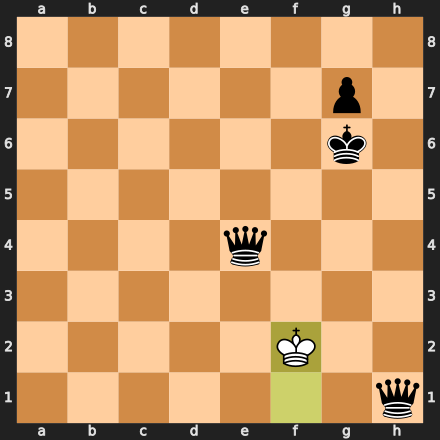

hybrid_aggressive thinking...
To move: Black
FEN: 8/6p1/6k1/8/4q3/8/5K2/7q b - - 1 71
Moves: Na5 Qb5 Nxb3 cxb3 a2 Qa4 Qd6+ Rf4 Qxb6 Rxb4 Qxb4 Qxb4 a1=Q Qxb7 Qf6 Qb5 Qe7 Qd3 Re8 b4 Qg5 b5 Qc5 Qb1 Qb6 e4 Re6 Qd3 Qc7+ Kh1 Rd6 Qe2 Qc1+ Kh2 Qc7 e5 Rb6 Kh1 Qb8 Kg1 Rxb5 e6 fxe6 Qxe6+ Kh8 Qg6 Qf8 Qd3 Ra5 Kh2 Ra1 Qc3 Qd6+ Qg3 Rh1+ Kxh1 Qxg3 Kg1 Qe3+ Kf1 Kh7 g4 Qxh3+ Kf2 Qxg4 Kf1 Qe4 Kf2 h5 Kf1 h4 Kf2 Kg6 Kf1 h3 Kf2 h2 Kf1 h1=Q+ Kf2
Bot plays Qef3# [mate-in-1 d1 0.0s 1 nodes]
Saved JSONL: C:\Users\samue\Downloads\chess_play_outputs\aggressive_vs_human_black_20260705_063817.jsonl
Saved PGN:   C:\Users\samue\Downloads\chess_play_outputs\aggressive_vs_human_black_20260705_063817.pgn
Saved CSV:   C:\Users\samue\Downloads\chess_play_outputs\aggressive_vs_human_black_20260705_063817_summary.csv
PGN text: ag_pgn_text(human_pgn)


In [14]:
# Play against hybrid_aggressive with full diagnostics

human_game, human_records, human_jsonl, human_pgn, human_summary = play_me_vs_aggressive_instrumented(
    human_color=chess.WHITE,
    model_time=30.0,
    use_book=True,
)


In [ ]:
# Analyze any saved hybrid_aggressive log

log_index = list_aggressive_logs(limit=20)
records = load_aggressive_records(0)
summarize_variant_records(records)
plot_variant_records(records)

# Examples:
# inspect_aggressive_move(log=0, move_number=13, side="black");
# inspect_aggressive_move(log=0, ply=26, show_raw=True);


In [ ]:
# Estimating Elo - quick notes

print("""
Best practical Elo estimate workflow:

1. Pick a fixed time control, e.g. 30s/move.
2. Play at least 20-50 games against calibrated engines/bots.
3. Use both colors and keep the opening book fixed.
4. Estimate rating difference from score:

   rating_diff = -400 * log10(1 / score - 1)

   where score is points/games against a known-rating opponent.

5. Better: test against several known ratings and fit the rating that best predicts all scores.

Caution: Stockfish depth 8 is not a stable Elo anchor unless you calibrate it.
A better ladder is multiple fixed Stockfish depths/nodes or external engines with known CCRL-style ratings.
""")

def elo_diff_from_score(score):
    score = min(max(float(score), 1e-6), 1 - 1e-6)
    return -400.0 * math.log10(1.0 / score - 1.0)

def estimate_elo_from_match(score, opponent_elo):
    return float(opponent_elo) + elo_diff_from_score(score)
